# Momentum Crashes Thesis of Tim Hirndorf - University of Mannheim 

In this analysis I will analyse US stock market data according to my base papers Momentum crashes, Daniel & Moskowitz (2016) and Momentum has its moments, Barroso & Santa-Clara (2015)

> AI has been used for code creation. I mentioned that in my thesis. the code was checked by me manually.
> In the save_table fundtion the export to png doesn't work. Therefore i use the LaTeX export. I consolidated the .tex files and exportet them from a LaTeX editor to use them in my thesis. 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import pandas_datareader.data as web
import datetime
import dataframe_image as dfi
from scipy import stats
from scipy.optimize import minimize
from arch import arch_model
from pathlib import Path

# Output directory and helpers
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, dpi=150):
    """Save a matplotlib Figure to outputs/ as png."""
    safe = ''.join(c if (c.isalnum() or c in ' _-') else '_' for c in str(name)).strip().replace(' ', '_')
    base = OUTPUT_DIR / safe
    fig.savefig(f'{base}.png', dpi=dpi, bbox_inches='tight')

def save_table(obj, name, dpi=200, fontsize=14):
    """Export a DataFrame to /outputs/ as PNG and LaTeX.
    PNG uses chrome → playwright → matplotlib fallback chain (with MathJax).
    LaTeX uses pandas .to_latex() (works on both DataFrame and Styler).
    """
    safe = ''.join(c if (c.isalnum() or c in ' _-') else '_' for c in str(name)).strip().replace(' ', '_')
    base = OUTPUT_DIR / safe

    # PNG export
    last_err = None
    for backend in ('playwright', 'chrome', 'matplotlib'):
        try:
            kwargs = dict(table_conversion=backend, fontsize=fontsize)
            if backend in ('chrome', 'playwright'):
                kwargs['dpi'] = dpi
                kwargs['use_mathjax'] = True
            dfi.export(obj, f'{base}.png', table_conversion='playwright', **kwargs)
            break
        except Exception as e:
            last_err = e
    else:
        print(f'[save_table PNG warning] {name}: {last_err}')

    # LaTeX export
    try:
        if hasattr(obj, 'to_latex') and not hasattr(obj, 'data'):
            tex = obj.to_latex(escape=False)
        elif hasattr(obj, 'to_latex'):
            tex = obj.to_latex()
        else:
            tex = str(obj)
        tex_full = (
            f'% Table: {name}\n'
            f'\\begin{{table}}[htbp]\n'
            f'  \\centering\n'
            f'  \\caption{{{name.replace("_", " ")}}}\n'
            f'  \\label{{tab:{safe}}}\n'
            f'  {tex}\n'
            f'\\end{{table}}\n'
        )
        with open(f'{base}.tex', 'w') as f:
            f.write(tex_full)
    except Exception as e:
        print(f'[save_table LaTeX warning] {name}: {e}')


## Table 1 – Momentum Portfolio Characteristics

Replication of Daniel & Moskowitz (2016), Table 1, using the full available sample from the Kenneth French data library.
Data available under: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

### Mathematical definitions

Let $r_{i,t}$ be the **monthly excess return** of portfolio $i$ in month $t$ (i.e. already net of the risk-free rate $r_f$), and let $r_{m,t}$ be the monthly excess market return.

| Symbol | Definition |
|--------|------------|
| $\bar{r} - r_f$ | Annualised mean excess return: $12 \times \bar{r}_i$ (%) |
| $\sigma$ | Annualised volatility: $\sqrt{12} \times \hat{\sigma}_i$ (%) |
| $\alpha$ | CAPM alpha from OLS: $r_{i,t} = \alpha_i + \beta_i r_{m,t} + \varepsilon_{i,t}$, annualised as $12\alpha_i$ (%) |
| $t(\alpha)$ | Newey-West $t$-statistic for $\alpha_i$ (6 lags) |
| $\beta$ | CAPM beta from the same OLS regression |
| SR | Annualised Sharpe ratio: $(\bar{r}_i / \hat{\sigma}_i) \times \sqrt{12}$ |
| sk(m) | Full-period realised skewness of **monthly log returns** $\log(1+r_{i,t}+r_{f,t})$ for deciles & market; for WML: $\log(1+r_{\text{WML},t}+r_{f,t})$ |
| sk(d) | Full-period realised skewness of **daily log returns** (same gross-return convention) |

In [2]:
# 1. Load monthly data
mom_m = pd.read_csv(
    'data/10_Portfolios_Prior_12_2.csv',
    skiprows=11, nrows=1192, index_col=0, header=0
)
mom_m.index = mom_m.index.astype(str).str.strip()
mom_m = mom_m[mom_m.index.str.match(r'^\d{6}$')]
mom_m.index = pd.to_datetime(mom_m.index, format='%Y%m')
mom_m.columns = [f'D{i}' for i in range(1, 11)]
mom_m = mom_m.apply(pd.to_numeric, errors='coerce').replace([-99.99, -999], np.nan) / 100

ff_m = pd.read_csv(
    'data/F-F_Research_Data_Factors.csv',
    skiprows=4, index_col=0
)
ff_m.index = ff_m.index.astype(str).str.strip()
ff_m = ff_m[ff_m.index.str.match(r'^\d{6}$')]
ff_m.index = pd.to_datetime(ff_m.index, format='%Y%m')
ff_m = ff_m.apply(pd.to_numeric, errors='coerce') / 100

data_m = mom_m.join(ff_m, how='inner').sort_index()
data_m['WML'] = data_m['D10'] - data_m['D1']
data_m['Mkt'] = data_m['Mkt-RF'] + data_m['RF']   # gross market return (excess + RF)

print(f'Monthly sample: {data_m.index[0].strftime("%Y-%m")} – {data_m.index[-1].strftime("%Y-%m")}  ({len(data_m)} months)')

# 2. Load daily data
mom_d = pd.read_csv(
    'data/10_Portfolios_Prior_12_2_Daily.csv',
    skiprows=9, index_col=0, header=0
)
mom_d.index = mom_d.index.astype(str).str.strip()
mom_d = mom_d[mom_d.index.str.match(r'^\d{8}$')]
mom_d.index = pd.to_datetime(mom_d.index, format='%Y%m%d')
mom_d.columns = [f'D{i}' for i in range(1, 11)]
mom_d = mom_d.apply(pd.to_numeric, errors='coerce').replace([-99.99, -999], np.nan) / 100

ff_d = pd.read_csv(
    'data/F-F_Research_Data_Factors_daily.csv',
    skiprows=4, index_col=0
)
ff_d.index = ff_d.index.astype(str).str.strip()
ff_d = ff_d[ff_d.index.str.match(r'^\d{8}$')]
ff_d.index = pd.to_datetime(ff_d.index, format='%Y%m%d')
ff_d = ff_d.apply(pd.to_numeric, errors='coerce') / 100

data_d = mom_d.join(ff_d, how='inner').sort_index()
data_d['WML'] = data_d['D10'] - data_d['D1']

print(f'Daily  sample: {data_d.index[0].strftime("%Y-%m-%d")} – {data_d.index[-1].strftime("%Y-%m-%d")}  ({len(data_d)} days)')

# 3. Helper: Newey-West OLS (alpha, t-stat, beta)

def nw_ols(y, x, lags=6):
    """
    OLS of y on [1, x].  Returns (alpha, t_alpha, beta) with Newey-West
    standard errors (Bartlett kernel, `lags` lags).
    """
    mask = ~(np.isnan(y) | np.isnan(x))
    y, x = y[mask], x[mask]
    n = len(y)
    X = np.column_stack([np.ones(n), x])          # design matrix [1, Mkt-RF]
    b = np.linalg.lstsq(X, y, rcond=None)[0]      # OLS coefficients
    e = y - X @ b                                  # residuals

    # Newey-West covariance
    S = X.T @ np.diag(e**2) @ X                   # HC0 sandwich
    for lag in range(1, lags + 1):
        Gamma = X[lag:].T @ np.diag(e[lag:] * e[:-lag]) @ X[:-lag]
        w = 1 - lag / (lags + 1)                  # Bartlett weight
        S += w * (Gamma + Gamma.T)
    V = np.linalg.inv(X.T @ X) @ S @ np.linalg.inv(X.T @ X)

    alpha, beta = b
    t_alpha = alpha / np.sqrt(V[0, 0])
    return alpha, t_alpha, beta


# 4. Build Table 1
portfolios = [f'D{i}' for i in range(1, 11)] + ['WML', 'Mkt-RF']
col_labels = [str(i) for i in range(1, 11)] + ['WML', 'Market']

rows = {stat: [] for stat in ['r-rf', 'sigma', 'alpha', 't_alpha', 'beta', 'SR', 'sk_m', 'sk_d']}

for port in portfolios:
    # 1. Define Excess vs Gross Returns for the current portfolio
    if port == 'Mkt-RF':
        ex_m = data_m['Mkt-RF'].dropna()
        gross_m = data_m['Mkt-RF'] + data_m['RF']
        ex_d = data_d['Mkt-RF'].dropna()
        gross_d = data_d['Mkt-RF'] + data_d['RF']
    elif port == 'WML':
        ex_m = data_m['WML'].dropna()
        gross_m = data_m['WML'] + data_m['RF']
        ex_d = data_d['WML'].dropna()
        gross_d = data_d['WML'] + data_d['RF']
    else:
        # Deciles 1 through 10
        ex_m = (data_m[port] - data_m['RF']).dropna()
        gross_m = data_m[port].dropna()
        ex_d = (data_d[port] - data_d['RF']).dropna()
        gross_d = data_d[port].dropna()

    # 2. Calculate Core Stats (Using Excess Returns)
    mu   = ex_m.mean()
    sig  = ex_m.std(ddof=1)

    rows['r-rf'].append(mu  * 12 * 100)
    rows['sigma'].append(sig * np.sqrt(12) * 100)
    rows['SR'].append((mu / sig) * np.sqrt(12))

    # 3. CAPM Regression (Using Excess Returns)
    if port == 'Mkt-RF':
        rows['alpha'].append(0.0)
        rows['t_alpha'].append(0.0)
        rows['beta'].append(1.0)
    else:
        # Align the specific excess portfolio with Mkt-RF
        aligned = pd.concat([ex_m, data_m['Mkt-RF']], axis=1).dropna()
        aligned.columns = ['Port_Ex', 'Mkt_Ex']
        
        a, ta, b = nw_ols(aligned['Port_Ex'].values, aligned['Mkt_Ex'].values, lags=6)
        rows['alpha'].append(a * 12 * 100)
        rows['t_alpha'].append(ta)
        rows['beta'].append(b)

    # 4. Skewness (Using Gross Returns)
    # As per D&M (2016) Table 1 notes: log(1 + gross_return)
    sk_m = np.log1p(gross_m.dropna()).skew()
    sk_d = np.log1p(gross_d.dropna()).skew()
    
    rows['sk_m'].append(sk_m)
    rows['sk_d'].append(sk_d)


# 5. Format and display
stat_labels = [
    r'$\bar{r} - r_f$',
    r'$\sigma$',
    r'$\alpha$',
    r'$t(\alpha)$',
    r'$\beta$',
    'SR',
    'sk(m)',
    'sk(d)',
]

table = pd.DataFrame(rows, index=col_labels).T
table.index = stat_labels

def fmt(val, row):
    if row in [r'$\bar{r} - r_f$', r'$\sigma$', r'$\alpha$']:
        return f'{val:.1f}'
    elif row == r'$t(\alpha)$':
        return f'({val:.1f})' if val != 0.0 else '(0)'
    elif row == r'$\beta$':
        return f'{val:.2f}'
    elif row == 'SR':
        return f'{val:.2f}'
    else:  # skewness
        return f'{val:.2f}'

formatted = table.apply(lambda col: [fmt(v, idx) for idx, v in zip(table.index, col)])
formatted.index = stat_labels
formatted.columns = col_labels

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')

print(f'Table 1 – Momentum portfolio characteristics, {start_yr}–{end_yr}')
save_table(formatted, "table_01_decile_summary")
formatted


Monthly sample: 1927-01 – 2026-02  (1190 months)
Daily  sample: 1926-11-03 – 2026-02-27  (52178 days)
Table 1 – Momentum portfolio characteristics, 1927:01–2026:02
[save_table PNG warning] table_01_decile_summary: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,1,2,3,4,5,6,7,8,9,10,WML,Market
$\bar{r} - r_f$,1.2,5.8,6.4,7.7,7.9,8.5,9.1,10.3,10.8,14.8,13.5,8.2
$\sigma$,33.9,27.9,23.9,21.8,20.3,19.8,18.8,18.3,19.2,22.3,27.4,18.4
$\alpha$,-11.6,-5.3,-3.3,-1.3,-0.6,0.0,1.1,2.6,2.9,6.4,18.0,0.0
$t(\alpha)$,(-7.5),(-4.3),(-3.4),(-1.5),(-0.8),(0.1),(1.8),(4.2),(3.9),(5.2),(8.3),(0)
$\beta$,1.56,1.34,1.17,1.09,1.03,1.03,0.97,0.93,0.96,1.02,-0.54,1.00
SR,0.04,0.21,0.27,0.35,0.39,0.43,0.48,0.56,0.56,0.66,0.49,0.45
sk(m),0.06,-0.08,-0.17,0.02,-0.02,-0.30,-0.52,-0.52,-0.80,-0.88,-5.81,-0.55
sk(d),0.39,0.42,0.20,0.18,0.08,-0.20,-0.32,-0.61,-0.57,-0.72,-1.62,-0.46


## Figure 1 – Winners and Losers

Cumulative dollar value of a $1 investment (log scale) in four assets from the start of the sample:
1. **Risk-free** – compounded monthly T-bill rate
2. **Market** – CRSP value-weighted index (Mkt-RF + RF)
3. **Past losers (D1)** – bottom momentum decile gross return (D1 + RF)
4. **Past winners (D10)** – top momentum decile gross return (D10 + RF)

Shaded bands highlight four major momentum crash episodes:
- **1932-07 – 1933-05** (blue): Great Depression reversal — WML −78% (Aug 1932) and −63% (Jul 1932), the two worst months on record
- **2001-01 – 2001-01** (purple): Tech-bubble reversal — WML −42% in Jan 2001 as past losers (internet stocks) rebounded sharply
- **2009-03 – 2009-05** (orange): GFC reversal — WML −39%, −45%, −21% as the market bottomed and losers bounced
- **2020-02 – 2020-06** (green): COVID reversal — WML −32% in Apr 2020 as beaten-down stocks recovered fastest


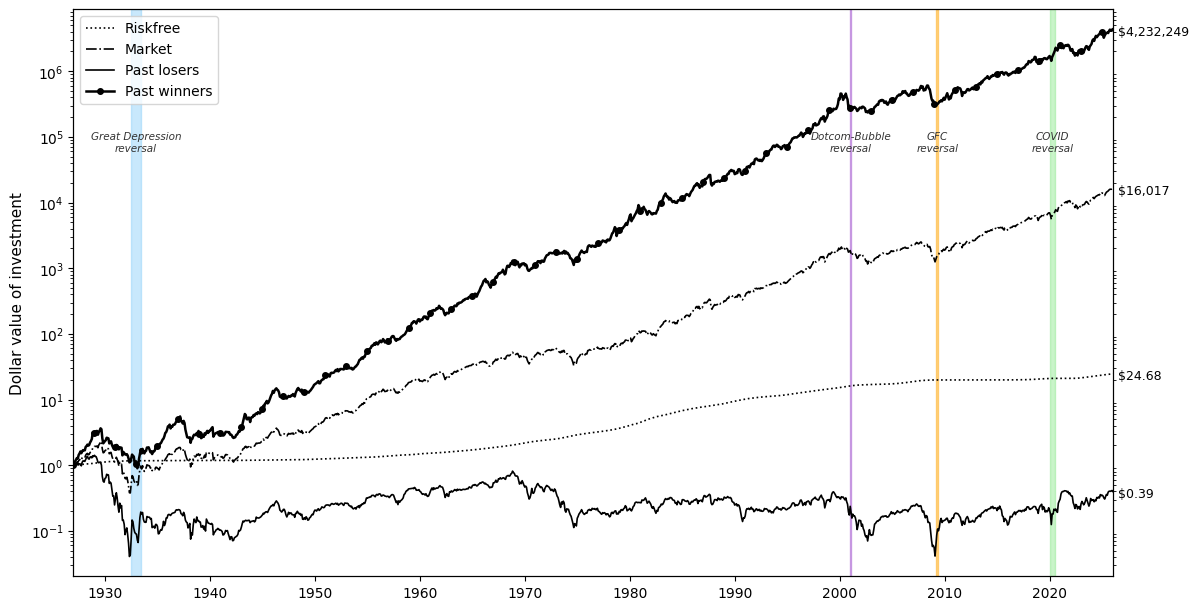

In [3]:
# Figure 1: Winners and Losers (cumulative wealth, log scale)

# Sorting the data chronologically to fix timeline for plot
data_m = data_m.sort_index()

# Gross monthly returns (total return, not excess)
gross_rf  = 1 + data_m["RF"]
gross_mkt = 1 + data_m["Mkt-RF"] + data_m["RF"]
gross_d1  = 1 + data_m["D1"]
gross_d10 = 1 + data_m["D10"]

# Cumulative wealth starting at $1
cum_rf  = gross_rf.cumprod()
cum_mkt = gross_mkt.cumprod()
cum_d1  = gross_d1.cumprod()
cum_d10 = gross_d10.cumprod()

# Four crash episodes with shaded bands
crash_periods = [
    ("1932-07", "1933-05", "Great Depression\nreversal"),
    ("2001-01", "2001-01", "Dotcom-Bubble\nreversal"),
    ("2009-03", "2009-05", "GFC\nreversal"),
    ("2020-02", "2020-06", "COVID\nreversal"),
]

# Plot
fig, ax = plt.subplots(figsize=(13, 7))

ax.semilogy(cum_rf.index,  cum_rf.values,  "k:",   lw=1.2, label="Riskfree")
ax.semilogy(cum_mkt.index, cum_mkt.values, "k-.", lw=1.2, label="Market")
ax.semilogy(cum_d1.index,  cum_d1.values,  "k-",  lw=1.2, label="Past losers")
ax.semilogy(cum_d10.index, cum_d10.values, "k-",  lw=1.8,
            marker="o", markevery=24, markersize=4, label="Past winners")

# Crash shading + period labels
shade_colors = ["#87cefa", "#9d4ccc", "#ffa500", "#88e788"]
for (start, end, label), color in zip(crash_periods, shade_colors):
    t0 = pd.Timestamp(start)
    t1 = pd.Timestamp(end) + pd.offsets.MonthEnd(1)
    ax.axvspan(t0, t1, alpha=0.45, color=color, zorder=0)
    mid = t0 + (t1 - t0) / 2
    ax.text(mid, 120000, label, ha="center", va="top", fontsize=7.5,
            color="#333333", style="italic")

# Right axis: final dollar values
final_vals = [
    (cum_d10.iloc[-1], f"${cum_d10.iloc[-1]:,.0f}"),
    (cum_mkt.iloc[-1], f"${cum_mkt.iloc[-1]:,.0f}"),
    (cum_rf.iloc[-1],  f"${cum_rf.iloc[-1]:.2f}"),
    (cum_d1.iloc[-1],  f"${cum_d1.iloc[-1]:.2f}"),
]
right_ax = ax.twinx()
right_ax.set_yscale("log")
# Set y-limits from data (ax.get_ylim() is unreliable before draw)
all_vals = np.concatenate([cum_rf.values, cum_mkt.values, cum_d1.dropna().values, cum_d10.values])
ymin = all_vals[all_vals > 0].min() * 0.5
ymax = all_vals.max() * 2.0
ax.set_ylim(ymin, ymax)
right_ax.set_ylim(ymin, ymax)
right_ax.set_yticks([v for v, _ in final_vals])
right_ax.set_yticklabels([lbl for _, lbl in final_vals], fontsize=9)
right_ax.tick_params(axis="y", length=0)

# Axes formatting
ax.set_ylabel("Dollar value of investment", fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(cum_rf.index[0], cum_rf.index[-1])
ax.legend(loc="upper left", fontsize=10, frameon=True)

start_label = data_m.index[0].strftime("%Y:%m")
end_label   = data_m.index[-1].strftime("%Y:%m")
"""
ax.set_title(
    f'Fig. 1  Winners and losers, {start_label}\u2013{end_label}.\n'
    'Cumulative dollar value of $1 invested in: risk-free, market, past losers (D1), past winners (D10).\n'
    "Shaded regions = crash episodes (Great Depression, Tech-bubble, GFC, COVID).",
    fontsize=9, loc='left', pad=8
)
"""

fig.subplots_adjust(left=0.07, right=0.87, top=0.88, bottom=0.07)
save_fig(fig, 'fig_01_winners_losers')
plt.show()

## Table 2 – Worst Monthly Momentum Returns

The 15 worst monthly returns to the WML momentum portfolio over the full sample.
Also tabulated are:
- **MKT-2y**: cumulative market return over the 24 months *prior* to the portfolio formation date
  (i.e. $\prod_{s=t-24}^{t-1}(1+r_{m,s}) - 1$)
- **Mkt*: contemporaneous total market return in month $ (Mkt-RF + RF)

All numbers in percent. Period markers:
-  July 1932 – September 1939 (Great Depression reversal)
-  April 2009 – August 2009 (GFC reversal)
-  January 2001 – November 2002 (Dotcom-bubble reversal)
-  February 2020 – June 2020 (COVID reversal)


In [4]:
# Table 2: 15 worst WML months

# Two-year cumulative market return ending the month before t
mkt_gross = 1 + data_m['Mkt-RF'] + data_m['RF']
data_m['MKT-2y'] = mkt_gross.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['Mkt_t']  = data_m['Mkt-RF'] + data_m['RF']   # contemporaneous total market return

# 15 worst WML months, sorted ascending
worst15_idx = data_m['WML'].nsmallest(15).sort_values().index

# Period markers
def marker(dt):
    if pd.Timestamp('1932-07') <= dt <= pd.Timestamp('1939-09'): return '*'
    if pd.Timestamp('2009-04') <= dt <= pd.Timestamp('2009-08'): return '†'  # †
    if pd.Timestamp('2001-01') <= dt <= pd.Timestamp('2002-11'): return '‡'  # ‡
    if pd.Timestamp('2020-02') <= dt <= pd.Timestamp('2020-06'): return '§'  # §
    return ''

rows = []
for rank, dt in enumerate(worst15_idx, 1):
    # Calculate the concurrent EXCESS returns for month t
    wml_t   = data_m.loc[dt, 'WML']
    mkt_ex  = data_m.loc[dt, 'Mkt-RF']               # Use excess market return
    d1_ex   = data_m.loc[dt, 'D1'] - data_m.loc[dt, 'RF']  # Subtract RF from losers
    d10_ex  = data_m.loc[dt, 'D10'] - data_m.loc[dt, 'RF'] # Subtract RF from winners
    
    rows.append({
        'Rank':    rank,
        'Month':   dt.strftime('%Y:%m') + marker(dt),
        'WML_t':   wml_t  * 100,
        'MKT-2y':  data_m.loc[dt, 'MKT-2y'] * 100,
        'Mkt_t':   mkt_ex * 100,
        'D1_t':    d1_ex  * 100,
        'D10_t':   d10_ex * 100,
    })

tab2 = pd.DataFrame(rows).set_index('Rank')

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 2 – Worst monthly momentum returns, {start_yr}–{end_yr}')

_styled_t2 = tab2.style.format({
    'WML_t':  '{:.2f}',
    'MKT-2y': '{:.2f}',
    'Mkt_t':  '{:.2f}',
    'D1_t':   '{:.2f}',
    'D10_t':  '{:.2f}',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'right')]},
    {'selector': 'td', 'props': [('text-align', 'right')]},
])
save_table(_styled_t2, "table_02_worst_WML_months")
_styled_t2


Table 2 – Worst monthly momentum returns, 1927:01–2026:02
[save_table PNG warning] table_02_worst_WML_months: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,Month,WML_t,MKT-2y,Mkt_t,D1_t,D10_t
Rank,,,,,,
1,1932:08*,-78.04,-67.57,37.12,93.81,15.77
2,1932:07*,-63.04,-74.69,33.61,74.92,11.88
3,2009:04†,-45.32,-40.49,10.17,45.19,-0.13
4,1939:09*,-44.36,-21.87,16.89,52.27,7.91
5,2001:01‡,-41.71,10.72,3.25,35.18,-6.53
6,2009:03,-39.18,-44.79,9.01,44.63,5.45
7,1938:06*,-33.47,-28.17,23.89,43.58,10.11
8,2020:04§,-31.69,-0.74,13.60,46.12,14.43
9,1933:04*,-31.53,-58.97,38.81,60.11,28.58


## Table 3 – Market Timing Regression

Replication of Daniel & Moskowitz (2016), Table 3. The dependent variable is the monthly WML excess return.
The full regression model is:

$$R_{WML,t} = \hat{\alpha}_0 + \hat{\alpha}_B I_{B,t-1} + \hat{\beta}_0 \tilde{R}^e_{m,t} + \hat{\beta}_B (I_{B,t-1} \cdot \tilde{R}^e_{m,t}) + \hat{\beta}_{B,U} (I_{B,t-1} \cdot I_{U,t} \cdot \tilde{R}^e_{m,t}) + \epsilon_t$$

### Variable definitions

| Symbol | Definition |
| :--- | :--- |
| $I_{B,t-1}$ | **Bear-market indicator:** equals 1 if the cumulative market return over the 24 months *prior* to $t$ is negative, i.e. $\prod_{s=t-24}^{t-1}(1 + R^e_{m,s} + R_{f,s}) - 1 < 0$ |
| $\tilde{R}^e_{m,t}$ | Contemporaneous **excess market return** $R^e_{m,t} = R_{m,t} - R_{f,t}$ |
| $I_{U,t}$ | **Up-market indicator:** equals 1 if $R^e_{m,t} > 0$ |
| $\hat{\alpha}_0$ | Unconditional WML intercept ($\times 100$, in % per month) |
| $\hat{\alpha}_B$ | Incremental intercept in bear markets ($\times 100$, in % per month) |
| $\hat{\beta}_0$ | Unconditional market beta |
| $\hat{\beta}_B$ | Incremental beta in bear markets |
| $\hat{\beta}_{B,U}$ | Additional incremental beta in bear + up markets |

The four specifications include progressively more interaction terms. All $t$-statistics use Newey-West standard errors with 6 lags.


In [5]:
# Table 3: Market timing regression

# Construct regression variables
# Bear-market indicator: I_B,t-1 = 1 if 2-year cumulative market return < 0
mkt_gross_2y = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y       = mkt_gross_2y.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['I_B'] = np.where(mkt_2y.isna(), np.nan, (mkt_2y < 0).astype(float))
data_m['Rm']   = data_m['Mkt-RF']                     # R^e_{m,t}
data_m['I_U']  = (data_m['Rm'] > 0).astype(float)    # I_{U,t}

# Interaction terms
data_m['I_B_Rm']       = data_m['I_B'] * data_m['Rm']                        # I_{B,t-1} * R^e_{m,t}
data_m['I_B_I_U_Rm']   = data_m['I_B'] * data_m['I_U'] * data_m['Rm']       # I_{B,t-1} * I_{U,t} * R^e_{m,t}

# NW OLS helper (multi-regressor)
def nw_ols_multi(y_col, x_cols, data, lags=6):
    """
    OLS of y on [1, x_cols] with memory-efficient Newey-West SEs (Bartlett, `lags` lags).
    Returns (coefficients, t-statistics, adj-R2).
    """
    # 1. Clean data and construct matrices
    df = data[[y_col] + x_cols].dropna()
    y  = df[y_col].values
    X  = np.column_stack([np.ones(len(df)), df[x_cols].values])
    n, k = len(y), X.shape[1] - 1
    
    # 2. OLS Coefficients and Residuals
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    
    # 3. Efficient Newey-West Covariance (HC0 + Lags)
    # Broadast the residuals element-wise across the columns of X
    # avoids creating an N x N diagonal matrix
    Xe = X * e[:, None] 
    
    # Contemporaneous variance (Lag 0)
    S = Xe.T @ Xe
    
    # Lagged covariances (Bartlett kernel)
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        w = 1 - lag / (lags + 1)
        S += w * (G + G.T)
        
    # Sandwich estimator: V = (X'X)^-1 * S * (X'X)^-1
    XX_inv = np.linalg.inv(X.T @ X)
    V = XX_inv @ S @ XX_inv
    
    # 4. Extract Statistics
    t_stat = b / np.sqrt(np.diag(V))
    
    ss_res = np.sum(e**2)
    ss_tot = np.sum((y - y.mean())**2)
    # Handle the edge case where variance is zero to avoid division by zero
    if ss_tot == 0:
        r2_adj = 0.0
    else:
        r2_adj = 1 - (ss_res / (n - k - 1)) / (ss_tot / (n - 1))
        
    return b, t_stat, r2_adj

# Run four specifications
specs = [
    # (label, x_cols)
    ('(1)', ['Rm']),
    ('(2)', ['I_B', 'Rm', 'I_B_Rm']),
    ('(3)', ['I_B', 'Rm', 'I_B_Rm', 'I_B_I_U_Rm']),
    ('(4)', ['Rm', 'I_B_Rm', 'I_B_I_U_Rm']),
]

results = {}
for name, xcols in specs:
    b, t, r2 = nw_ols_multi('WML', xcols, data_m, lags=6)
    results[name] = {'b': b, 't': t, 'r2': r2, 'xcols': xcols}

# Format into Table 3 (coef row + t-stat row per variable)
# Columns map: intercept=a0, I_B=aB, Rm=b0, I_B_Rm=bB, I_B_I_U_Rm=bBU
coef_map = [
    ('intercept', r'$\hat{\alpha}_0$',    r'$1$',                                              True),
    ('I_B',       r'$\hat{\alpha}_B$',    r'$I_{B,t-1}$',                                      True),
    ('Rm',        r'$\hat{\beta}_0$',     r'$\tilde{R}^e_{m,t}$',                              False),
    ('I_B_Rm',    r'$\hat{\beta}_B$',     r'$I_{B,t-1}\cdot\tilde{R}^e_{m,t}$',              False),
    ('I_B_I_U_Rm',r'$\hat{\beta}_{B,U}$', r'$I_{B,t-1}\cdot I_{U,t}\cdot\tilde{R}^e_{m,t}$', False),
]

spec_names = list(results.keys())
coef_rows  = []   # coefficient values
tstat_rows = []   # t-statistics
index_labels = [] # row index: (coef_label, sub-row)

for var_key, coef_label, var_label, scale in coef_map:
    coef_row  = {}
    tstat_row = {}
    for spec_name, res in results.items():
        xcols = res['xcols']
        b, t  = res['b'], res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            coef_row[spec_name]  = ''
            tstat_row[spec_name] = ''
            continue
        val  = b[idx] * 100 if scale else b[idx]
        tval = t[idx]
        coef_row[spec_name]  = f'{val:.3f}'
        tstat_row[spec_name] = f'({tval:.1f})'
    coef_rows.append(coef_row)
    tstat_rows.append(tstat_row)
    index_labels.append((coef_label, 'coef'))
    index_labels.append((coef_label, 't-stat'))

# Interleave coef and t-stat rows
all_rows = []
for c, t in zip(coef_rows, tstat_rows):
    all_rows.append(c)
    all_rows.append(t)

# R2 adj row (single row, no t-stat)
r2_row = {s: f"{results[s]['r2']:.3f}" for s in spec_names}
index_labels.append((r'$R^2_{adj}$', ''))
all_rows.append(r2_row)

idx = pd.MultiIndex.from_tuples(index_labels, names=['Coefficient', ''])
tab3 = pd.DataFrame(all_rows, index=idx)

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 3 – Market timing regression, {start_yr}\u2013{end_yr}')
print('alpha_0 and alpha_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.')
save_table(tab3, "table_03_market_timing_regression")
tab3


Table 3 – Market timing regression, 1927:01–2026:02
alpha_0 and alpha_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.
[save_table PNG warning] table_03_market_timing_regression: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


(1)     (2)     (3)     (4)
Coefficient                                               
$\hat{\alpha}_0$    coef     1.498   1.547   1.547   1.589
                    t-stat   (8.3)   (8.3)   (8.3)   (8.3)
$\hat{\alpha}_B$    coef            -1.808   0.497        
                    t-stat          (-2.7)   (0.5)        
$\hat{\beta}_0$     coef    -0.542  -0.080  -0.080  -0.082
                    t-stat  (-4.0)  (-1.2)  (-1.2)  (-1.3)
$\hat{\beta}_B$     coef            -1.041  -0.616  -0.657
                    t-stat          (-5.7)  (-3.9)  (-5.2)
$\hat{\beta}_{B,U}$ coef                    -0.725  -0.649
                    t-stat                  (-2.2)  (-2.9)
$R^2_{adj}$                  0.132   0.273   0.284   0.284

## Table 4 - Momentum Portfolio Optionality

Replication of Daniel & Moskowitz (2016), Table 4. Each column runs a time-series regression of the **monthly excess return** of a momentum decile portfolio (or WML) on the excess market return and indicator variables.

**Panel A - Optionality in bear markets:** (In thesis)

$$\tilde{R}^e_{i,t} = \bigl[{\alpha}_0 + {\alpha}_B I_{B,t-1}\bigr] + \bigl[{\beta}_0 + I_{B,t-1}({\beta}_B + \tilde{I}_{U,t}{\beta}_{B,U})\bigr]\tilde{R}^e_{m,t} + \tilde{\epsilon}_t$$

**Panel B - Optionality in bull markets:** (not in thesis, due to page limit)

$$\tilde{R}^e_{i,t} = \bigl[{\alpha}_0 + {\alpha}_L I_{L,t-1}\bigr] + \bigl[{\beta}_0 + I_{L,t-1}({\beta}_L + \tilde{I}_{U,t}{\beta}_{L,U})\bigr]\tilde{R}^e_{m,t} + \tilde{\epsilon}_t$$

### Variable definitions

| Symbol | Definition |
| :--- | :--- |
| $I_{B,t-1}$ | **Bear indicator:** 1 if 24-month cumulative market return before $t$ is negative |
| $I_{L,t-1}$ | **Bull indicator:** $1 - I_{B,t-1}$ |
| $\tilde{R}^e_{m,t}$ | Contemporaneous excess market return |
| $I_{U,t}$ | **Up-market indicator:** 1 if $R^e_{m,t} > 0$ |
| $\hat{\alpha}_0, \hat{\alpha}_B, \hat{\alpha}_L$ | Intercepts (x100, % per month) |
| $\hat{\beta}_0$ | Unconditional market beta |
| $\hat{\beta}_B, \hat{\beta}_{B,U}$ | Incremental betas in bear / bear+up markets |
| $\hat{\beta}_L, \hat{\beta}_{L,U}$ | Incremental betas in bull / bull+up markets |

All $t$-statistics use Newey-West standard errors with 6 lags.

In [6]:
# Table 4: Momentum portfolio optionality

# Indicators and interaction terms
mkt_gross_t4 = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y_t4    = mkt_gross_t4.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['I_B_t4']  = (mkt_2y_t4 < 0).astype(float)   # bear: 2y cum mkt return < 0
data_m['I_B_t4'] = np.where(mkt_2y_t4.isna(), np.nan, (mkt_2y_t4 < 0).astype(float))
data_m['I_L_t4'] = np.where(mkt_2y_t4.isna(), np.nan, 1 - data_m['I_B_t4'])
data_m['Rm_t4']   = data_m['Mkt-RF']                  # excess market return
data_m['I_U_t4']  = (data_m['Rm_t4'] > 0).astype(float)  # up-market

# Panel A regressors: I_B, Rm, I_B*Rm, I_B*I_U*Rm
data_m['I_B_Rm_t4']     = data_m['I_B_t4'] * data_m['Rm_t4']
data_m['I_B_IU_Rm_t4']  = data_m['I_B_t4'] * data_m['I_U_t4'] * data_m['Rm_t4']

# Panel B regressors: I_L, Rm, I_L*Rm, I_L*I_U*Rm
data_m['I_L_Rm_t4']     = data_m['I_L_t4'] * data_m['Rm_t4']
data_m['I_L_IU_Rm_t4']  = data_m['I_L_t4'] * data_m['I_U_t4'] * data_m['Rm_t4']

# NW OLS (multi-regressor, returns b and t-stat arrays)
def nw_ols_t4(y_arr, X_arr, lags=6):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b  = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e  = y - Xd @ b
    
    # Efficient NW Covariance
    Xe = Xd * e[:, None]
    S  = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
        
    XX_inv = np.linalg.inv(Xd.T @ Xd)
    V = XX_inv @ S @ XX_inv
    return b, b / np.sqrt(np.diag(V))

# Run regressions for all portfolios
portfolios_t4 = [f'D{i}' for i in range(1, 11)] + ['WML']
col_labels_t4 = [str(i) for i in range(1, 11)] + ['WML']

X_A = data_m[['I_B_t4', 'Rm_t4', 'I_B_Rm_t4', 'I_B_IU_Rm_t4']].values
X_B = data_m[['I_L_t4', 'Rm_t4', 'I_L_Rm_t4', 'I_L_IU_Rm_t4']].values

# coef index: 0=intercept, 1=I_B/I_L, 2=Rm, 3=I_B*Rm/I_L*Rm, 4=I_B*I_U*Rm/I_L*I_U*Rm
# scale *100 for intercepts (indices 0,1)
panels = {
    'Panel A: Optionality in bear markets': (
        X_A,
        [r'$\hat{\alpha}_0$', r'$\hat{\alpha}_B$',
         r'$\hat{\beta}_0$',  r'$\hat{\beta}_B$', r'$\hat{\beta}_{B,U}$'],
        [True, True, False, False, False]
    ),
    'Panel B: Optionality in bull markets': (
        X_B,
        [r'$\hat{\alpha}_0$', r'$\hat{\alpha}_L$',
         r'$\hat{\beta}_0$',  r'$\hat{\beta}_L$', r'$\hat{\beta}_{L,U}$'],
        [True, True, False, False, False]
    ),
}

# Build and display each panel
start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 4 – Momentum portfolio optionality, {start_yr}\u2013{end_yr}')
print('Intercepts x100 (% per month). t-stats (NW, 6 lags) in parentheses.')

for panel_title, (X_mat, coef_labels, scale_flags) in panels.items():
    # Collect results
    bs = {}; ts = {}
    for port in portfolios_t4:
        # Subtract the risk-free rate for D1 through D10, but NOT for WML
        if port == 'WML':
            y_val = data_m[port].values
        else:
            y_val = (data_m[port] - data_m['RF']).values
            
        b, t = nw_ols_t4(y_val, X_mat)
        bs[port] = b; ts[port] = t

    # Build alternating coef / t-stat rows
    all_rows = []; idx_labels = []
    for ci, (clabel, sc) in enumerate(zip(coef_labels, scale_flags)):
        coef_row  = {cl: f"{bs[p][ci]*100 if sc else bs[p][ci]:.3f}"
                     for p, cl in zip(portfolios_t4, col_labels_t4)}
        tstat_row = {cl: f"({ts[p][ci]:.1f})"
                     for p, cl in zip(portfolios_t4, col_labels_t4)}
        all_rows += [coef_row, tstat_row]
        idx_labels += [(clabel, 'coef'), (clabel, 't-stat')]

    midx = pd.MultiIndex.from_tuples(idx_labels, names=['Coefficient', ''])
    panel_df = pd.DataFrame(all_rows, index=midx)

    print(f'\n{panel_title}')
    _panel_label = panel_title.split(":")[0].replace(" ", "_").lower()
    save_table(panel_df, f"table_04_optionality_{_panel_label}")
    display(panel_df)


Table 4 – Momentum portfolio optionality, 1927:01–2026:02
Intercepts x100 (% per month). t-stats (NW, 6 lags) in parentheses.

Panel A: Optionality in bear markets
[save_table PNG warning] table_04_optionality_panel_a: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


1       2       3       4       5       6  \
Coefficient                                                                  
$\hat{\alpha}_0$    coef    -1.107  -0.522  -0.260  -0.104  -0.003   0.027   
                    t-stat  (-8.3)  (-4.7)  (-3.2)  (-1.3)  (-0.1)   (0.6)   
$\hat{\alpha}_B$    coef    -0.008   0.021  -0.162  -0.546  -0.761  -0.298   
                    t-stat  (-0.0)   (0.0)  (-0.3)  (-1.7)  (-1.7)  (-1.4)   
$\hat{\beta}_0$     coef     1.318   1.114   0.992   0.955   0.922   0.954   
                    t-stat  (28.3)  (27.6)  (30.1)  (34.4)  (43.7)  (52.2)   
$\hat{\beta}_B$     coef     0.248   0.289   0.291   0.141   0.105   0.091   
                    t-stat   (2.3)   (3.2)   (5.1)   (2.4)   (1.6)   (1.8)   
$\hat{\beta}_{B,U}$ coef     0.509   0.372   0.195   0.296   0.247   0.123   
                    t-stat   (2.3)   (1.5)   (1.2)   (4.0)   (1.6)   (1.8)   

                                 7       8       9      10     WML  
Coefficient                                                         
$\hat{\alpha}_0$    coef     0.104   0.219   0.232   0.440   1.547  
                    t-stat   (2.0)   (4.2)   (3.5)   (4.2)   (8.3)  
$\hat{\alpha}_B$    coef    -0.112   0.037   0.534   0.489   0.497  
                    t-stat  (-0.5)   (0.2)   (1.9)   (1.3)   (0.5)  
$\hat{\beta}_0$     coef     0.949   0.982   1.047   1.238  -0.080  
                    t-stat  (42.2)  (46.2)  (41.8)  (40.4)  (-1.2)  
$\hat{\beta}_B$     coef     0.022  -0.078  -0.068  -0.369  -0.616  
                    t-stat   (0.5)  (-2.1)  (-1.4)  (-5.1)  (-3.9)  
$\hat{\beta}_{B,U}$ coef     0.022  -0.055  -0.231  -0.215  -0.725  
                    t-stat   (0.4)  (-1.1)  (-2.6)  (-1.8)  (-2.2)


Panel B: Optionality in bull markets
[save_table PNG warning] table_04_optionality_panel_b: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


1       2       3       4       5       6  \
Coefficient                                                                  
$\hat{\alpha}_0$    coef     0.504   0.682   0.199   0.292   0.021   0.120   
                    t-stat   (1.0)   (2.0)   (0.8)   (1.3)   (0.1)   (0.7)   
$\hat{\alpha}_L$    coef    -1.686  -1.234  -0.585  -0.473  -0.126  -0.068   
                    t-stat  (-3.1)  (-3.3)  (-2.1)  (-2.0)  (-0.6)  (-0.4)   
$\hat{\beta}_0$     coef     1.864   1.621   1.397   1.269   1.172   1.116   
                    t-stat  (17.1)  (14.3)  (17.2)  (28.9)  (18.9)  (28.5)   
$\hat{\beta}_L$     coef    -0.566  -0.515  -0.440  -0.335  -0.278  -0.156   
                    t-stat  (-4.4)  (-3.9)  (-4.5)  (-5.5)  (-3.8)  (-3.2)   
$\hat{\beta}_{L,U}$ coef     0.044   0.018   0.074   0.045   0.060  -0.015   
                    t-stat   (0.3)   (0.2)   (0.9)   (0.8)   (1.1)  (-0.3)   

                                 7       8       9      10     WML  
Coefficient                                                         
$\hat{\alpha}_0$    coef     0.063   0.083   0.031   0.244  -0.260  
                    t-stat   (0.4)   (0.6)   (0.2)   (1.0)  (-0.4)  
$\hat{\alpha}_L$    coef    -0.085   0.054   0.290   0.526   2.212  
                    t-stat  (-0.4)   (0.3)   (1.4)   (1.8)   (3.2)  
$\hat{\beta}_0$     coef     0.983   0.872   0.844   0.743  -1.121  
                    t-stat  (32.8)  (30.5)  (18.9)  (10.4)  (-6.6)  
$\hat{\beta}_L$     coef    -0.069   0.088   0.228   0.585   1.151  
                    t-stat  (-1.3)   (2.1)   (3.8)   (6.6)   (5.8)  
$\hat{\beta}_{L,U}$ coef     0.075   0.049  -0.052  -0.195  -0.239  
                    t-stat   (1.1)   (0.9)  (-0.8)  (-2.5)  (-1.4)

## Figure X – Ex Ante vs Ex Post Hedged Momentum

Removed from thesis, part of Figure 2
Replication of Daniel & Moskowitz (2016), Figure 4. Cumulative returns to three momentum strategies (log scale):

1. **Unhedged** (solid): static WML = D10 − D1
2. **Ex post hedged** (dotted): WML hedged using the *future* 6-month realized beta — an infeasible benchmark
3. **Ex ante hedged** (dashed): WML hedged using the *lagged* 6-month realized beta — a feasible strategy

The hedged return in month $t$ is:
$$r^{\text{hedged}}_t = r^{\text{WML}}_t - \hat{\beta}_t \cdot R^e_{m,t}$$

where $\hat{\beta}_t$ is estimated from a 6-month rolling window of WML and market excess returns (lagged for ex ante, leading for ex post).

**Panel A** covers the Great Depression period (1927–1939). **Panel B** covers the full sample.


Calculating daily rolling betas for 52178 days.


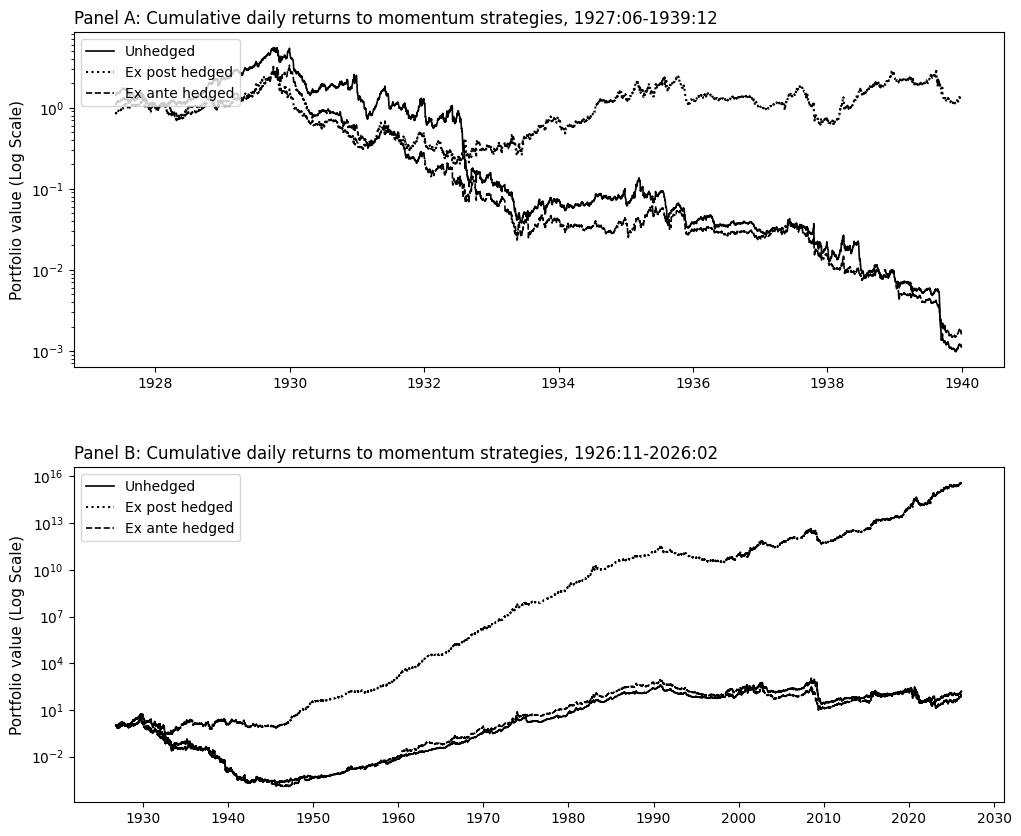

In [7]:
# 1. Preparing Daily Data
dates = data_d.index
wml = data_d['WML'].values
mkt = data_d['Mkt-RF'].values
rf  = data_d['RF'].values

n_days = len(dates)

# 2. Construct the 10-Day Lag Matrix (Dimson Beta Setup)
X_mkt_lags = np.full((n_days, 11), np.nan)
for lag in range(11):
    if lag == 0:
        X_mkt_lags[:, lag] = mkt
    else:
        X_mkt_lags[lag:, lag] = mkt[:-lag]

# Add intercept column for OLS: X_design = [1, mkt_t, mkt_{t-1}, ..., mkt_{t-10}]
X_design = np.column_stack([np.ones(n_days), X_mkt_lags])

# 3. Calculate Daily 42-Day Rolling Betas
beta_exante = np.full(n_days, np.nan)
beta_expost = np.full(n_days, np.nan)

print(f"Calculating daily rolling betas for {n_days} days.")

for i in range(n_days):
    
    # Ex Ante: 42 trading days before day i (exclusive of i)
    s_ant, e_ant = max(0, i - 42), i
    if e_ant - s_ant >= 20: # Require at least 20 valid days
        y_ant = wml[s_ant:e_ant]
        X_ant = X_design[s_ant:e_ant]
        
        valid_ant = ~(np.isnan(y_ant) | np.any(np.isnan(X_ant), axis=1))
        if valid_ant.sum() >= 20:
            b_ant = np.linalg.lstsq(X_ant[valid_ant], y_ant[valid_ant], rcond=None)[0]
            beta_exante[i] = np.sum(b_ant[1:]) # Sum of 11 market coefficients
            
    # Ex Post: 42 trading days FROM day i (inclusive of i)
    s_post, e_post = i, min(n_days, i + 42)
    if e_post - s_post >= 20:
        y_post = wml[s_post:e_post]
        X_post = X_design[s_post:e_post]
        
        valid_post = ~(np.isnan(y_post) | np.any(np.isnan(X_post), axis=1))
        if valid_post.sum() >= 20:
            b_post = np.linalg.lstsq(X_post[valid_post], y_post[valid_post], rcond=None)[0]
            beta_expost[i] = np.sum(b_post[1:])

# 4. Calculate Daily Hedged Returns
# Fill NaN betas with 0 (e.g., the first 42 days where ex-ante can't be calculated)
b_ant_clean = np.nan_to_num(beta_exante)
b_post_clean = np.nan_to_num(beta_expost)

hedged_exante_ret = wml - (b_ant_clean * mkt)
hedged_expost_ret = wml - (b_post_clean * mkt)

# 5. Compound Wealth Dynamically (Equation 15 from D&M)
# V_{t} = V_{t-1} * (1 + R_portfolio + R_f)
# We fill NaNs in WML and RF with 0 to prevent compounding breakage
clean_wml = np.nan_to_num(wml)
clean_rf  = np.nan_to_num(rf)

cum_wml    = np.cumprod(1 + clean_wml + clean_rf)
cum_exante = np.cumprod(1 + np.nan_to_num(hedged_exante_ret) + clean_rf)
cum_expost = np.cumprod(1 + np.nan_to_num(hedged_expost_ret) + clean_rf)

# 6. Plotting (Replicating Figure 4)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Panel A: The Great Depression Crash (1927:06 - 1939:12)
mask_a = (dates >= '1927-06-01') & (dates <= '1939-12-31')
ax1.semilogy(dates[mask_a], cum_wml[mask_a],    'k-',  lw=1.2, label='Unhedged')
ax1.semilogy(dates[mask_a], cum_expost[mask_a], 'k:',  lw=1.5, label='Ex post hedged')
ax1.semilogy(dates[mask_a], cum_exante[mask_a], 'k--', lw=1.2, label='Ex ante hedged')
ax1.set_ylabel('Portfolio value (Log Scale)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Panel A: Cumulative daily returns to momentum strategies, 1927:06-1939:12', loc='left')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: Full Sample
# To match the plot precisely, re-normalize the start of Panel B if desired, 
# or just plot the absolute cumulative wealth. 
ax2.semilogy(dates, cum_wml,    'k-',  lw=1.2, label='Unhedged')
ax2.semilogy(dates, cum_expost, 'k:',  lw=1.5, label='Ex post hedged')
ax2.semilogy(dates, cum_exante, 'k--', lw=1.2, label='Ex ante hedged')
ax2.set_ylabel('Portfolio value (Log Scale)', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_title(f'Panel B: Cumulative daily returns to momentum strategies, {dates[0].strftime("%Y:%m")}-{dates[-1].strftime("%Y:%m")}', loc='left')
ax2.xaxis.set_major_locator(mdates.YearLocator(10))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(hspace=0.3)
save_fig(fig, 'fig_X1_exante_expost_returns')
plt.show()

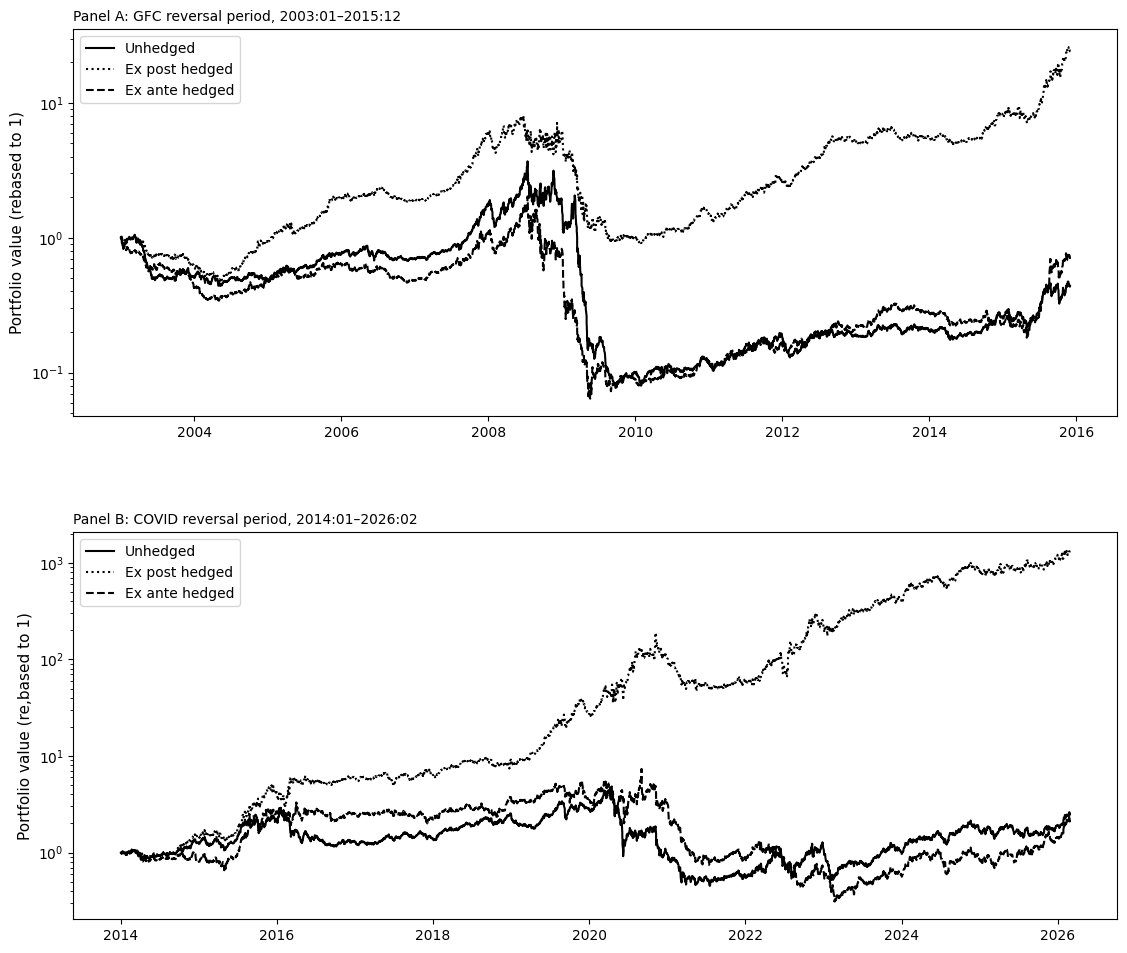

In [8]:
# Figure X_2 (Figure X continued): GFC and COVID crash episodes
# Also removed from thesis, also present in figure 2
# Same three strategies, zoomed into ~12-year windows, rebased to 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Panel A: GFC period (2003-01 to 2015-12)
mask_gfc = (dates >= '2003-01') & (dates <= '2015-12')
i0_gfc = np.where(mask_gfc)[0][0]

# Rebase to 1 at the start of the period
cum_wml_gfc    = cum_wml[mask_gfc]    / cum_wml[i0_gfc]
cum_expost_gfc = cum_expost[mask_gfc] / cum_expost[i0_gfc]
cum_exante_gfc = cum_exante[mask_gfc] / cum_exante[i0_gfc]

ax1.semilogy(dates[mask_gfc], cum_wml_gfc,    'k-',  lw=1.5, label='Unhedged')
ax1.semilogy(dates[mask_gfc], cum_expost_gfc, 'k:',  lw=1.5, label='Ex post hedged')
ax1.semilogy(dates[mask_gfc], cum_exante_gfc, 'k--', lw=1.5, label='Ex ante hedged')

ax1.set_ylabel('Portfolio value (rebased to 1)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Panel A: GFC reversal period, 2003:01–2015:12', fontsize=10, loc='left')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: COVID period (2014-01 to 2026-12)
mask_covid = (dates >= '2014-01') & (dates <= '2026-12')
i0_covid = np.where(mask_covid)[0][0]

# Rebase to 1 at the start of the period
cum_wml_covid    = cum_wml[mask_covid]    / cum_wml[i0_covid]
cum_expost_covid = cum_expost[mask_covid] / cum_expost[i0_covid]
cum_exante_covid = cum_exante[mask_covid] / cum_exante[i0_covid]

ax2.semilogy(dates[mask_covid], cum_wml_covid,    'k-',  lw=1.5, label='Unhedged')
ax2.semilogy(dates[mask_covid], cum_expost_covid, 'k:',  lw=1.5, label='Ex post hedged')
ax2.semilogy(dates[mask_covid], cum_exante_covid, 'k--', lw=1.5, label='Ex ante hedged')

ax2.set_ylabel('Portfolio value (re,based to 1)', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_title(
    f'Panel B: COVID reversal period, 2014:01–{dates[mask_covid][-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(hspace=0.3, left=0.08, right=0.95, top=0.95, bottom=0.06)
save_fig(fig, 'fig_X2_ante_post_GFC_COVID')
plt.show()

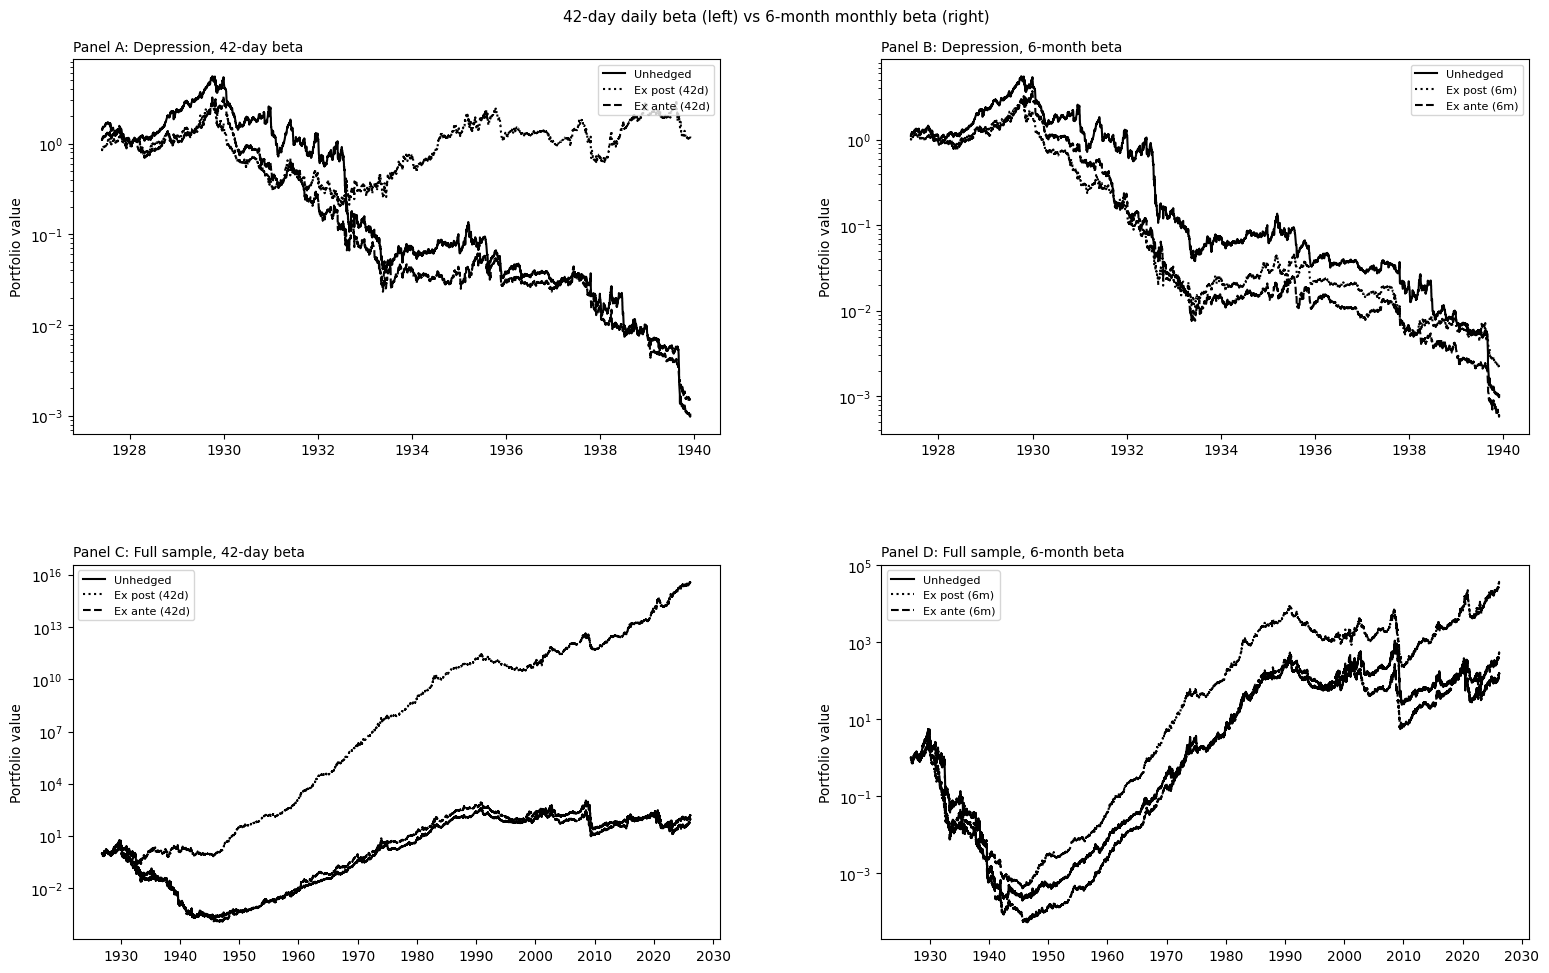

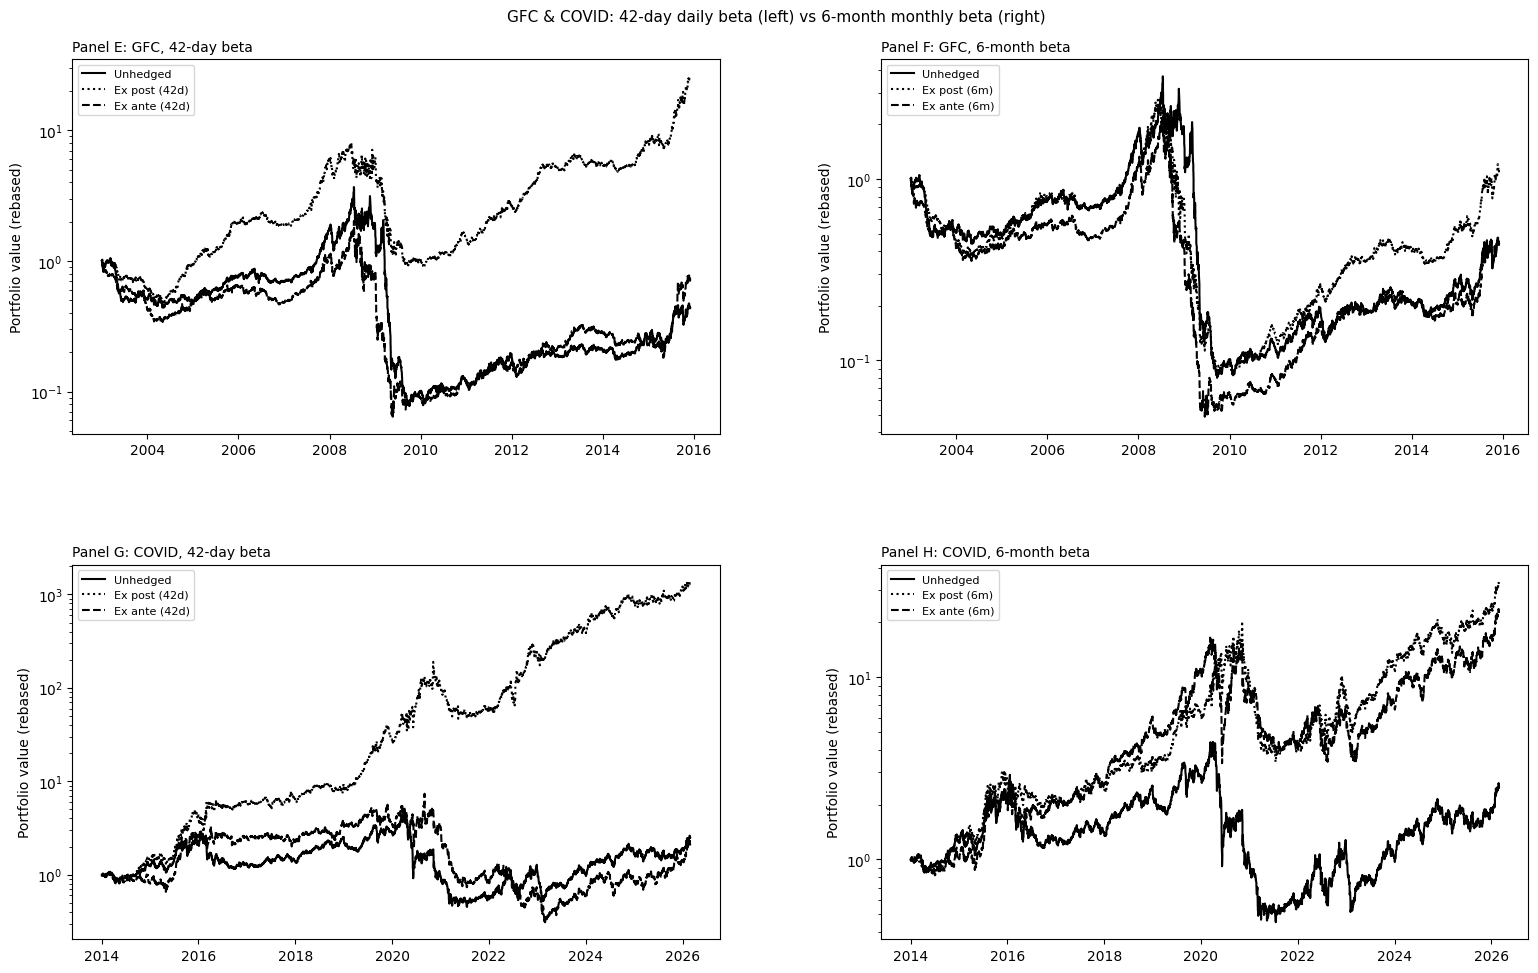

Final cumulative values:
  Unhedged:           $150
  Ex ante (42-day):   $89
  Ex post (42-day):   $3,661,162,857,914,006
  Ex ante (6-month):  $511
  Ex post (6-month):  $34,607


In [9]:
# Figure 2: Analyzing different time lags for beta predictions
# 1. Initialize arrays for DAILY 6-month (126-day) calculations
window_126d = 126  
beta_exante_6m = np.full(n_days, np.nan)
beta_expost_6m = np.full(n_days, np.nan)

# Calculating daily 126-day rolling betas for {n_days} days.

# 2. Compute 6-month (126-day) Dimson-betas for each DAY
for i in range(n_days):
    
    # Ex ante: 126 trading days BEFORE day i (exclusive)
    s, e = max(0, i - window_126d), i
    if e - s >= 60: # Require at least ~3 months of valid daily data
        y_curr = wml[s:e]
        X_curr = X_design[s:e] # Using the daily X_design with 10 lags + intercept
        
        valid = ~(np.isnan(y_curr) | np.any(np.isnan(X_curr), axis=1))
        if valid.sum() >= 60:
            b_exante = np.linalg.lstsq(X_curr[valid], y_curr[valid], rcond=None)[0]
            beta_exante_6m[i] = np.sum(b_exante[1:])
            
    # Ex post: 126 trading days FROM day i (inclusive)
    s2, e2 = i, min(n_days, i + window_126d)
    if e2 - s2 >= 60:
        y_curr2 = wml[s2:e2]
        X_curr2 = X_design[s2:e2]
        
        valid2 = ~(np.isnan(y_curr2) | np.any(np.isnan(X_curr2), axis=1))
        if valid2.sum() >= 60:
            b_expost = np.linalg.lstsq(X_curr2[valid2], y_curr2[valid2], rcond=None)[0]
            beta_expost_6m[i] = np.sum(b_expost[1:])

# 3. Calculate Daily Hedged Returns & Compound Wealth (Equation 15)
# Fill NaNs with 0 for the first few months where lookback isn't possible
b_ant_6m_clean = np.nan_to_num(beta_exante_6m)
b_post_6m_clean = np.nan_to_num(beta_expost_6m)

hedged_exante_6m_ret = wml - (b_ant_6m_clean * mkt)
hedged_expost_6m_ret = wml - (b_post_6m_clean * mkt)

# Compound daily including the risk-free rate (clean_rf is from the previous step)
cum_exante_6m = np.cumprod(1 + np.nan_to_num(hedged_exante_6m_ret) + clean_rf)
cum_expost_6m = np.cumprod(1 + np.nan_to_num(hedged_expost_6m_ret) + clean_rf)

# Plot: 4 panels comparing 42-day vs 6-month lag
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel A: Great Depression – 42-day lag
ax = axes[0, 0]
mask_a = (dates >= '1927-06') & (dates <= '1939-12')
ax.semilogy(dates[mask_a], cum_wml[mask_a],    'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_a], cum_expost[mask_a], 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates[mask_a], cum_exante[mask_a], 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Panel A: Depression, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: Great Depression – 6-month lag
ax = axes[0, 1]
ax.semilogy(dates[mask_a], cum_wml[mask_a],       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_a], cum_expost_6m[mask_a], 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates[mask_a], cum_exante_6m[mask_a], 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Panel B: Depression, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel C: Full sample – 42-day lag
ax = axes[1, 0]
ax.semilogy(dates, cum_wml,    'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates, cum_expost, 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates, cum_exante, 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel C: Full sample, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel D: Full sample – 6-month lag
ax = axes[1, 1]
ax.semilogy(dates, cum_wml,       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates, cum_expost_6m, 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates, cum_exante_6m, 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel D: Full sample, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(
    '42-day daily beta (left) vs 6-month monthly beta (right)',
    fontsize=11, y=0.99
)
fig.subplots_adjust(hspace=0.35, wspace=0.25, left=0.06, right=0.97, top=0.94, bottom=0.06)
save_fig(fig, 'fig_02_different_lags_panel_ad')
plt.show()


# GFC and COVID comparison
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))

# Panel E: GFC - 42-day lag
ax = axes2[0, 0]
mask_gfc = (dates >= '2003-01') & (dates <= '2015-12')
if mask_gfc.any():
    i0 = np.where(mask_gfc)[0][0]
    ax.semilogy(dates[mask_gfc], cum_wml[mask_gfc]/cum_wml[i0],       'k-',  lw=1.5, label='Unhedged')
    ax.semilogy(dates[mask_gfc], cum_expost[mask_gfc]/cum_expost[i0], 'k:',  lw=1.5, label='Ex post (42d)')
    ax.semilogy(dates[mask_gfc], cum_exante[mask_gfc]/cum_exante[i0], 'k--', lw=1.5, label='Ex ante (42d)')
    ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title('Panel E: GFC, 42-day beta', fontsize=10, loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel F: GFC - 6-month lag
ax = axes2[0, 1]
if mask_gfc.any():
    ax.semilogy(dates[mask_gfc], cum_wml[mask_gfc]/cum_wml[i0],             'k-',  lw=1.5, label='Unhedged')
    ax.semilogy(dates[mask_gfc], cum_expost_6m[mask_gfc]/cum_expost_6m[i0], 'k:',  lw=1.5, label='Ex post (6m)')
    ax.semilogy(dates[mask_gfc], cum_exante_6m[mask_gfc]/cum_exante_6m[i0], 'k--', lw=1.5, label='Ex ante (6m)')
    ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title('Panel F: GFC, 6-month beta', fontsize=10, loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel G: COVID - 42-day lag
ax = axes2[1, 0]
mask_covid = (dates >= '2014-01') & (dates <= '2026-12')
if mask_covid.any():
    i0c = np.where(mask_covid)[0][0]
    ax.semilogy(dates[mask_covid], cum_wml[mask_covid]/cum_wml[i0c],       'k-',  lw=1.5, label='Unhedged')
    ax.semilogy(dates[mask_covid], cum_expost[mask_covid]/cum_expost[i0c], 'k:',  lw=1.5, label='Ex post (42d)')
    ax.semilogy(dates[mask_covid], cum_exante[mask_covid]/cum_exante[i0c], 'k--', lw=1.5, label='Ex ante (42d)')
    ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title('Panel G: COVID, 42-day beta', fontsize=10, loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
else:
    ax.text(0.5, 0.5, 'Data sample ends before COVID period', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Panel G: COVID, 42-day beta', fontsize=10, loc='left')
    ax.set_yticks([])
    ax.set_xticks([])

# Panel H: COVID - 6-month lag
ax = axes2[1, 1]
if mask_covid.any():
    ax.semilogy(dates[mask_covid], cum_wml[mask_covid]/cum_wml[i0c],             'k-',  lw=1.5, label='Unhedged')
    ax.semilogy(dates[mask_covid], cum_expost_6m[mask_covid]/cum_expost_6m[i0c], 'k:',  lw=1.5, label='Ex post (6m)')
    ax.semilogy(dates[mask_covid], cum_exante_6m[mask_covid]/cum_exante_6m[i0c], 'k--', lw=1.5, label='Ex ante (6m)')
    ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title('Panel H: COVID, 6-month beta', fontsize=10, loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
else:
    ax.text(0.5, 0.5, 'Data sample ends before COVID period', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Panel H: COVID, 6-month beta', fontsize=10, loc='left')
    ax.set_yticks([])
    ax.set_xticks([])

fig2.suptitle('GFC & COVID: 42-day daily beta (left) vs 6-month monthly beta (right)', fontsize=11, y=0.99)
fig2.subplots_adjust(hspace=0.35, wspace=0.25, left=0.06, right=0.97, top=0.94, bottom=0.06)
save_fig(fig2, 'fig_02_different_lags_panel_eh')
plt.show()

# Summary stats
print(f'Final cumulative values:')
print(f'  Unhedged:           ${cum_wml[-1]:,.0f}')
print(f'  Ex ante (42-day):   ${cum_exante[-1]:,.0f}')
print(f'  Ex post (42-day):   ${cum_expost[-1]:,.0f}')
print(f'  Ex ante (6-month):  ${cum_exante_6m[-1]:,.0f}')
print(f'  Ex post (6-month):  ${cum_expost_6m[-1]:,.0f}')


## Table 5 – Momentum Returns and Estimated Market Variance

Replication of Daniel & Moskowitz (2016), Table 5. The regression specification is:

$$\tilde{R}_{\text{WML},t} = \hat{\gamma}_0 + \hat{\gamma}_B \cdot I_{B,t-1} + \hat{\gamma}_{\sigma^2} \cdot \hat{\sigma}^2_{m,t-1} + \hat{\gamma}_{\text{int}} \cdot I_{B,t-1} \cdot \hat{\sigma}^2_{m,t-1} + \tilde{\epsilon}_t$$

### Variable definitions

| Symbol | Definition |
|--------|------------|
| $I_{B,t-1}$ | Bear-market indicator (1 if 24-month cumulative market return < 0) |
| $\hat{\sigma}^2_{m,t-1}$ | Annualized variance of daily market returns over the 126 trading days preceding month $t$ (= daily variance × 252) |
| $\hat{\gamma}_0, \hat{\gamma}_B$ | Intercepts (×100, in % per month) |
| $\hat{\gamma}_{\sigma^2}$ | Sensitivity to market variance |
| $\hat{\gamma}_{\text{int}}$ | Interaction: bear × variance |

All $t$-statistics use Newey-West standard errors with 6 lags.


In [10]:
# Table 5: Momentum returns and estimated market variance

# Compute annualized market variance (126-day rolling, ×252)
daily_mkt_t5 = data_d['Mkt-RF'] + data_d['RF']
daily_dates_t5 = data_d.index

sigma2_ann = np.full(len(data_m), np.nan)
for i, mdate in enumerate(data_m.index):
    d_idx = daily_dates_t5.searchsorted(mdate)
    s = max(0, d_idx - 126)
    if d_idx - s >= 60:
        vals = daily_mkt_t5.iloc[s:d_idx].dropna().values
        if len(vals) >= 60:
            sigma2_ann[i] = np.var(vals, ddof=1) * 252  # annualize

data_m['sigma2'] = sigma2_ann
data_m['I_B_sigma2'] = data_m['I_B'] * data_m['sigma2']

# 2. Memory-efficient NW OLS helper
def nw_ols_t5(y_arr, X_arr, lags=6):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    
    # Efficient NW Covariance
    Xe = Xd * e[:, None]
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
        
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    return b, b / np.sqrt(np.diag(V))

# Five specifications
y_t5 = data_m['WML'].values
specs_t5 = [
    ('(1)', ['I_B']),
    ('(2)', ['sigma2']),
    ('(3)', ['I_B', 'sigma2']),
    ('(4)', ['I_B_sigma2']),
    ('(5)', ['I_B', 'sigma2', 'I_B_sigma2']),
]

results_t5 = {}
for name, xcols in specs_t5:
    X = data_m[xcols].values
    b, t = nw_ols_t5(y_t5, X)
    results_t5[name] = {'b': b, 't': t, 'xcols': xcols}

# Format table (alternating coef / t-stat rows)
# Coefficient map: (var_key, label, scale_by_100)
coef_map_t5 = [
    ('intercept',   r'$\hat{\gamma}_0$',              True),
    ('I_B',         r'$\hat{\gamma}_B$',              True),
    ('sigma2',      r'$\hat{\gamma}_{\sigma^2}$',     False),
    ('I_B_sigma2',  r'$\hat{\gamma}_{int}$',          False),
]

spec_names_t5 = [s[0] for s in specs_t5]
all_rows_t5 = []; idx_labels_t5 = []

for var_key, clabel, scale in coef_map_t5:
    cr = {}; tr = {}
    for sn, res in results_t5.items():
        xcols = res['xcols']; b = res['b']; t = res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            cr[sn] = ''; tr[sn] = ''
            continue
        val = b[idx] * 100 if scale else b[idx]
        cr[sn] = f'{val:.3f}'
        tr[sn] = f'({t[idx]:.1f})'
    all_rows_t5 += [cr, tr]
    idx_labels_t5 += [(clabel, 'coef'), (clabel, 't-stat')]

midx_t5 = pd.MultiIndex.from_tuples(idx_labels_t5, names=['Coefficient', ''])
tab5 = pd.DataFrame(all_rows_t5, index=midx_t5)

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 5 \u2013 Momentum returns and estimated market variance, {start_yr}\u2013{end_yr}')
print('gamma_0 and gamma_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.')
save_table(tab5, "table_05_market_variance")
tab5


Table 5 – Momentum returns and estimated market variance, 1927:01–2026:02
gamma_0 and gamma_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.
[save_table PNG warning] table_05_market_variance: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


(1)     (2)     (3)     (4)     (5)
Coefficient                                                             
$\hat{\gamma}_0$          coef     1.496   1.774   1.858   1.409   1.682
                          t-stat   (8.1)   (7.5)   (7.3)   (7.5)   (9.0)
$\hat{\gamma}_B$          coef    -2.592          -1.790          -1.073
                          t-stat  (-2.6)          (-2.4)          (-1.2)
$\hat{\gamma}_{\sigma^2}$ coef            -0.228  -0.171          -0.088
                          t-stat          (-2.4)  (-2.0)          (-2.1)
$\hat{\gamma}_{int}$      coef                            -0.303  -0.163
                          t-stat                          (-2.1)  (-0.9)

## Table 6 – WML Returns on Variance Swap Returns

Replication of Daniel & Moskowitz (2016), Table 6. Daily time-series regressions of WML on the forecasting variable $I_{B\sigma^2}$ and market/variance factors.

### Regression specification

$$\tilde{R}_{\text{WML},t} = \alpha + \gamma \cdot I_{B\sigma^2,t-1} + \beta_m \cdot \tilde{r}^e_{m,t} + \beta_{m,B} \cdot I_{B\sigma^2,t-1} \cdot \tilde{r}^e_{m,t} + \beta_{vs} \cdot \tilde{r}_{vs,t} + \beta_{vs,B} \cdot I_{B\sigma^2,t-1} \cdot \tilde{r}_{vs,t} + \epsilon_t$$

### Variable definitions

| Symbol | Definition |
|--------|------------|
| $I_{B\sigma^2,t-1}$ | $I_{B,t-1} \cdot \hat{\sigma}^2_{m,t-1}$ — bear indicator × annualized 126-day market variance |
| $\tilde{r}^e_{m,t}$ | Daily excess market return |
| $\tilde{r}_{vs,t}$ | Variance swap return, proxied by the daily pct change in VIX² implied variance: $(VIX_t^2 - VIX_{t-1}^2) / VIX_{t-1}^2$ |

The intercept $\alpha$ and the coefficient on $I_{B\sigma^2}$ are multiplied by 25,200 (= 252 × 100) to convert to annualized percentage terms.

VIX data sourced from CBOE (VIX\_History.csv, daily close). Sample period: 1990:01 onwards.


In [11]:
# Table 6: WML returns on variance swap returns (daily regression)

# 1. Load VIX (CBOE daily history) and construct variance swap proxy
# Source: CBOE VIX_History.csv (columns: DATE, OPEN, HIGH, LOW, CLOSE).
# The CLOSE column is the daily VIX close, equivalent to FRED's VIXCLS series.
vix_raw = pd.read_csv('data/VIX_History.csv')
vix_raw['DATE'] = pd.to_datetime(vix_raw['DATE'], format='%m/%d/%Y')
vix_raw = vix_raw.set_index('DATE').sort_index()
vix_close = pd.to_numeric(vix_raw['CLOSE'], errors='coerce').dropna()
impl_var = (vix_close / 100) ** 2
r_vs_vix = impl_var.pct_change()
r_vs_vix.name = 'r_vs'

# 2. Construct daily variables
mkt_total_t6 = data_d['Mkt-RF'] + data_d['RF']
cum_504_t6 = (1 + mkt_total_t6).rolling(504).apply(np.prod, raw=True).shift(1) - 1

# Fix the dormant NaN trap
data_d['I_B_t6'] = np.where(cum_504_t6.isna(), np.nan, (cum_504_t6 < 0).astype(float))

# Annualized trailing 126-day market variance
data_d['sigma2_t6'] = data_d['Mkt-RF'].rolling(126).var(ddof=1).shift(1) * 252

# -> NEW: Calculate v_bar_B (Mean variance during bear markets) for normalization
v_bar_B = data_d.loc[data_d['I_B_t6'] == 1.0, 'sigma2_t6'].mean()

# Normalized I_{B*sigma2}
data_d['I_Bsig2_t6'] = (1 / v_bar_B) * data_d['I_B_t6'] * data_d['sigma2_t6']

# Market excess return and VIX swap return
data_d['Rm_t6'] = data_d['Mkt-RF']
data_d['r_vs_t6'] = r_vs_vix.reindex(data_d.index)

# Interactions
data_d['I_Bsig2_Rm_t6']  = data_d['I_Bsig2_t6'] * data_d['Rm_t6']
data_d['I_Bsig2_rvs_t6'] = data_d['I_Bsig2_t6'] * data_d['r_vs_t6']

# Sample from 1990
sample_t6 = data_d['1990-01-02':].copy()

# 3. Memory-Efficient NW OLS (daily, 10 lags)
def nw_ols_t6(y_arr, X_arr, lags=10):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    
    # Efficient NW Covariance (No massive diagonal matrices!)
    Xe = Xd * e[:, None]
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
        
    XX_inv = np.linalg.inv(Xd.T @ Xd)
    V = XX_inv @ S @ XX_inv
    return b, b / np.sqrt(np.diag(V))

# 4. Three specifications
y_t6 = sample_t6['WML'].values
specs_t6 = [
    ('(1)', ['I_Bsig2_t6']),
    ('(2)', ['I_Bsig2_t6', 'Rm_t6', 'I_Bsig2_Rm_t6']),
    ('(3)', ['I_Bsig2_t6', 'Rm_t6', 'I_Bsig2_Rm_t6', 'r_vs_t6', 'I_Bsig2_rvs_t6']),
]

results_t6 = {}
for name, xcols in specs_t6:
    X = sample_t6[xcols].values
    b, t = nw_ols_t6(y_t6, X)
    results_t6[name] = {'b': b, 't': t, 'xcols': xcols}

# 5. Format table
# alpha and I_Bsig2 scaled by 25200 (annualized %); others as-is
coef_map_t6 = [
    ('intercept', r'$\alpha$', True),
    ('I_Bsig2_t6', r'$I_{B\sigma^2}$', True),
    ('Rm_t6', r'$\tilde{r}^e_{m,t}$', False),
    ('I_Bsig2_Rm_t6', r'$I_{B\sigma^2} \cdot \tilde{r}^e_{m,t}$', False),
    ('r_vs_t6', r'$\tilde{r}_{vs,t}$', False),
    ('I_Bsig2_rvs_t6', r'$I_{B\sigma^2} \cdot \tilde{r}_{vs,t}$', False),
]

all_rows_t6 = []; idx_labels_t6 = []
for var_key, clabel, scale in coef_map_t6:
    cr = {}; tr = {}
    for sn, res in results_t6.items():
        xcols = res['xcols']; b = res['b']; t = res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            cr[sn] = ''; tr[sn] = ''
            continue
        val = b[idx] * 25200 if scale else b[idx]
        cr[sn] = f'{val:.2f}'
        tr[sn] = f'({t[idx]:.1f})'
    all_rows_t6 += [cr, tr]
    idx_labels_t6 += [(clabel, 'coef'), (clabel, 't-stat')]

midx_t6 = pd.MultiIndex.from_tuples(idx_labels_t6, names=['Independent variable', ''])
tab6 = pd.DataFrame(all_rows_t6, index=midx_t6)

start_d = sample_t6.index[0].strftime('%Y-%m-%d')
end_d   = sample_t6.index[-1].strftime('%Y-%m-%d')
print(f'Table 6 – WML on variance swap returns, {start_d} to {end_d}')
print('alpha and I_Bsig2 x25200 (annualized %). t-stats (NW, 10 lags) in parentheses.')
print(f'Variance swap return proxied by VIX implied variance pct change (CBOE: VIX_History.csv).')
save_table(tab6, "table_06_variance_swap_returns")
display(tab6)

Table 6 – WML on variance swap returns, 1990-01-02 to 2026-02-27
alpha and I_Bsig2 x25200 (annualized %). t-stats (NW, 10 lags) in parentheses.
Variance swap return proxied by VIX implied variance pct change (CBOE: VIX_History.csv).
[save_table PNG warning] table_06_variance_swap_returns: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


(1)     (2)     (3)
Independent variable                                                  
$\alpha$                                coef      5.96    5.27    9.10
                                        t-stat   (1.6)   (1.4)   (2.5)
$I_{B\sigma^2}$                         coef    -26.08  -22.90  -23.86
                                        t-stat  (-2.3)  (-2.4)  (-2.4)
$\tilde{r}^e_{m,t}$                     coef              0.02   -0.09
                                        t-stat           (0.8)  (-2.1)
$I_{B\sigma^2} \cdot \tilde{r}^e_{m,t}$ coef             -0.12   -0.07
                                        t-stat          (-6.1)  (-3.2)
$\tilde{r}_{vs,t}$                      coef                     -0.01
                                        t-stat                  (-5.5)
$I_{B\sigma^2} \cdot \tilde{r}_{vs,t}$  coef                      0.01
                                        t-stat                   (1.8)

## Figure 3 – Dynamic Strategy Weights on WML

Replication of Daniel & Moskowitz (2016), Figure 5. Three strategies with different weights on the WML portfolio:

1. **WML (static)**: $w_t = 1$ always (dotted line)
2. **Constant volatility (cvol, Barroso & Santa-Clara 2015)**: $w_t = \sigma_{\text{target}} / \hat{\sigma}_{t-1}^{\text{WML}}$
   - $\hat{\sigma}_{t-1}^{\text{WML}}$: annualized realized vol of WML from trailing 126 daily observations
   - $\sigma_{\text{target}} = 12\%$ (standard choice)
3. **Dynamic (dyn, Daniel & Moskowitz)**: $w_t = \hat{\mu}_t / \hat{\sigma}^2_t$
   - $\hat{\mu}_t$: conditional mean from the forecasting regression (Table 5, spec 3): $\hat{\mu}_t = \hat{\gamma}_0 + \hat{\gamma}_B I_{B,t-1} + \hat{\gamma}_{\sigma^2} \hat{\sigma}^2_{m,t-1}$
   - $\hat{\sigma}^2_t$: conditional variance from a GJR-GARCH(1,1) on the regression residuals:
     $$h_t = \omega + \alpha \epsilon_{t-1}^2 + \gamma \epsilon_{t-1}^2 \mathbb{1}_{\epsilon_{t-1}<0} + \beta h_{t-1}$$

All weights are scaled so that the mean absolute weight equals 1 for comparability.


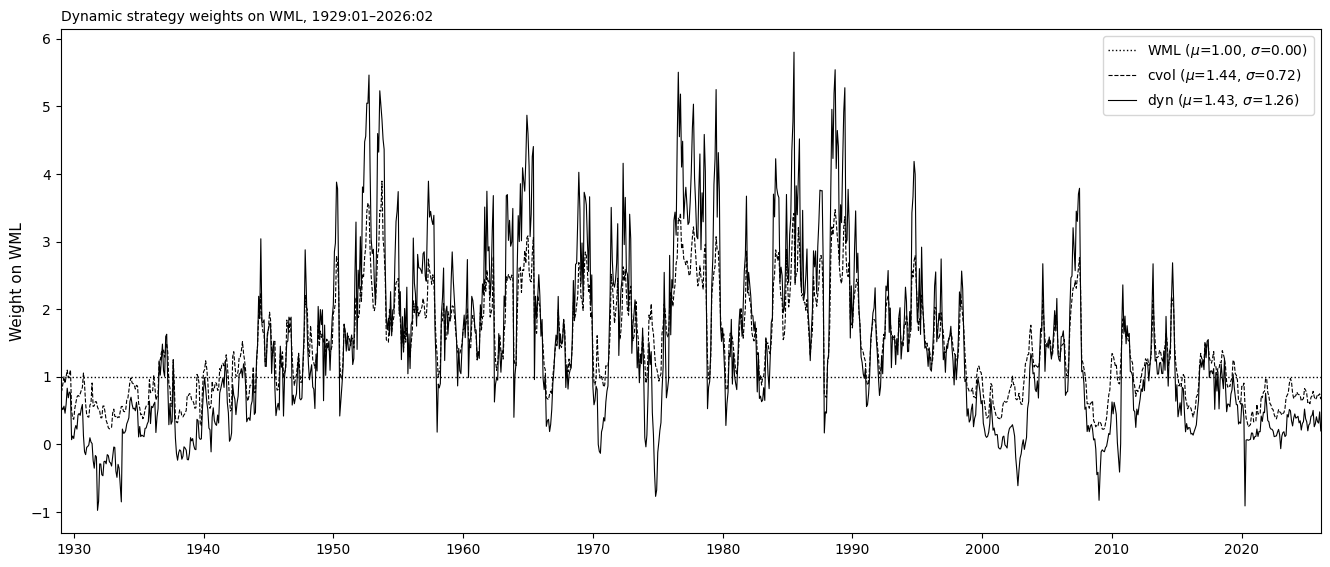

In [12]:
# Figure 3: Dynamic strategy weights on WML

# Assuming data_d (daily) and data_m (monthly) are already loaded
wml_daily_f5 = data_d['WML']
daily_dates_f5 = data_d.index
dates_f5 = data_m.index
n_f5 = len(dates_f5)
wml_f5 = data_m['WML'].values

# 1. Constant volatility weights (Barroso & Santa-Clara)
sigma_wml_monthly = np.full(n_f5, np.nan)
for i, mdate in enumerate(dates_f5):
    first_day = mdate.replace(day=1)
    d_idx = daily_dates_f5.searchsorted(first_day)
    s = max(0, d_idx - 126)
    if d_idx - s >= 60:
        vals = wml_daily_f5.iloc[s:d_idx].dropna().values
        if len(vals) >= 60:
            sigma_wml_monthly[i] = np.std(vals, ddof=1) * np.sqrt(21)

w_cvol_raw = 1.0 / sigma_wml_monthly

# 2. Dynamic weights (Daniel & Moskowitz)

# A. Mean Forecast
mkt_gross_f5 = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y_f5 = mkt_gross_f5.rolling(24).apply(np.prod, raw=True).shift(1) - 1
I_B_f5 = np.where(mkt_2y_f5.isna(), np.nan, (mkt_2y_f5 < 0).astype(float))

mkt_daily_f5 = data_d['Mkt-RF'] + data_d['RF']
sigma2_mkt_f5 = np.full(n_f5, np.nan)
for i, mdate in enumerate(dates_f5):
    first_day = mdate.replace(day=1)
    d_idx = daily_dates_f5.searchsorted(first_day)
    s = max(0, d_idx - 126)
    if d_idx - s >= 60:
        vals = mkt_daily_f5.iloc[s:d_idx].dropna().values
        if len(vals) >= 60:
            sigma2_mkt_f5[i] = np.var(vals, ddof=1) * 252

# Forecasting regression (Table 5, Spec 4: Intercept + Interaction ONLY)
interaction_f5 = I_B_f5 * sigma2_mkt_f5
mask_f5 = ~(np.isnan(wml_f5) | np.isnan(interaction_f5))

X_f5 = np.column_stack([np.ones(mask_f5.sum()), interaction_f5[mask_f5]])
y_f5 = wml_f5[mask_f5]
b_f5 = np.linalg.lstsq(X_f5, y_f5, rcond=None)[0]

mu_hat_f5 = np.full(n_f5, np.nan)
mu_hat_f5[mask_f5] = X_f5 @ b_f5

# B. Variance Forecast (GJR-GARCH + Blending)
# Fit GJR-GARCH(1,1) on daily returns (scaled by 100 for optimizer stability)
am = arch_model(wml_daily_f5.dropna() * 100, mean='Constant', vol='GARCH', p=1, o=1, q=1)
res_g = am.fit(disp='off')

# Extract conditional VARIANCE (annualized, reversing the 100 scaling)
garch_var_daily = (res_g.conditional_volatility / 100)**2 * 252 
garch_var_daily = garch_var_daily.reindex(wml_daily_f5.index)

garch_var_monthly = np.full(n_f5, np.nan)
realized_126d_var = np.full(n_f5, np.nan)
forward_22d_var = np.full(n_f5, np.nan)

for i, mdate in enumerate(dates_f5):
    first_day = mdate.replace(day=1)
    d_idx = daily_dates_f5.searchsorted(first_day)
    
    # Lagged 126-day window (t-126 to t)
    s_past = max(0, d_idx - 126)
    if d_idx - s_past >= 60:
        vals_past = wml_daily_f5.iloc[s_past:d_idx].dropna().values
        realized_126d_var[i] = np.var(vals_past, ddof=1) * 252  # Annualized VARIANCE
        
        # 'arch' generates the forecast FOR d_idx using data up to d_idx-1
        if d_idx < len(garch_var_daily):
            garch_var_monthly[i] = garch_var_daily.iloc[d_idx]
            
    # Forward 22-day window (t to t+22) for the OLS dependent variable
    e_future = min(len(daily_dates_f5), d_idx + 22)
    if e_future - d_idx >= 10:
        vals_future = wml_daily_f5.iloc[d_idx:e_future].dropna().values
        forward_22d_var[i] = np.var(vals_future, ddof=1) * 252  # Annualized VARIANCE

# Blend the VARIANCE forecasts via OLS (Appendix D Regression)
valid_idx = ~(np.isnan(forward_22d_var) | np.isnan(garch_var_monthly) | np.isnan(realized_126d_var))

Y_var = forward_22d_var[valid_idx]
X_var = np.column_stack([garch_var_monthly[valid_idx], realized_126d_var[valid_idx]])
X_var = sm.add_constant(X_var)

var_model = sm.OLS(Y_var, X_var).fit()

# Predict fitted VARIANCE across the whole timeline
X_all = np.column_stack([garch_var_monthly, realized_126d_var])
X_all = sm.add_constant(X_all)
fitted_var_ann = var_model.predict(X_all)

# Convert annualized blended variance to monthly variance for the weight denominator
h_f5_blended = fitted_var_ann / 12

# Raw dynamic weight: mu_hat / h
w_dyn_raw = mu_hat_f5 / h_f5_blended

# 3. Scale weights to match static WML volatility
mask_valid_all = mask_f5 & ~np.isnan(w_dyn_raw) & ~np.isnan(w_cvol_raw)
dates_valid = dates_f5[mask_valid_all]
wml_valid = wml_f5[mask_valid_all]
wml_std = np.std(wml_valid)

# cvol scaling
w_cvol_valid_raw = w_cvol_raw[mask_valid_all]
managed_cvol = w_cvol_valid_raw * wml_valid
scale_cvol = wml_std / np.std(managed_cvol)
w_cvol_f5 = w_cvol_valid_raw * scale_cvol

# dyn scaling
w_dyn_valid_raw = w_dyn_raw[mask_valid_all]
managed_dyn = w_dyn_valid_raw * wml_valid
scale_dyn = wml_std / np.std(managed_dyn)
w_dyn_f5 = w_dyn_valid_raw * scale_dyn

# Plotting
fig, ax = plt.subplots(figsize=(14, 6))

mu_cv = np.mean(w_cvol_f5)
sd_cv = np.std(w_cvol_f5)
mu_dy = np.mean(w_dyn_f5)
sd_dy = np.std(w_dyn_f5)

ax.axhline(1, color='k', ls=':', lw=1.0,
           label=rf'WML ($\mu$=1.00, $\sigma$=0.00)')
ax.plot(dates_valid, w_cvol_f5, 'k--', lw=0.8,
        label=rf'cvol ($\mu$={mu_cv:.2f}, $\sigma$={sd_cv:.2f})')
ax.plot(dates_valid, w_dyn_f5, 'k-', lw=0.8,
        label=rf'dyn ($\mu$={mu_dy:.2f}, $\sigma$={sd_dy:.2f})')

ax.set_ylabel('Weight on WML', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(dates_valid[0], dates_valid[-1])
ax.set_title(
    f'Dynamic strategy weights on WML, '
    f'{dates_valid[0].strftime("%Y:%m")}–{dates_valid[-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)

fig.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.08)
save_fig(fig, 'fig_03_dynamic_weights')
plt.show()

### Figure A3: Strategy Weights During Major Crash Episodes

The full Figure 5 above is hard to read during specific crisis windows. Here we zoom into the four major momentum crash episodes to see how the cvol and dyn weights actually responded:

1. **Great Depression** (1929–1939)
2. **Dot-com bubble reversal** (1999–2003)
3. **Global Financial Crisis** (2007–2011)
4. **COVID-19 crash** (2019–2022)

The shaded bands mark the worst momentum-crash months in each episode (the same windows used in Figure 1). The static WML weight is constant at 1 (dotted), cvol shifts moderately around 1, and dyn can swing dramatically — including going **negative** (shorting WML) when the model anticipates a momentum crash.


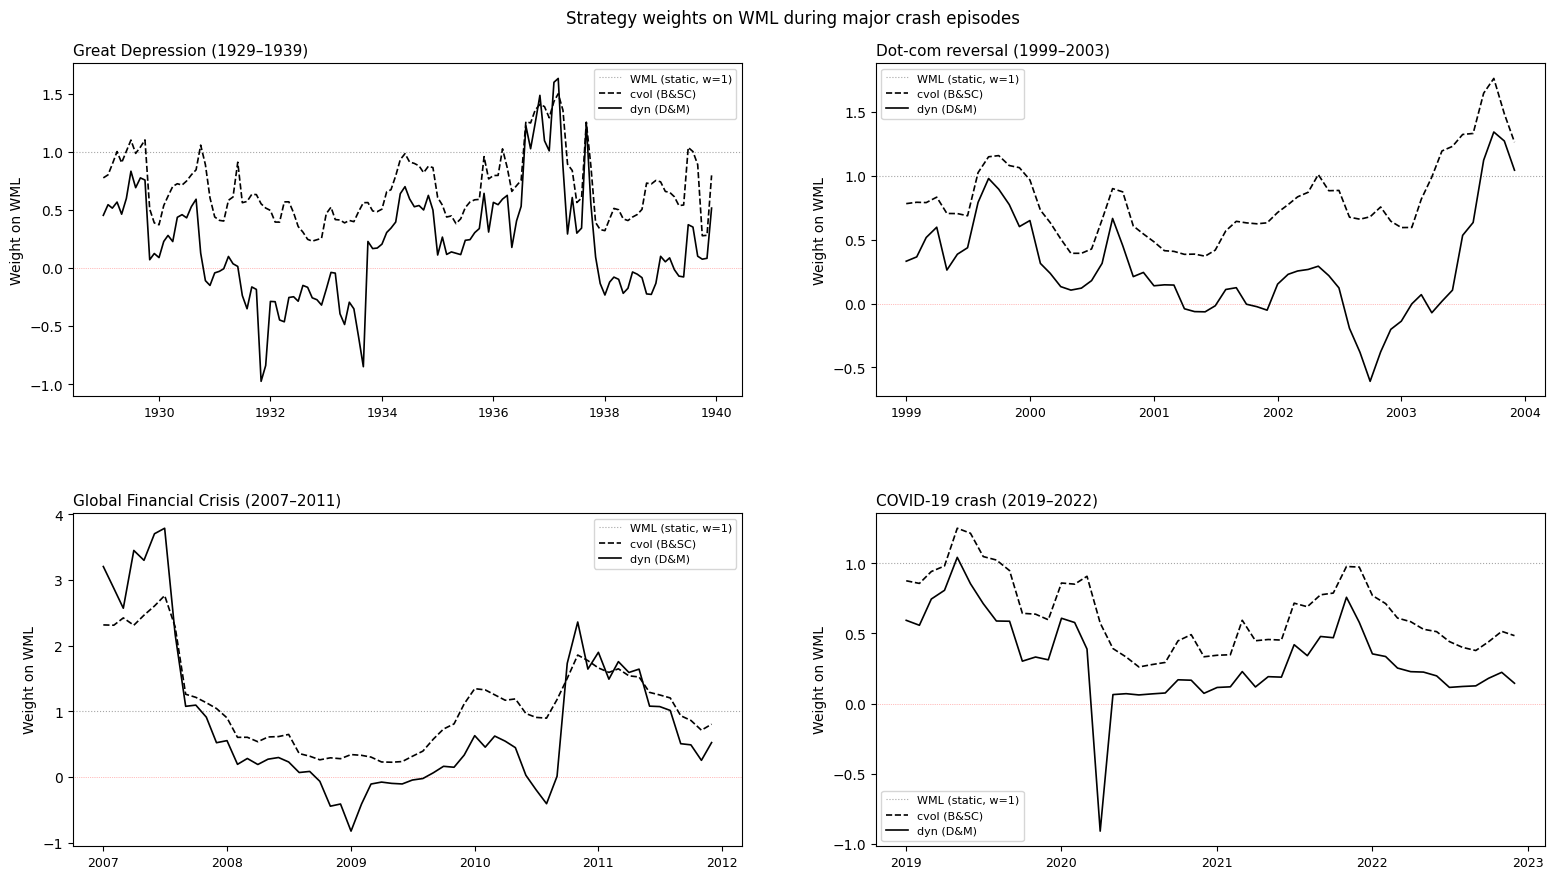

In [13]:
# Figure A3 (Figure 3 zoomed): weights during major crash episodes
# Reuses w_cvol_f5, w_dyn_f5, dates_valid from Figure 5 cell above

episodes = [
    ('Great Depression',    '1929-01', '1939-12', '1932-07', '1933-05', '#d4e6f1'),
    ('Dot-com reversal',    '1999-01', '2003-12', '2001-01', '2001-01', '#fce4d6'),
    ('Global Financial Crisis', '2007-01', '2011-12', '2009-03', '2009-05', '#fde8d8'),
    ('COVID-19 crash',      '2019-01', '2022-12', '2020-02', '2020-06', '#d5f5e3'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=False)
axes = axes.flatten()

for ax, (title, win_start, win_end, crash_start, crash_end, color) in zip(axes, episodes):
    mask = (dates_valid >= win_start) & (dates_valid <= win_end)
    
    # Static WML reference line
    ax.axhline(1, color='gray', ls=':', lw=0.8, alpha=0.7, label='WML (static, w=1)')
    ax.axhline(0, color='red', ls=':', lw=0.5, alpha=0.5)
    
    # cvol weights
    ax.plot(dates_valid[mask], w_cvol_f5[mask], 'k--', lw=1.2, label='cvol (B&SC)')
    
    # dyn weights
    ax.plot(dates_valid[mask], w_dyn_f5[mask], 'k-', lw=1.2, label='dyn (D&M)')
    
    ax.set_title(f'{title} ({win_start[:4]}\u2013{win_end[:4]})', fontsize=11, loc='left')
    ax.set_ylabel('Weight on WML', fontsize=10)
    ax.legend(loc='best', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(1 if (pd.Timestamp(win_end).year - pd.Timestamp(win_start).year) <= 5 else 2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=0, labelsize=9)

fig.suptitle('Strategy weights on WML during major crash episodes',
             fontsize=12, y=0.99)
fig.subplots_adjust(hspace=0.35, wspace=0.2, left=0.05, right=0.97, top=0.93, bottom=0.06)
save_fig(fig, 'fig_A3_dynamic_weights_zoom_crashes')
plt.show()


## Figure X3 – Dynamic Momentum Strategy Performance

Replication of Daniel & Moskowitz (2016), Figure 6. The figure compares the cumulative returns of three momentum strategies on a log scale, with all three scaled to the same annualized volatility as the static WML portfolio — making them directly comparable on a risk-adjusted basis.

### The three strategies
1. **WML (static)**: baseline winner-minus-loser momentum portfolio (weight = 1)
2. **cvol (Barroso & Santa-Clara 2015)**: constant-volatility scaling, $w_t = \bar{\sigma}/\hat{\sigma}_{t-1}$, where $\hat{\sigma}_{t-1}$ is the trailing 6-month realized volatility of WML
3. **dyn (Daniel & Moskowitz 2016)**: dynamic mean-variance optimal weighting, $w_t = \hat{\mu}_{t-1}/\hat{\sigma}^2_{t-1}$, where $\hat{\mu}_{t-1}$ comes from the conditional-mean forecasting regression (Table 5, spec 5) and $\hat{\sigma}^2_{t-1}$ from a GJR-GARCH(1,1) on the residuals

### Layout
- **Panel A (top, full width)**: Full sample (1927–2026), showing the long-run cumulative wealth of $1 invested in each strategy
- **Panels B–E (bottom 2×2 grid)**: Quarter-century subsamples, each rebased to $1, demonstrating that the dyn > cvol > WML ranking is **robust across all market regimes** — not driven by a single crisis or boom period

### Why 19% annualized vol?
Following the paper, all strategies are leverage-scaled to match the annualized volatility of the CRSP value-weighted market index (~19%). This removes the trivial "more leverage = more return" effect and isolates the **risk-adjusted improvement** from each strategy's timing ability. The legend reports the annualized Sharpe ratio of each strategy in each subsample.

### Key takeaway
The dynamic strategy systematically outperforms both the static WML and the constant-volatility approach in every subsample. This confirms that the time-varying conditional mean and variance captured by the forecasting regression + GARCH machinery deliver real economic value beyond simple volatility targeting — primarily by reducing or even reversing exposure to WML during predictable crash episodes (1932, 2009, 2020).


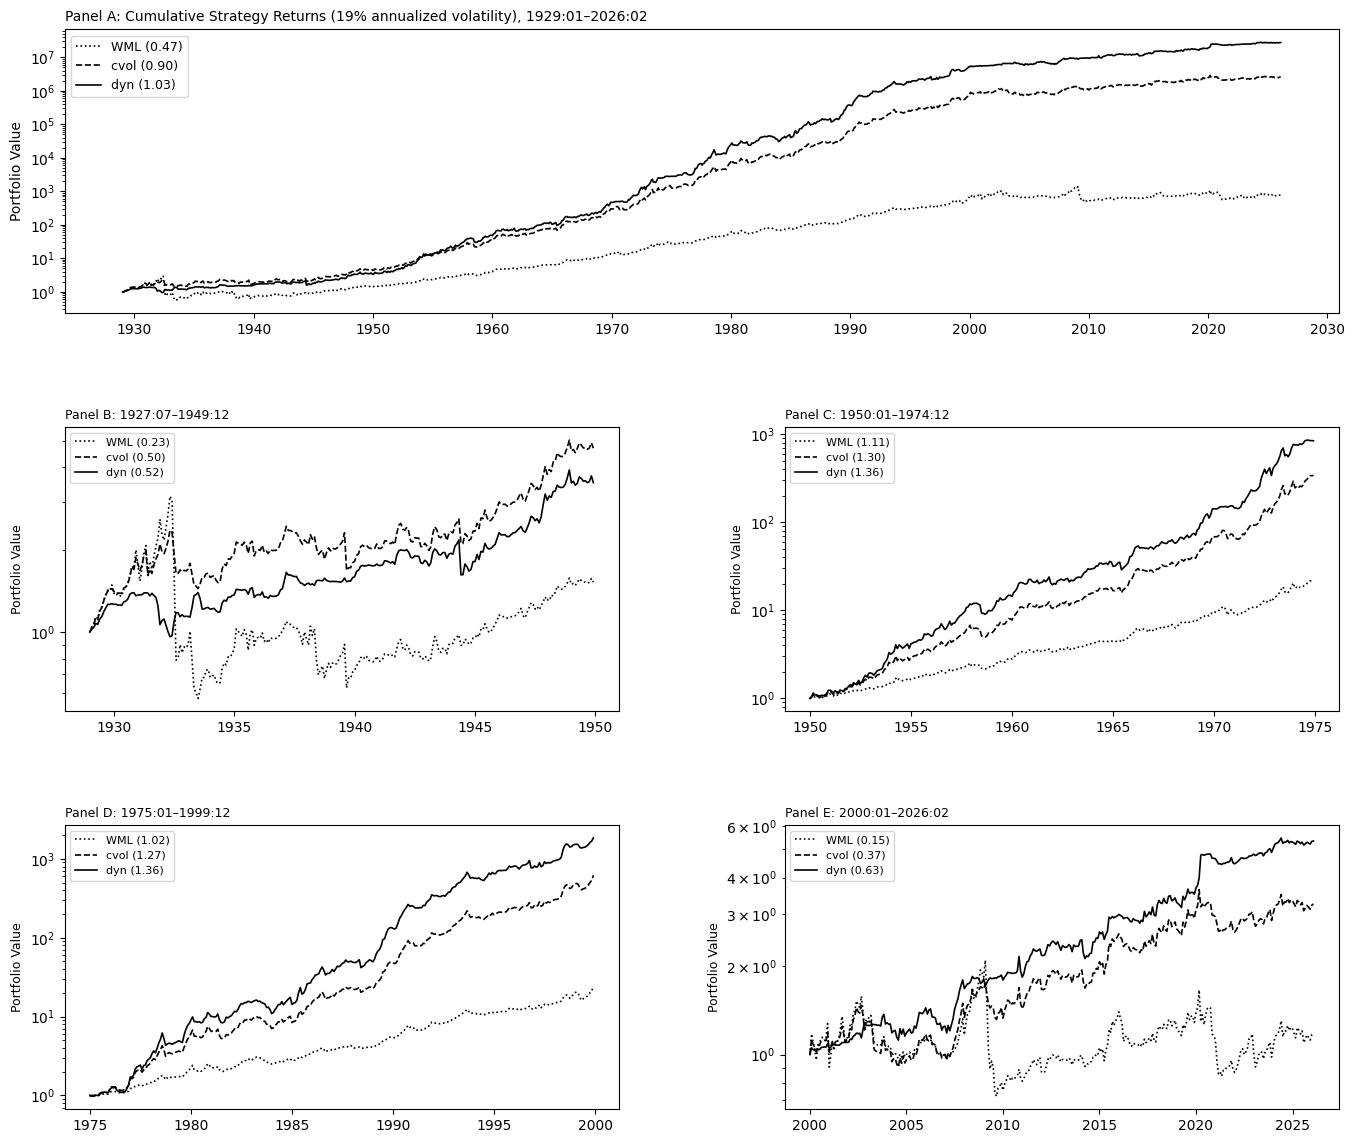

In [14]:
# Figure X3: Dynamic momentum strategy performance
# Removed from thesis and merged with X4 to figure 4
# Cumulative returns to WML, cvol, and dyn strategies
# All scaled to 19% annualized volatility (same as CRSP VW market index)
# Legend shows annualized Sharpe ratios for each sub-period

# Scale all strategies to 19% annualized vol
target_vol_ann = 0.19  # 19% annualized, matching market

# Managed returns (using weights from Figure 5 cell)
wml_valid = wml_f5[mask_f5]  # static WML returns
r_wml = wml_valid             # weight=1 always
r_cvol = w_cvol_f5 * wml_valid  # cvol managed
r_dyn  = w_dyn_f5 * wml_valid   # dyn managed

# Scale each to target 19% annualized vol
scale_wml  = target_vol_ann / (np.std(r_wml) * np.sqrt(12))
scale_cvol = target_vol_ann / (np.nanstd(r_cvol) * np.sqrt(12))
scale_dyn  = target_vol_ann / (np.std(r_dyn) * np.sqrt(12))

r_wml_scaled  = r_wml * scale_wml
r_cvol_scaled = r_cvol * scale_cvol
r_dyn_scaled  = r_dyn * scale_dyn

# Cumulative wealth (starting at $1)
cum_wml_s  = np.cumprod(1 + np.nan_to_num(r_wml_scaled))
cum_cvol_s = np.cumprod(1 + np.nan_to_num(r_cvol_scaled))
cum_dyn_s  = np.cumprod(1 + np.nan_to_num(r_dyn_scaled))

dates_valid_f6 = dates_f5[mask_f5]

# Helper: annualized Sharpe ratio for a sub-period
def sharpe_ann(r):
    r_clean = r[~np.isnan(r)]
    if len(r_clean) < 12:
        return np.nan
    return (r_clean.mean() / r_clean.std()) * np.sqrt(12)

# Define sub-periods
# Paper uses quarter-century subsamples; we extend to current data
subperiods = [
    ('1927-07', '1949-12', 'B'),
    ('1950-01', '1974-12', 'C'),
    ('1975-01', '1999-12', 'D'),
    ('2000-01', None,      'E'),  # None = end of sample
]

# Plot
fig = plt.figure(figsize=(14, 12))

# Panel A: Full sample (top, spanning full width)
ax_a = fig.add_subplot(3, 1, 1)
sr_wml_full  = sharpe_ann(r_wml_scaled)
sr_cvol_full = sharpe_ann(r_cvol_scaled)
sr_dyn_full  = sharpe_ann(r_dyn_scaled)

ax_a.semilogy(dates_valid_f6, cum_wml_s,  'k:', lw=1.2,
              label=f'WML ({sr_wml_full:.2f})')
ax_a.semilogy(dates_valid_f6, cum_cvol_s, 'k--', lw=1.2,
              label=f'cvol ({sr_cvol_full:.2f})')
ax_a.semilogy(dates_valid_f6, cum_dyn_s,  'k-', lw=1.2,
              label=f'dyn ({sr_dyn_full:.2f})')
ax_a.set_ylabel('Portfolio Value', fontsize=10)
ax_a.legend(loc='upper left', fontsize=9)
ax_a.set_title(
    f'Panel A: Cumulative Strategy Returns (19% annualized volatility), '
    f'{dates_valid_f6[0].strftime("%Y:%m")}\u2013{dates_valid_f6[-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax_a.xaxis.set_major_locator(mdates.YearLocator(10))
ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panels B–E: Sub-periods (2x2 grid)
for idx, (start, end, panel_letter) in enumerate(subperiods):
    ax = fig.add_subplot(3, 2, idx + 3)  # positions 3,4,5,6
    
    mask_sub = dates_valid_f6 >= start
    if end is not None:
        mask_sub = mask_sub & (dates_valid_f6 <= end)
    
    i0 = np.where(mask_sub)[0][0]
    
    # Rebase cumulative to 1 at start of sub-period
    cum_w = cum_wml_s[mask_sub]  / cum_wml_s[i0]
    cum_c = cum_cvol_s[mask_sub] / cum_cvol_s[i0]
    cum_d = cum_dyn_s[mask_sub]  / cum_dyn_s[i0]
    
    # Sharpe ratios for this sub-period
    sr_w = sharpe_ann(r_wml_scaled[mask_sub])
    sr_c = sharpe_ann(r_cvol_scaled[mask_sub])
    sr_d = sharpe_ann(r_dyn_scaled[mask_sub])
    
    ax.semilogy(dates_valid_f6[mask_sub], cum_w, 'k:', lw=1.2,
                label=f'WML ({sr_w:.2f})')
    ax.semilogy(dates_valid_f6[mask_sub], cum_c, 'k--', lw=1.2,
                label=f'cvol ({sr_c:.2f})')
    ax.semilogy(dates_valid_f6[mask_sub], cum_d, 'k-', lw=1.2,
                label=f'dyn ({sr_d:.2f})')
    
    end_label = dates_valid_f6[mask_sub][-1].strftime('%Y:%m') if end is None else end[:4] + ':' + end[5:7]
    start_label = start[:4] + ':' + start[5:7]
    ax.set_title(f'Panel {panel_letter}: {start_label}\u2013{end_label}',
                 fontsize=9, loc='left')
    ax.set_ylabel('Portfolio Value', fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(hspace=0.4, wspace=0.3, left=0.06, right=0.97, top=0.95, bottom=0.05)
save_fig(fig, 'fig_X3_dynamic_strategy_comparison_panel_a')
plt.show()


## Figures X4 and A1: 42-Day vs 126-Day Volatility Window
## Tables 7 and A1: Sharpe and Wealth Comparison

Figure 7 above uses a **126-day (6-month) trailing window** to estimate the WML portfolio's realized volatility — the standard choice in Barroso & Santa-Clara (2015) and Daniel & Moskowitz (2016).

Here we test **robustness to the volatility lookback window** by recomputing the cvol and dyn strategies with a **42-day (~2-month) window** instead. The 42-day window is the same horizon Daniel & Moskowitz use to estimate market betas in Figure 4 of the paper.

### Trade-off
- **Shorter window (42 days)**: more responsive to vol regime changes, but noisier estimates
- **Longer window (126 days)**: smoother estimates, but slower to react to abrupt vol shifts (e.g., the COVID crash)

If the 42-day version produces similar Sharpe ratios and ranking (dyn > cvol > WML) across all subsamples, that confirms the strategies are **robust to the volatility estimation window** — the timing benefit comes from the conditional mean signal, not from a particular lookback choice.


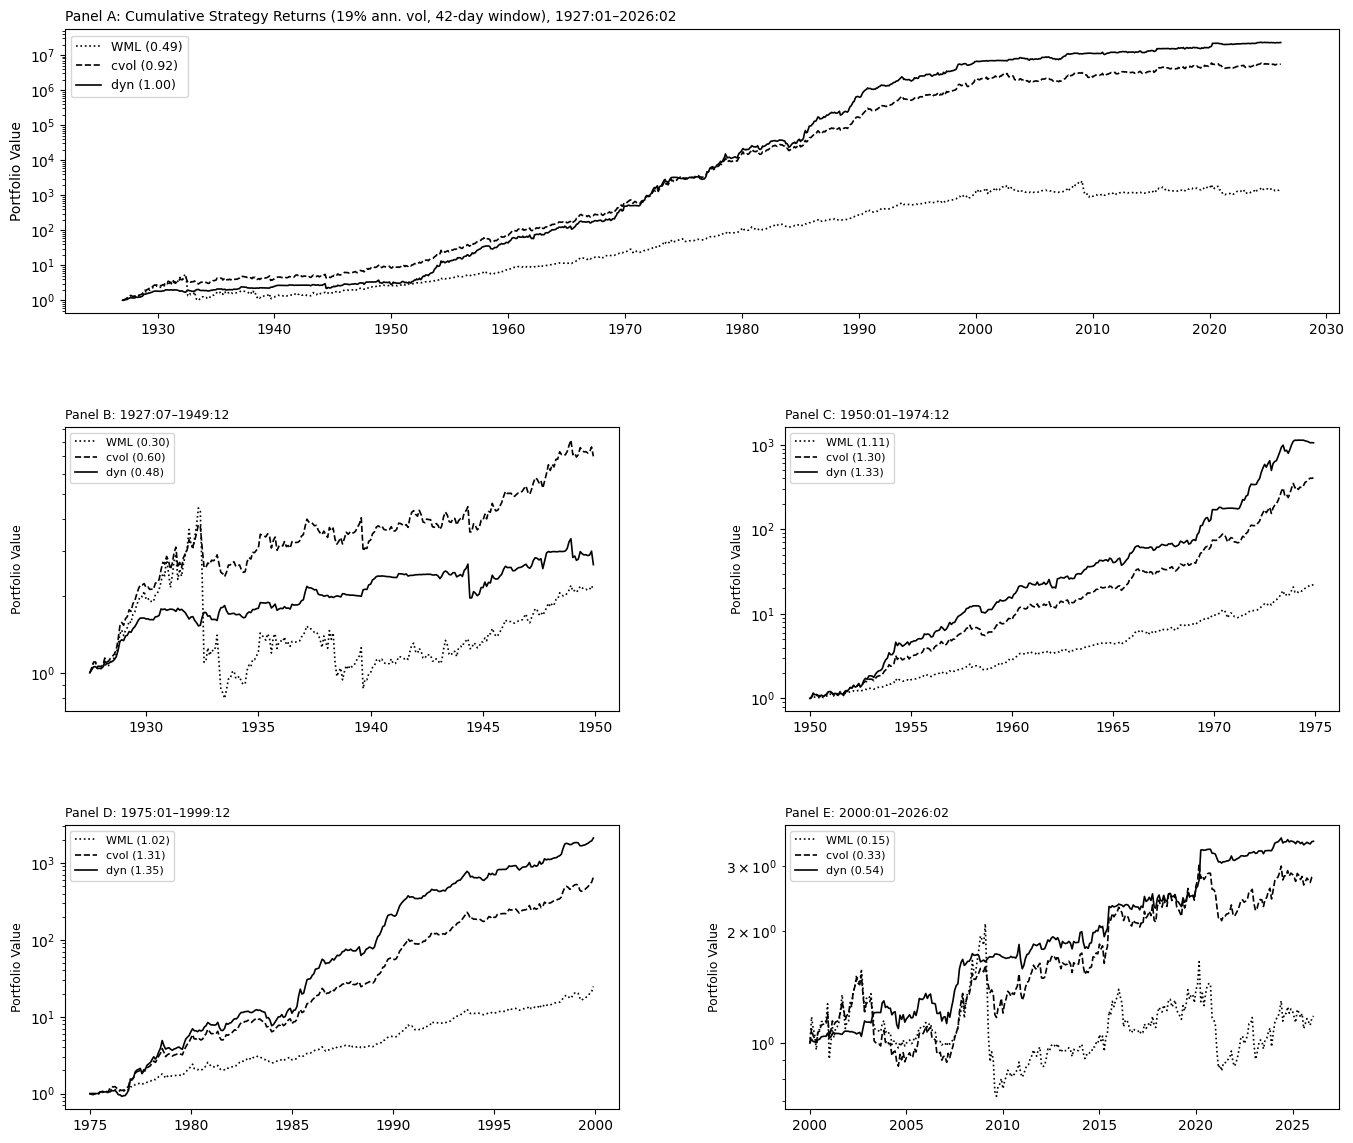


Sharpe ratio comparison: 126-day vs 42-day volatility window

Format: WML (window-independent) | cvol & dyn: 126-day / 42-day
[save_table PNG warning] table_07_sharpe_comparison: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,WML,cvol,dyn
Subsample,,,
Full sample,0.47,0.90 / 0.92,1.03 / 1.00
Panel B: 1927–1949,0.23,0.50 / 0.60,0.52 / 0.48
Panel C: 1950–1974,1.11,1.30 / 1.30,1.36 / 1.33
Panel D: 1975–1999,1.02,1.27 / 1.31,1.36 / 1.35
Panel E: 2000–2026,0.15,0.37 / 0.33,0.63 / 0.54


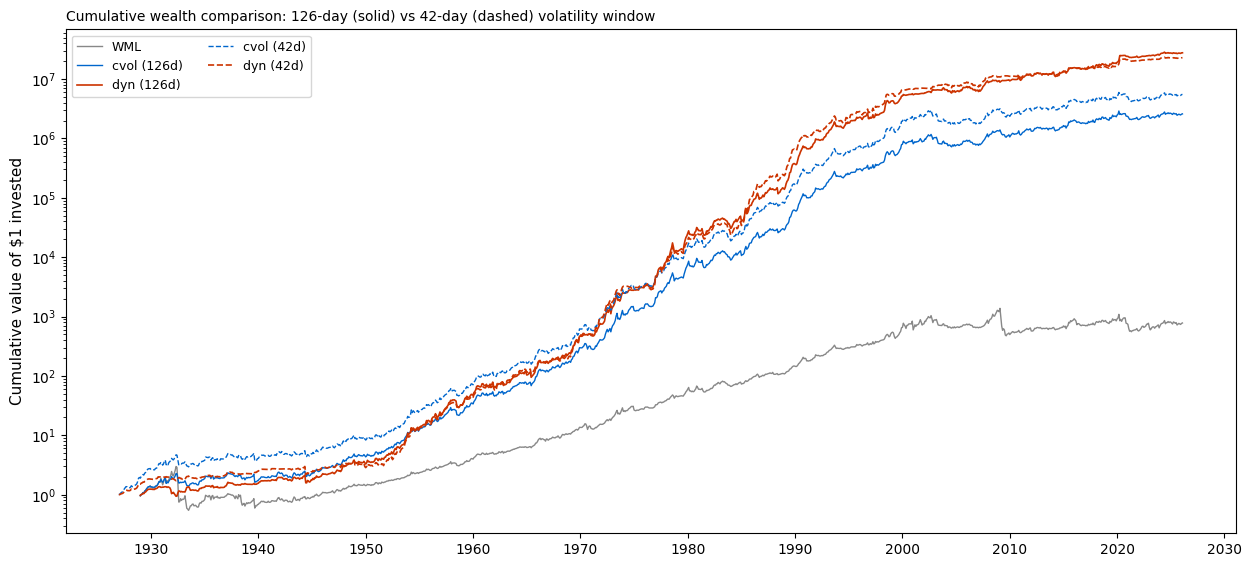

Final cumulative value of $1 invested at start of full sample:
(WML is identical across windows; not shown)
[save_table PNG warning] table_A1_wealth_comparison: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,126-day window,42-day window,Ratio (42d/126d)
Strategy,,,
cvol,"$2,593,021.01","$5,525,147.00",2.13x
dyn,"$27,725,484.43","$22,872,602.06",0.82x


In [15]:
# Figure X4: 42-day rolling volatility window
# Removed from thesis, and merged with X3 to figure 4
# Recompute cvol and dyn weights using 42-day daily WML returns instead of 126-day

# 1. Compute 42-day realized monthly vol of WML
wml_daily_f6b = data_d['WML']
daily_dates_f6b = data_d.index
dates_f6b = data_m.index
n_f6b = len(dates_f6b)
wml_f6b = data_m['WML'].values

sigma_wml_42d = np.full(n_f6b, np.nan)
for i, mdate in enumerate(dates_f6b):
    d_idx = daily_dates_f6b.searchsorted(mdate)
    s = max(0, d_idx - 42)
    if d_idx - s >= 20:
        vals = wml_daily_f6b.iloc[s:d_idx].dropna().values
        if len(vals) >= 20:
            # Convert daily std to monthly: std * sqrt(21)
            sigma_wml_42d[i] = np.std(vals, ddof=1) * np.sqrt(21)

# Raw cvol weight: w = 1/sigma_42d (will be scaled later)
w_cvol_42d_raw = 1.0 / sigma_wml_42d

# 2. Compute 42-day market variance for the dyn forecasting regression
mkt_daily_f6b = data_d['Mkt-RF']
sigma2_mkt_42d = np.full(n_f6b, np.nan)
for i, mdate in enumerate(dates_f6b):
    d_idx = daily_dates_f6b.searchsorted(mdate)
    s = max(0, d_idx - 42)
    if d_idx - s >= 20:
        vals = mkt_daily_f6b.iloc[s:d_idx].dropna().values
        if len(vals) >= 20:
            sigma2_mkt_42d[i] = np.var(vals, ddof=1) * 252

# Bear indicator (same as before)
mkt_gross_f6b = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y_f6b = mkt_gross_f6b.rolling(24).apply(np.prod, raw=True).shift(1) - 1
I_B_f6b = (mkt_2y_f6b < 0).astype(float).values

mask_f6b = ~(np.isnan(wml_f6b) | np.isnan(I_B_f6b) | np.isnan(sigma2_mkt_42d) | np.isnan(sigma_wml_42d))
X_f6b = np.column_stack([np.ones(mask_f6b.sum()), I_B_f6b[mask_f6b], sigma2_mkt_42d[mask_f6b], I_B_f6b[mask_f6b] * sigma2_mkt_42d[mask_f6b]])
y_f6b = wml_f6b[mask_f6b]
b_f6b = np.linalg.lstsq(X_f6b, y_f6b, rcond=None)[0]
eps_f6b = y_f6b - X_f6b @ b_f6b
mu_hat_f6b = X_f6b @ b_f6b

# GJR-GARCH on residuals (reuse function from Figure 5 if available, else define)
try:
    am = arch_model(eps_f6b * 100, mean='Zero', vol='GARCH', p=1, o=1, q=1, dist='normal')
    res_g = am.fit(disp='off')
    h_f6b = res_g.conditional_volatility.values ** 2 / 10000  # back to original scale
except Exception:
    # Fallback: simple realized variance
    h_f6b = sigma_wml_42d[mask_f6b] ** 2

w_dyn_42d_raw = mu_hat_f6b / h_f6b

# 3. Vol-match scaling
wml_valid_42d = wml_f6b[mask_f6b]
wml_std_42d = np.std(wml_valid_42d)

w_cvol_42d_valid = w_cvol_42d_raw[mask_f6b]
scale_cvol_42d = wml_std_42d / np.nanstd(w_cvol_42d_valid * wml_valid_42d)
w_cvol_42d = w_cvol_42d_valid * scale_cvol_42d

scale_dyn_42d = wml_std_42d / np.std(w_dyn_42d_raw * wml_valid_42d)
w_dyn_42d = w_dyn_42d_raw * scale_dyn_42d

# 4. Managed returns and scale to 19% annualized vol
r_wml_42d = wml_valid_42d.copy()
r_cvol_42d_m = w_cvol_42d * wml_valid_42d
r_dyn_42d_m = w_dyn_42d * wml_valid_42d

target_vol_ann_42d = 0.19
scale19_wml  = target_vol_ann_42d / (np.std(r_wml_42d) * np.sqrt(12))
scale19_cvol = target_vol_ann_42d / (np.nanstd(r_cvol_42d_m) * np.sqrt(12))
scale19_dyn  = target_vol_ann_42d / (np.std(r_dyn_42d_m) * np.sqrt(12))

r_wml_42d_s  = r_wml_42d * scale19_wml
r_cvol_42d_s = r_cvol_42d_m * scale19_cvol
r_dyn_42d_s  = r_dyn_42d_m * scale19_dyn

cum_wml_42d  = np.cumprod(1 + np.nan_to_num(r_wml_42d_s))
cum_cvol_42d = np.cumprod(1 + np.nan_to_num(r_cvol_42d_s))
cum_dyn_42d  = np.cumprod(1 + np.nan_to_num(r_dyn_42d_s))

dates_42d = dates_f6b[mask_f6b]

# 5. Helper for Sharpe
def sharpe_42d(r):
    r = r[~np.isnan(r)]
    return (r.mean() / r.std()) * np.sqrt(12) if len(r) > 12 else np.nan

# 6. Plot 5 panels matching Figure 6 layout
subperiods_42d = [
    ('1927-07', '1949-12', 'B'),
    ('1950-01', '1974-12', 'C'),
    ('1975-01', '1999-12', 'D'),
    ('2000-01', None,       'E'),
]

fig6b = plt.figure(figsize=(14, 12))

# Panel A: Full sample
ax_a = fig6b.add_subplot(3, 1, 1)
sr_w_full = sharpe_42d(r_wml_42d_s)
sr_c_full = sharpe_42d(r_cvol_42d_s)
sr_d_full = sharpe_42d(r_dyn_42d_s)
ax_a.semilogy(dates_42d, cum_wml_42d,  'k:',  lw=1.2, label=f'WML ({sr_w_full:.2f})')
ax_a.semilogy(dates_42d, cum_cvol_42d, 'k--', lw=1.2, label=f'cvol ({sr_c_full:.2f})')
ax_a.semilogy(dates_42d, cum_dyn_42d,  'k-',  lw=1.2, label=f'dyn ({sr_d_full:.2f})')
ax_a.set_ylabel('Portfolio Value', fontsize=10)
ax_a.legend(loc='upper left', fontsize=9)
ax_a.set_title(f'Panel A: Cumulative Strategy Returns (19% ann. vol, 42-day window), {dates_42d[0].strftime("%Y:%m")}\u2013{dates_42d[-1].strftime("%Y:%m")}', fontsize=10, loc='left')
ax_a.xaxis.set_major_locator(mdates.YearLocator(10))
ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panels B–E
for idx, (start, end, panel_letter) in enumerate(subperiods_42d):
    ax = fig6b.add_subplot(3, 2, idx + 3)
    mask_sub = dates_42d >= start
    if end is not None:
        mask_sub = mask_sub & (dates_42d <= end)
    if mask_sub.sum() == 0:
        continue
    i0 = np.where(mask_sub)[0][0]
    cum_w = cum_wml_42d[mask_sub]  / cum_wml_42d[i0]
    cum_c = cum_cvol_42d[mask_sub] / cum_cvol_42d[i0]
    cum_d = cum_dyn_42d[mask_sub]  / cum_dyn_42d[i0]
    sr_w = sharpe_42d(r_wml_42d_s[mask_sub])
    sr_c = sharpe_42d(r_cvol_42d_s[mask_sub])
    sr_d = sharpe_42d(r_dyn_42d_s[mask_sub])
    ax.semilogy(dates_42d[mask_sub], cum_w, 'k:',  lw=1.2, label=f'WML ({sr_w:.2f})')
    ax.semilogy(dates_42d[mask_sub], cum_c, 'k--', lw=1.2, label=f'cvol ({sr_c:.2f})')
    ax.semilogy(dates_42d[mask_sub], cum_d, 'k-',  lw=1.2, label=f'dyn ({sr_d:.2f})')
    end_label = dates_42d[mask_sub][-1].strftime('%Y:%m') if end is None else end[:4] + ':' + end[5:7]
    start_label = start[:4] + ':' + start[5:7]
    ax.set_title(f'Panel {panel_letter}: {start_label}\u2013{end_label}', fontsize=9, loc='left')
    ax.set_ylabel('Portfolio Value', fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig6b.subplots_adjust(hspace=0.4, wspace=0.3, left=0.06, right=0.97, top=0.95, bottom=0.05)
save_fig(fig6b, 'fig_X4_dynamic_strategy_comparison_panel_b')
plt.show()

# Table 7. Sharpe-ratio comparison table: 126-day vs 42-day
print('\nSharpe ratio comparison: 126-day vs 42-day volatility window')
print()
comparison = []
# Full sample
row_full = {'Subsample': 'Full sample',
            'WML': f'{sharpe_ann(r_wml_scaled):.2f}',
            'cvol': f'{sharpe_ann(r_cvol_scaled):.2f} / {sr_c_full:.2f}',
            'dyn': f'{sharpe_ann(r_dyn_scaled):.2f} / {sr_d_full:.2f}'}
comparison.append(row_full)
for start, end, panel in subperiods_42d:
    sub_label = f'Panel {panel}: {start[:4]}\u2013{(end[:4] if end else dates_42d[-1].strftime("%Y"))}'
    m126 = dates_valid_f6 >= start
    m42 = dates_42d >= start
    if end is not None:
        m126 = m126 & (dates_valid_f6 <= end)
        m42 = m42 & (dates_42d <= end)
    comparison.append({
        'Subsample': sub_label,
        'WML':  f'{sharpe_ann(r_wml_scaled[m126]):.2f}',
        'cvol': f'{sharpe_ann(r_cvol_scaled[m126]):.2f} / {sharpe_42d(r_cvol_42d_s[m42]):.2f}',
        'dyn':  f'{sharpe_ann(r_dyn_scaled[m126]):.2f} / {sharpe_42d(r_dyn_42d_s[m42]):.2f}',
    })
comp_df = pd.DataFrame(comparison).set_index('Subsample')
print('Format: WML (window-independent) | cvol & dyn: 126-day / 42-day')
save_table(comp_df, "table_07_sharpe_comparison")
display(comp_df)



# Side-by-side cumulative wealth plot: 126-day vs 42-day
fig_cmp, ax_cmp = plt.subplots(figsize=(13, 6))

# 126-day (solid)
ax_cmp.semilogy(dates_valid_f6, cum_wml_s,  color='#888888', ls='-', lw=1.0, label='WML')
ax_cmp.semilogy(dates_valid_f6, cum_cvol_s, color='#0066cc', ls='-', lw=1.0, label='cvol (126d)')
ax_cmp.semilogy(dates_valid_f6, cum_dyn_s,  color='#cc3300', ls='-', lw=1.2, label='dyn (126d)')

# 42-day (dashed)
ax_cmp.semilogy(dates_42d, cum_cvol_42d, color='#0066cc', ls='--', lw=1.0, label='cvol (42d)')
ax_cmp.semilogy(dates_42d, cum_dyn_42d,  color='#cc3300', ls='--', lw=1.2, label='dyn (42d)')

ax_cmp.set_ylabel('Cumulative value of $1 invested', fontsize=11)
ax_cmp.legend(loc='upper left', fontsize=9, ncol=2)
ax_cmp.set_title('Cumulative wealth comparison: 126-day (solid) vs 42-day (dashed) volatility window',
                 fontsize=10, loc='left')
ax_cmp.xaxis.set_major_locator(mdates.YearLocator(10))
ax_cmp.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig_cmp.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.08)
save_fig(fig_cmp, 'fig_A1_cum_wealth_different_lags')
plt.show()

# Table A1
# Cumulative wealth comparison table: $1 invested
# WML is identical in both windows (no vol estimation involved)
# We compare only cvol and dyn, which actually use the volatility window
final_126 = {'cvol': cum_cvol_s[-1], 'dyn': cum_dyn_s[-1]}
final_42  = {'cvol': cum_cvol_42d[-1], 'dyn': cum_dyn_42d[-1]}

wealth_df = pd.DataFrame({
    'Strategy': ['cvol', 'dyn'],
    '126-day window': [f'${final_126[s]:,.2f}' for s in ['cvol','dyn']],
    '42-day window':  [f'${final_42[s]:,.2f}' for s in ['cvol','dyn']],
    'Ratio (42d/126d)': [f'{final_42[s]/final_126[s]:.2f}x' for s in ['cvol','dyn']],
}).set_index('Strategy')
print('Final cumulative value of $1 invested at start of full sample:')
print('(WML is identical across windows; not shown)')
save_table(wealth_df, "table_A1_wealth_comparison")
display(wealth_df)


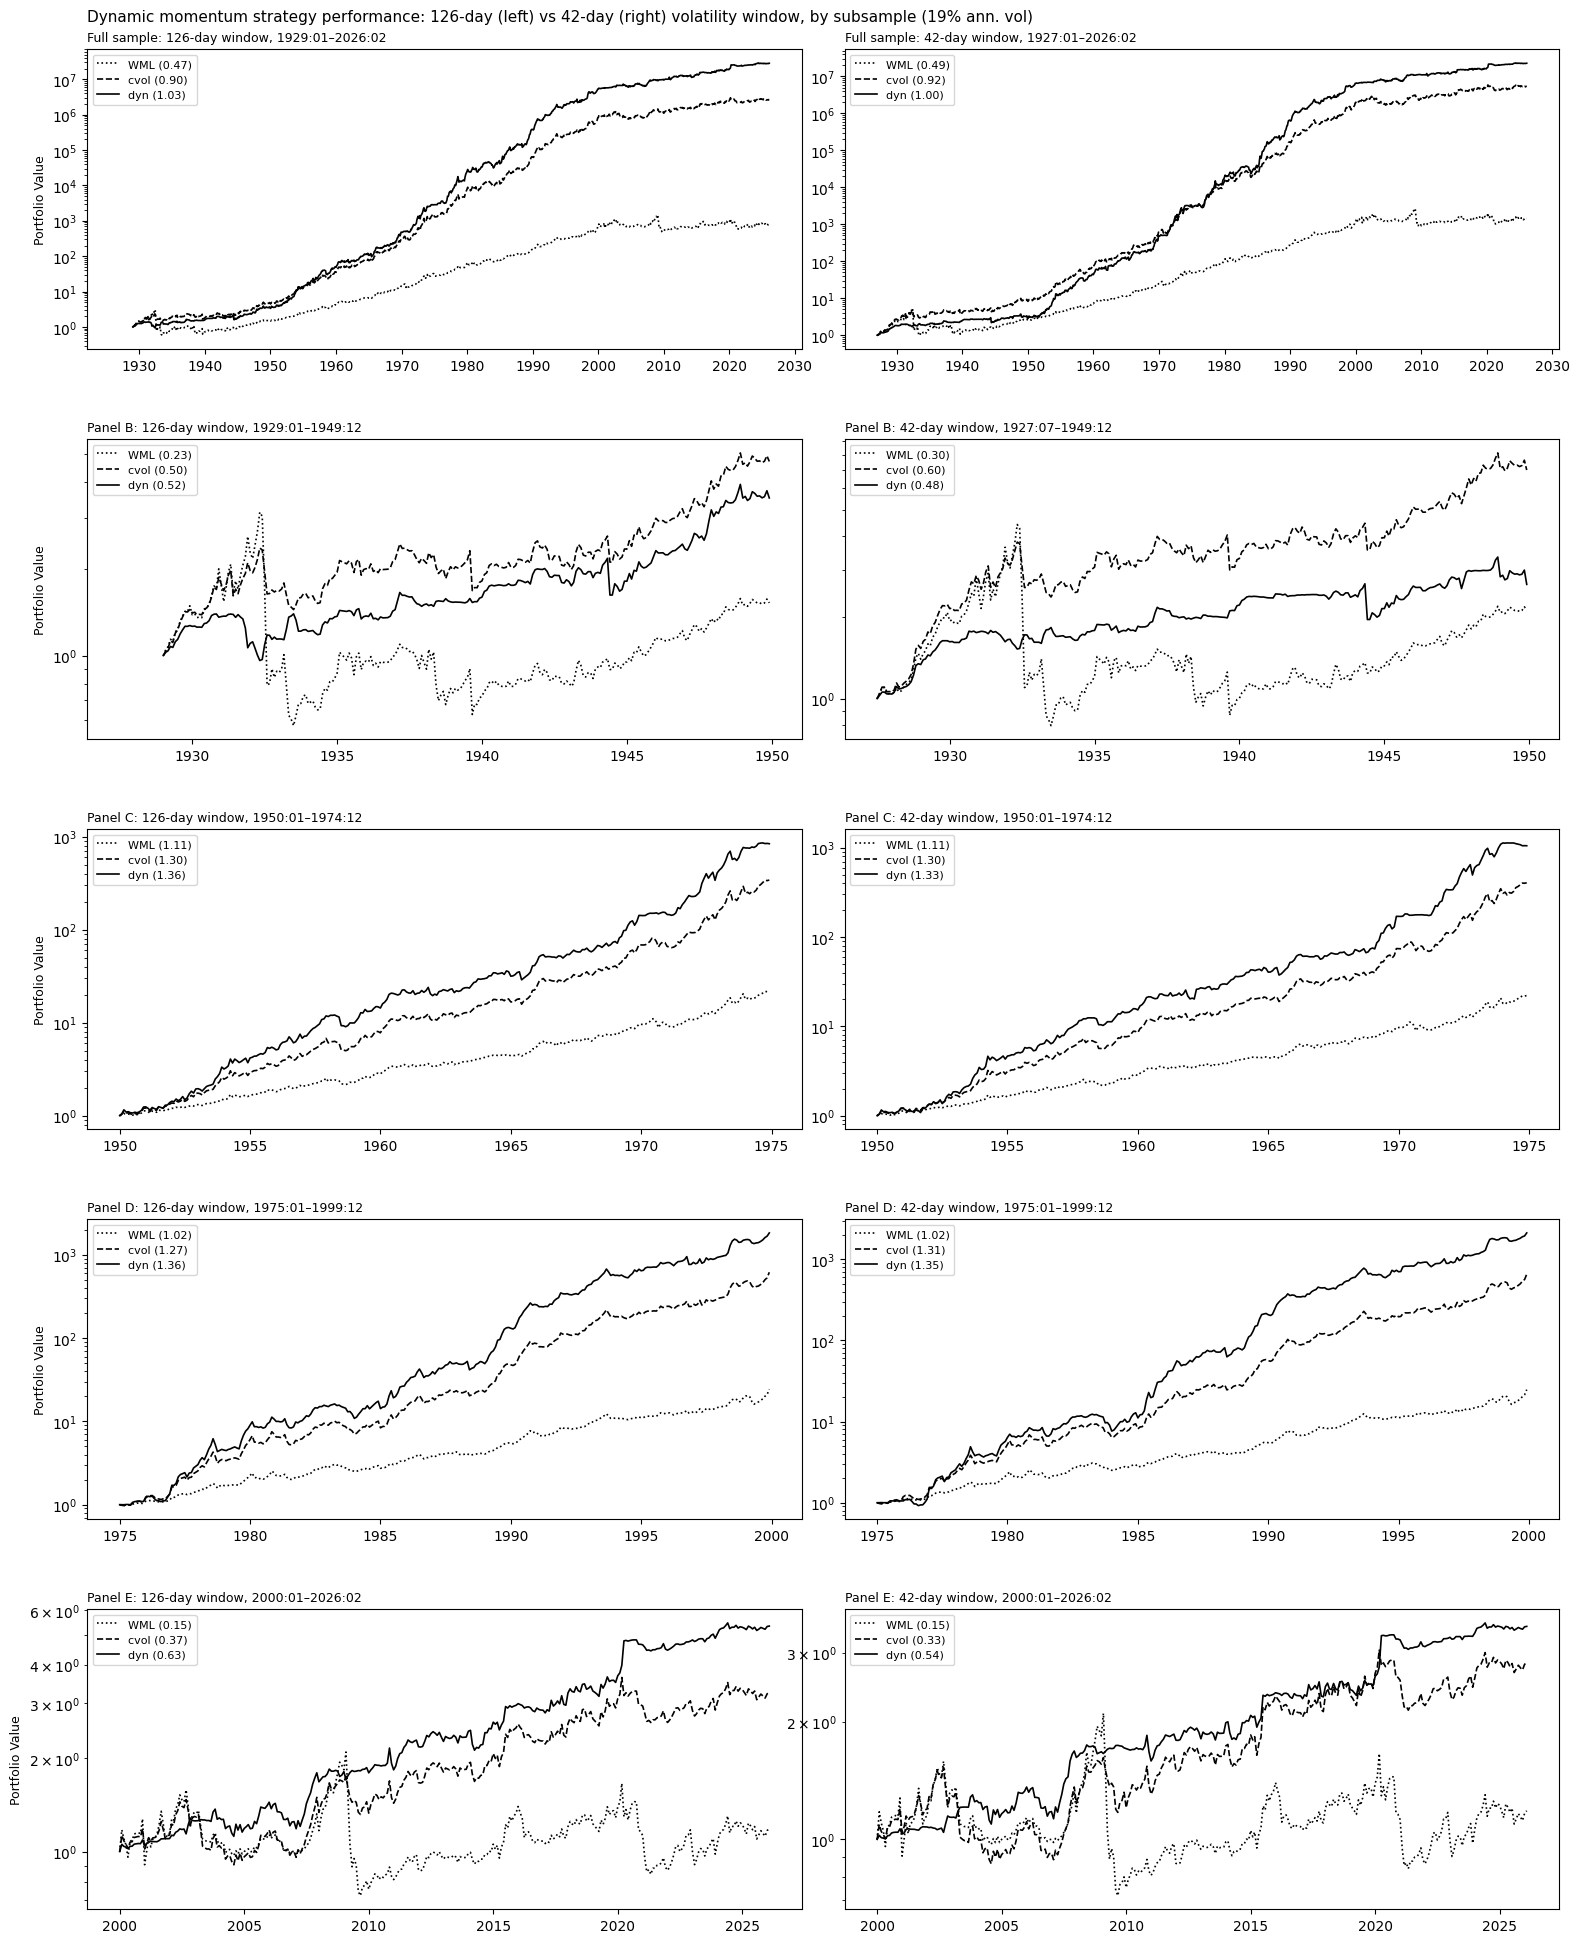

In [16]:
# Figure 4 (X3 & X4 combined): 126-day vs 42-day volatility window, side by side
# Each row is one subsample; left column = 126-day window, right column = 42-day window.
# All strategies scaled to 19% annualized vol; legends show annualized Sharpe per subsample.

# Subsamples: full sample first, then the four quarter-century-style periods.
subperiods_cmp = [
    (None,      None,      'Full sample'),
    ('1927-07', '1949-12', 'Panel B'),
    ('1950-01', '1974-12', 'Panel C'),
    ('1975-01', '1999-12', 'Panel D'),
    ('2000-01', None,      'Panel E'),
]

n_rows = len(subperiods_cmp)
fig_cmb, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows), sharex='row')

def _mask(dates, start, end):
    m = np.ones(len(dates), dtype=bool)
    if start is not None:
        m &= dates >= start
    if end is not None:
        m &= dates <= end
    return m

for row, (start, end, label) in enumerate(subperiods_cmp):
    ax_l, ax_r = axes[row]

    # Left: 126-day window
    m126 = _mask(dates_valid_f6, start, end)
    i0 = np.where(m126)[0][0]
    ax_l.semilogy(dates_valid_f6[m126], cum_wml_s[m126]  / cum_wml_s[i0],  'k:',  lw=1.2, label=f'WML ({sharpe_ann(r_wml_scaled[m126]):.2f})')
    ax_l.semilogy(dates_valid_f6[m126], cum_cvol_s[m126] / cum_cvol_s[i0], 'k--', lw=1.2, label=f'cvol ({sharpe_ann(r_cvol_scaled[m126]):.2f})')
    ax_l.semilogy(dates_valid_f6[m126], cum_dyn_s[m126]  / cum_dyn_s[i0],  'k-',  lw=1.2, label=f'dyn ({sharpe_ann(r_dyn_scaled[m126]):.2f})')
    s_lab = dates_valid_f6[m126][0].strftime('%Y:%m')
    e_lab = dates_valid_f6[m126][-1].strftime('%Y:%m')
    ax_l.set_title(f'{label}: 126-day window, {s_lab}\u2013{e_lab}', fontsize=9, loc='left')
    ax_l.set_ylabel('Portfolio Value', fontsize=9)
    ax_l.legend(loc='upper left', fontsize=8)
    ax_l.xaxis.set_major_locator(mdates.YearLocator(10 if start is None else 5))
    ax_l.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Right: 42-day window
    m42 = _mask(dates_42d, start, end)
    j0 = np.where(m42)[0][0]
    ax_r.semilogy(dates_42d[m42], cum_wml_42d[m42]  / cum_wml_42d[j0],  'k:',  lw=1.2, label=f'WML ({sharpe_42d(r_wml_42d_s[m42]):.2f})')
    ax_r.semilogy(dates_42d[m42], cum_cvol_42d[m42] / cum_cvol_42d[j0], 'k--', lw=1.2, label=f'cvol ({sharpe_42d(r_cvol_42d_s[m42]):.2f})')
    ax_r.semilogy(dates_42d[m42], cum_dyn_42d[m42]  / cum_dyn_42d[j0],  'k-',  lw=1.2, label=f'dyn ({sharpe_42d(r_dyn_42d_s[m42]):.2f})')
    s_lab2 = dates_42d[m42][0].strftime('%Y:%m')
    e_lab2 = dates_42d[m42][-1].strftime('%Y:%m')
    ax_r.set_title(f'{label}: 42-day window, {s_lab2}\u2013{e_lab2}', fontsize=9, loc='left')
    ax_r.legend(loc='upper left', fontsize=8)
    ax_r.xaxis.set_major_locator(mdates.YearLocator(10 if start is None else 5))
    ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig_cmb.suptitle('Dynamic momentum strategy performance: 126-day (left) vs 42-day (right) volatility window, by subsample (19% ann. vol)',
                 fontsize=11, x=0.06, ha='left')
fig_cmb.subplots_adjust(left=0.06, right=0.98, top=0.96, bottom=0.03, hspace=0.3, wspace=0.06)
save_fig(fig_cmb, 'fig_04_combined_126d_vs_42d')
plt.show()


### Table C1: Statistical tests: 42-day vs 126-day window

We formally test whether switching from a 126-day to a 42-day volatility window produces a **statistically distinguishable** strategy.

**Test 1 — Spanning regression** (Newey-West, 6 lags):
$$r^{42d}_t = \alpha + \beta_1 r^{126d}_t + \beta_2 R^e_{m,t} + \beta_3 (I_B \cdot R^e_{m,t}) + \epsilon_t$$
If $\hat{\alpha} \approx 0$ with insignificant $t$-stat, the 126-day version already spans the 42-day return — meaning there is no incremental performance.

**Test 2 — Jobson-Korkie / Memmel test** for Sharpe ratio equality between correlated series:
$$z = \frac{\hat{SR}_1 - \hat{SR}_2}{\sqrt{\theta/T}}, \quad \theta = 2(1-\rho) + \tfrac{1}{2}(SR_1^2 + SR_2^2 - 2 SR_1 SR_2 \rho^2)$$
with $T$ = number of monthly observations and $\rho$ = correlation between the two return series. Under $H_0: SR_1 = SR_2$, $z \sim N(0,1)$.

If $|z|$ is small (p > 0.10), we **cannot reject** equal Sharpe ratios — the two windows are statistically indistinguishable.


In [17]:
# Statistical tests: 42-day vs 126-day window

# Align the two return series on common dates
s_cvol_126 = pd.Series(r_cvol_scaled, index=dates_valid_f6)
s_cvol_42  = pd.Series(r_cvol_42d_s,  index=dates_42d)
s_dyn_126  = pd.Series(r_dyn_scaled,  index=dates_valid_f6)
s_dyn_42   = pd.Series(r_dyn_42d_s,   index=dates_42d)

common = s_cvol_126.index.intersection(s_cvol_42.index)

cvol_126 = s_cvol_126.reindex(common).values
cvol_42  = s_cvol_42.reindex(common).values
dyn_126  = s_dyn_126.reindex(common).values
dyn_42   = s_dyn_42.reindex(common).values

# Market controls
mkt_series = data_m['Mkt-RF'].reindex(common).values
IB_series = pd.Series(I_B_f5, index=dates_f5).reindex(common).values
IB_Rm_series = IB_series * mkt_series

# Newey-West OLS
def nw_ols_test(y, X, lags=6):
    y = np.asarray(y, dtype=float); X = np.asarray(X, dtype=float)
    mask = ~(np.isnan(y) | np.any(np.isnan(X), axis=1))
    y, X = y[mask], X[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    Xe = Xd * e.reshape(-1, 1)
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag/(lags+1)) * (G + G.T)
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    return b, b / np.sqrt(np.diag(V))

# Test 1: Spanning regressions
print('Test 1 \u2014 Spanning regression: 42d on 126d + market controls')
print('Dependent variable: 42-day strategy monthly return')
print('Regressors: 126d strategy, R^e_m, I_B*R^e_m')
print('alpha is annualized (\u00d712\u00d7100). t-stats use Newey-West (6 lags).\n')

span_rows = []
for label, dep, bench in [('cvol (42d)', cvol_42, cvol_126),
                            ('dyn (42d)',  dyn_42,  dyn_126)]:
    X_span = np.column_stack([bench, mkt_series, IB_Rm_series])
    b, t = nw_ols_test(dep, X_span)
    span_rows.append({
        'Dep. var': label,
        'alpha (ann. %)': f'{b[0]*1200:.2f}',
        't(alpha)': f'({t[0]:.2f})',
        'beta_126d': f'{b[1]:.3f}',
        't(beta_126d)': f'({t[1]:.1f})',
        'beta_Rm': f'{b[2]:.3f}',
        'beta_IB*Rm': f'{b[3]:.3f}',
    })
_span_df = pd.DataFrame(span_rows).set_index("Dep. var")
save_table(_span_df, "table_C1_panel_a_spanning")
display(_span_df)

# Test 2: Jobson-Korkie / Memmel Sharpe ratio equality test
def jk_memmel(r1, r2):
    """
    Test H0: SR1 = SR2 for two correlated return series.
    Returns: SR1, SR2, z-stat, p-value (two-sided).
    """
    mask = ~(np.isnan(r1) | np.isnan(r2))
    r1, r2 = r1[mask], r2[mask]
    T = len(r1)
    mu1, mu2 = r1.mean(), r2.mean()
    s1, s2 = r1.std(ddof=1), r2.std(ddof=1)
    sr1, sr2 = mu1/s1, mu2/s2  # monthly Sharpe (not annualized)
    rho = np.corrcoef(r1, r2)[0, 1]
    # Memmel (2003) variance of SR difference
    theta = (2 * (1 - rho)
             + 0.5 * (sr1**2 + sr2**2 - 2 * sr1 * sr2 * rho**2))
    z = (sr1 - sr2) / np.sqrt(theta / T)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    # Annualize Sharpes for display
    return sr1*np.sqrt(12), sr2*np.sqrt(12), rho, z, p

print('\nTest 2 \u2014 Jobson-Korkie / Memmel test for Sharpe ratio equality')
print('H0: Sharpe(126d) = Sharpe(42d). Sharpes shown are annualized.\n')

jk_rows = []
for label, r126, r42 in [('cvol', cvol_126, cvol_42),
                           ('dyn',  dyn_126,  dyn_42)]:
    sr126, sr42, rho, z, p = jk_memmel(r126, r42)
    jk_rows.append({
        'Strategy': label,
        'SR (126d)': f'{sr126:.3f}',
        'SR (42d)':  f'{sr42:.3f}',
        'Diff':      f'{sr42 - sr126:+.3f}',
        'Corr':      f'{rho:.3f}',
        'z-stat':    f'{z:.2f}',
        'p-value':   f'{p:.3f}',
        'Reject H0 (5%)': 'Yes' if p < 0.05 else 'No',
    })
_jk_df = pd.DataFrame(jk_rows).set_index("Strategy")
save_table(_jk_df, "table_C1_panel_b_jobson_korkie")
display(_jk_df)


Test 1 — Spanning regression: 42d on 126d + market controls
Dependent variable: 42-day strategy monthly return
Regressors: 126d strategy, R^e_m, I_B*R^e_m
alpha is annualized (×12×100). t-stats use Newey-West (6 lags).

[save_table PNG warning] table_C1_panel_a_spanning: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,alpha (ann. %),t(alpha),beta_126d,t(beta_126d),beta_Rm,beta_IB*Rm
Dep. var,,,,,,
cvol (42d),0.55,(1.35),0.980,(100.2),-0.017,0.011
dyn (42d),0.79,(1.05),0.934,(37.0),-0.018,-0.009



Test 2 — Jobson-Korkie / Memmel test for Sharpe ratio equality
H0: Sharpe(126d) = Sharpe(42d). Sharpes shown are annualized.

[save_table PNG warning] table_C1_panel_b_jobson_korkie: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,SR (126d),SR (42d),Diff,Corr,z-stat,p-value,Reject H0 (5%)
Strategy,,,,,,,
cvol,0.900,0.901,+0.001,0.977,-0.05,0.959,No
dyn,1.028,0.986,-0.042,0.925,1.04,0.301,No


## Table 08 – Momentum and the Economic Gains from Scaling

Replication of Barroso & Santa-Clara (2015), Table 3, extended with the Daniel & Moskowitz dynamic strategy.

The table compares the economic performance of:
- **WML**: static winner-minus-loser momentum portfolio
- **WML\*** (cvol): risk-managed momentum using trailing 126-day realized variance to scale exposure (Barroso & Santa-Clara)
- **WML\*\*** (dyn): dynamic momentum using conditional mean/variance forecasts (Daniel & Moskowitz)

**Panel A** reports raw (unscaled) strategy returns. The information ratio is computed on unit-std returns (target-independent).

**Panel B** scales all strategies to the same annualized volatility as static WML for direct risk-adjusted comparison.

Statistics are **annualized** (mean, std, Sharpe); min/max are monthly.


In [18]:
# Table 08: Momentum and economic gains from scaling (B&SC Table 3 + dyn)

# 1. Ensure Baseline Data Exists 
# Pull WML from the mask generated in Figure 5
wml_exp = wml_f5[mask_f5]
dates_exp = dates_f5[mask_f5]
mask_t7 = dates_exp >= '1934-01'

# Reconstruct cvol weights (strictly lagged) if not in memory
sigma_wml_exp = sigma_wml_monthly[mask_f5]
sigma_wml_lag = np.roll(sigma_wml_exp, 1)
sigma_wml_lag[0] = np.nan 
w_cvol_t7 = np.nanmean(sigma_wml_lag) / sigma_wml_lag

# Reconstruct OOS dyn weights if not in memory
var_wml_lag = sigma_wml_lag ** 2
IB_exp  = I_B_f5[mask_f5]
sig2_exp = sigma2_mkt_f5[mask_f5]

mu_hat_oos = np.full(len(wml_exp), np.nan)
for t in range(15, len(wml_exp)):  
    sig2_history = sig2_exp[:t]
    IB_history = IB_exp[:t]
    bear_vars = sig2_history[IB_history == 1.0]
    v_bar_B_t = bear_vars.mean() if len(bear_vars) > 0 else 1.0
    IBsig2_hist_norm = IB_history * (sig2_history / v_bar_B_t)
    
    y_t = wml_exp[:t]
    valid = ~(np.isnan(y_t) | np.isnan(IBsig2_hist_norm))
    if valid.sum() < 12:
        continue
        
    X_t = np.column_stack([np.ones(valid.sum()), IBsig2_hist_norm[valid]])
    b_t = np.linalg.lstsq(X_t, y_t[valid], rcond=None)[0]
    
    IBsig2_lag_norm = IB_exp[t-1] * (sig2_exp[t-1] / v_bar_B_t)
    mu_hat_oos[t] = b_t[0] + b_t[1] * IBsig2_lag_norm

w_dyn_oos = mu_hat_oos / var_wml_lag

# 2. Fetch Strictly Out-of-Sample Managed Returns
r_wml_raw = wml_exp.copy()
r_cvol_raw = w_cvol_t7 * wml_exp
r_dyn_raw = w_dyn_oos * wml_exp

# 3. Compute Statistics Helper Functions
def compute_stats_tab(r_monthly, label):
    r = r_monthly[~np.isnan(r_monthly)]
    return {
        'Portfolio': label,
        'Maximum':   r.max() * 100,
        'Minimum':   r.min() * 100,
        'Mean':      r.mean() * 12 * 100,
        'Std (ann.)':r.std() * np.sqrt(12) * 100,
        'Kurtosis':  pd.Series(r).kurtosis(),
        'Skewness':  pd.Series(r).skew(),
        'Sharpe':    (r.mean() / r.std()) * np.sqrt(12),
    }

# Information Ratio / Appraisal Ratio (on unit-std returns)
def info_ratio_tab(r_managed, r_benchmark):
    rm = r_managed / np.nanstd(r_managed)
    rb = r_benchmark / np.nanstd(r_benchmark)
    mask_ir = ~(np.isnan(rm) | np.isnan(rb))
    y = rm[mask_ir]; x = rb[mask_ir]
    
    if len(y) < 10:
        return np.nan
        
    X_ir = np.column_stack([np.ones(len(x)), x])
    b_ir = np.linalg.lstsq(X_ir, y, rcond=None)[0]
    eps_ir = y - X_ir @ b_ir
    return (b_ir[0] * 12) / (eps_ir.std() * np.sqrt(12))

# 4. Compile Data (Restricting to mask_t7 Post-1934 Warmup)
r_wml_raw = r_wml_raw[mask_t7]
r_cvol_raw = r_cvol_raw[mask_t7]
r_dyn_raw = r_dyn_raw[mask_t7]

# PANEL A: Raw (unscaled) returns
stats_a = [
    compute_stats_tab(r_wml_raw,  'WML'),
    compute_stats_tab(r_cvol_raw, 'WML* (cvol)'),
    compute_stats_tab(r_dyn_raw,  'WML** (dyn, OOS)'),
]
stats_a[0]['IR'] = np.nan
stats_a[1]['IR'] = info_ratio_tab(r_cvol_raw, r_wml_raw)
stats_a[2]['IR'] = info_ratio_tab(r_dyn_raw, r_wml_raw)

tab_a = pd.DataFrame(stats_a).set_index('Portfolio')
tab_a.columns = ['Maximum', 'Minimum', 'Mean', 'Std (ann.)',
                  'Kurtosis', 'Skewness', 'Sharpe', 'IR']

dates_final = dates_exp[mask_t7]
start_yr = dates_final[0].strftime('%Y:%m')
end_yr   = dates_final[-1].strftime('%Y:%m')

print(f'Panel A: Raw returns, {start_yr}–{end_yr}')
print('Mean, Std annualized (%). Min/Max monthly (%).\n')
save_table(tab_a, "table_08_panel_A_raw")
display(tab_a.style.format({
    'Maximum': '{:.2f}', 'Minimum': '{:.2f}', 'Mean': '{:.2f}',
    'Std (ann.)': '{:.2f}', 'Kurtosis': '{:.2f}', 'Skewness': '{:.2f}',
    'Sharpe': '{:.2f}', 'IR': '{:.2f}',
}, na_rep='–'))

# PANEL B: All scaled to same annualized vol as static WML
target_std = np.std(r_wml_raw)
r_wml_sc  = r_wml_raw
r_cvol_sc = r_cvol_raw * (target_std / np.nanstd(r_cvol_raw))
r_dyn_sc  = r_dyn_raw  * (target_std / np.nanstd(r_dyn_raw))

stats_b = [
    compute_stats_tab(r_wml_sc,  'WML'),
    compute_stats_tab(r_cvol_sc, 'WML* (cvol)'),
    compute_stats_tab(r_dyn_sc,  'WML** (dyn, OOS)'),
]
for s in stats_b:
    s['IR'] = np.nan

tab_b = pd.DataFrame(stats_b).set_index('Portfolio')
tab_b.columns = ['Maximum', 'Minimum', 'Mean', 'Std (ann.)',
                  'Kurtosis', 'Skewness', 'Sharpe', 'IR']

print(f'\nPanel B: All scaled to WML annualized vol ({target_std*np.sqrt(12)*100:.1f}%), {start_yr}–{end_yr}\n')
save_table(tab_b, "table_08_panel_B_volmatched")
display(tab_b.style.format({
    'Maximum': '{:.2f}', 'Minimum': '{:.2f}', 'Mean': '{:.2f}',
    'Std (ann.)': '{:.2f}', 'Kurtosis': '{:.2f}', 'Skewness': '{:.2f}',
    'Sharpe': '{:.2f}', 'IR': '{:.2f}',
}, na_rep='–'))

Panel A: Raw returns, 1934:01–2026:02
Mean, Std annualized (%). Min/Max monthly (%).

[save_table PNG warning] table_08_panel_A_raw: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,Maximum,Minimum,Mean,Std (ann.),Kurtosis,Skewness,Sharpe,IR
Portfolio,,,,,,,,
WML,26.24,-45.32,13.16,24.07,7.39,-1.33,0.55,–
WML* (cvol),33.36,-42.13,24.43,26.86,2.54,-0.34,0.91,0.84
"WML** (dyn, OOS)",651.08,-664.75,303.53,314.00,9.24,0.35,0.97,0.80



Panel B: All scaled to WML annualized vol (24.1%), 1934:01–2026:02

[save_table PNG warning] table_08_panel_B_volmatched: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,Maximum,Minimum,Mean,Std (ann.),Kurtosis,Skewness,Sharpe,IR
Portfolio,,,,,,,,
WML,26.24,-45.32,13.16,24.07,7.39,-1.33,0.55,–
WML* (cvol),29.89,-37.75,21.89,24.07,2.54,-0.34,0.91,–
"WML** (dyn, OOS)",49.90,-50.95,23.26,24.07,9.24,0.35,0.97,–


Weight (leverage) statistics (Post-1934 Out-of-Sample):
                         Mean      Std      Min      Max   Median    |w|>2    |w|>3
WML (static)             1.00     0.00     1.00     1.00     1.00     0.0%     0.0%
cvol (B&SC)              1.41     0.67     0.21     3.70     1.34    19.3%     1.7%
dyn (D&M, OOS)          15.27    13.99   -10.01    80.17    11.33    89.1%    83.2%


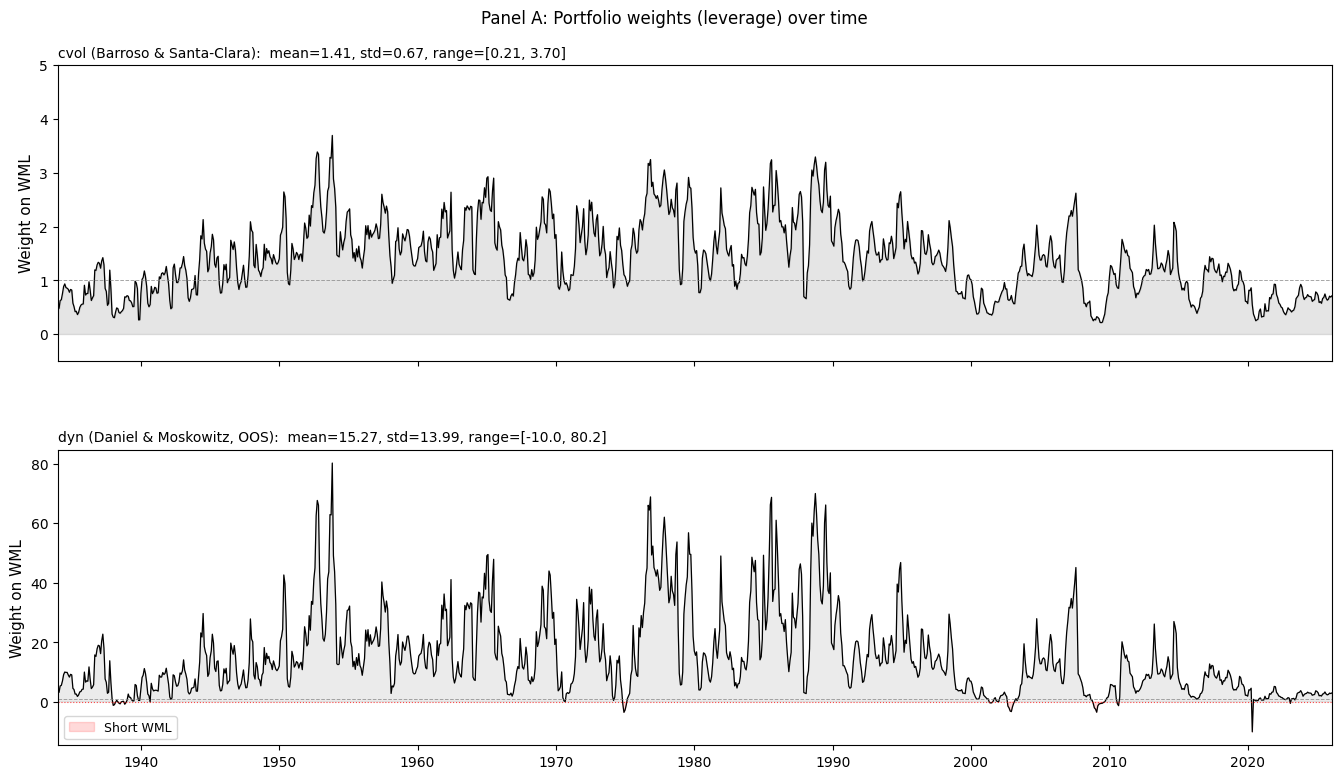

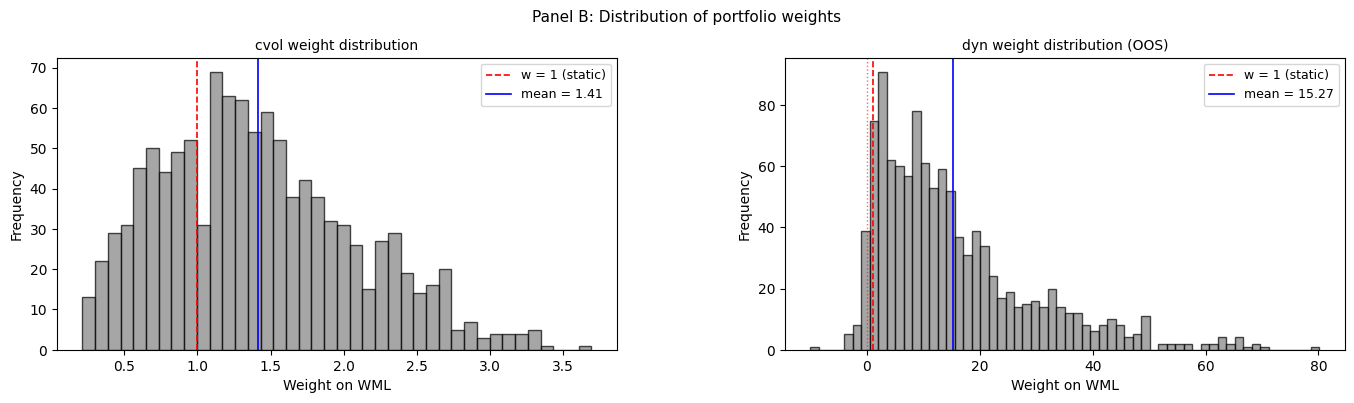

In [19]:
# Figure B1 and B2
# Leverage diagnostics: weight distributions for each strategy

# 1. Pull the strictly OOS weights and dates from Table 7
dates_t7 = dates_exp[mask_t7]
w_wml_t7 = np.ones(len(dates_t7))  
w_cvol_t7_clean = w_cvol_t7[mask_t7]
w_dyn_t7_clean = w_dyn_oos[mask_t7]

# 2. Summary statistics
print('Weight (leverage) statistics (Post-1934 Out-of-Sample):')
print(f'{"":20} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8} {"Median":>8} {"|w|>2":>8} {"|w|>3":>8}')
for label, w in [('WML (static)', w_wml_t7), ('cvol (B&SC)', w_cvol_t7_clean), ('dyn (D&M, OOS)', w_dyn_t7_clean)]:
    # Safe mask for NaNs (though mask_t7 should have cleared them)
    w_clean = w[~np.isnan(w)]
    pct_gt2 = (np.abs(w_clean) > 2).mean() * 100
    pct_gt3 = (np.abs(w_clean) > 3).mean() * 100
    print(f'{label:20} {w_clean.mean():8.2f} {w_clean.std():8.2f} {w_clean.min():8.2f} {w_clean.max():8.2f} {np.median(w_clean):8.2f} {pct_gt2:7.1f}% {pct_gt3:7.1f}%')

# Plot 1: Weight time series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: cvol weights
ax1.plot(dates_t7, w_cvol_t7_clean, 'k-', lw=0.9)
ax1.axhline(1, color='gray', ls='--', lw=0.7, alpha=0.7)
ax1.fill_between(dates_t7, 0, w_cvol_t7_clean, alpha=0.1, color='black')
ax1.set_ylabel('Weight on WML', fontsize=11)
ax1.set_title(
    f'cvol (Barroso & Santa-Clara):  '
    f'mean={np.nanmean(w_cvol_t7_clean):.2f}, std={np.nanstd(w_cvol_t7_clean):.2f}, '
    f'range=[{np.nanmin(w_cvol_t7_clean):.2f}, {np.nanmax(w_cvol_t7_clean):.2f}]',
    fontsize=10, loc='left'
)
ax1.set_ylim(-0.5, 5)

# Panel 2: dyn weights
ax2.plot(dates_t7, w_dyn_t7_clean, 'k-', lw=0.9)
ax2.axhline(1, color='gray', ls='--', lw=0.7, alpha=0.7)
ax2.axhline(0, color='red', ls=':', lw=0.8, alpha=0.7)

# Safe boolean masks for fill_between
is_negative = w_dyn_t7_clean < 0
is_positive = w_dyn_t7_clean >= 0

ax2.fill_between(dates_t7, 0, w_dyn_t7_clean,
                 where=is_negative, alpha=0.15, color='red', label='Short WML')
ax2.fill_between(dates_t7, 0, w_dyn_t7_clean,
                 where=is_positive, alpha=0.08, color='black')
ax2.set_ylabel('Weight on WML', fontsize=11)
ax2.set_title(
    f'dyn (Daniel & Moskowitz, OOS):  '
    f'mean={np.nanmean(w_dyn_t7_clean):.2f}, std={np.nanstd(w_dyn_t7_clean):.2f}, '
    f'range=[{np.nanmin(w_dyn_t7_clean):.1f}, {np.nanmax(w_dyn_t7_clean):.1f}]',
    fontsize=10, loc='left'
)
ax2.legend(loc='lower left', fontsize=9)

ax2.xaxis.set_major_locator(mdates.YearLocator(10))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_xlim(dates_t7[0], dates_t7[-1])

fig.suptitle('Panel A: Portfolio weights (leverage) over time', fontsize=12, y=0.98)
fig.subplots_adjust(hspace=0.3, left=0.06, right=0.97, top=0.91, bottom=0.06)
save_fig(fig, 'fig_B1_leverage_panel_a')
plt.show()

# Plot 2: Distribution of weights (Histograms)
fig2, (ax_h1, ax_h2) = plt.subplots(1, 2, figsize=(14, 4))

# cvol histogram
w_cv_clean = w_cvol_t7_clean[~np.isnan(w_cvol_t7_clean)]
ax_h1.hist(w_cv_clean, bins=40, color='gray', edgecolor='black', alpha=0.7)
ax_h1.axvline(1, color='red', ls='--', lw=1.2, label='w = 1 (static)')
ax_h1.axvline(np.nanmean(w_cv_clean), color='blue', ls='-', lw=1.2, label=f'mean = {np.nanmean(w_cv_clean):.2f}')
ax_h1.set_xlabel('Weight on WML', fontsize=10)
ax_h1.set_ylabel('Frequency', fontsize=10)
ax_h1.set_title('cvol weight distribution', fontsize=10)
ax_h1.legend(fontsize=9)

# dyn histogram
w_dyn_clean = w_dyn_t7_clean[~np.isnan(w_dyn_t7_clean)]
ax_h2.hist(w_dyn_clean, bins=60, color='gray', edgecolor='black', alpha=0.7)
ax_h2.axvline(1, color='red', ls='--', lw=1.2, label='w = 1 (static)')
ax_h2.axvline(0, color='red', ls=':', lw=1, alpha=0.6)
ax_h2.axvline(np.nanmean(w_dyn_clean), color='blue', ls='-', lw=1.2, label=f'mean = {np.nanmean(w_dyn_clean):.2f}')
ax_h2.set_xlabel('Weight on WML', fontsize=10)
ax_h2.set_ylabel('Frequency', fontsize=10)
ax_h2.set_title('dyn weight distribution (OOS)', fontsize=10)
ax_h2.legend(fontsize=9)

fig2.suptitle('Panel B: Distribution of portfolio weights', fontsize=11, y=1.0)
fig2.subplots_adjust(wspace=0.3, left=0.05, right=0.97, top=0.88, bottom=0.15)
save_fig(fig2, 'fig_B1_leverage_panel_b')
plt.show()

## Figure B2 – Mean Forecast Coefficients: Expanding Window

Replication of Daniel & Moskowitz (2016), Figure 7. The conditional mean forecast uses Table 5, column 4 (spec 4):

$$\hat{\mu}_{t-1} = \mathbb{E}_{t-1}[\tilde{R}_{\text{WML},t}] = \hat{\gamma}_{0,t-1} + \hat{\gamma}_{\text{int},t-1} \cdot I_{B,t-1} \cdot \hat{\sigma}^2_{m,t-1}$$

The coefficients $\hat{\gamma}_{0,t-1}$ and $\hat{\gamma}_{\text{int},t-1}$ are estimated using an **expanding window** — i.e., OLS from the start of the sample (1927:07) up through month $t-1$.

The plot shows:
- **Solid line**: $\hat{\gamma}_{\text{int},t-1}$ (interaction coefficient)
- **Dashed line**: $\hat{\gamma}_{0,t-1} \times 10$ (intercept, scaled by 10 for visibility)


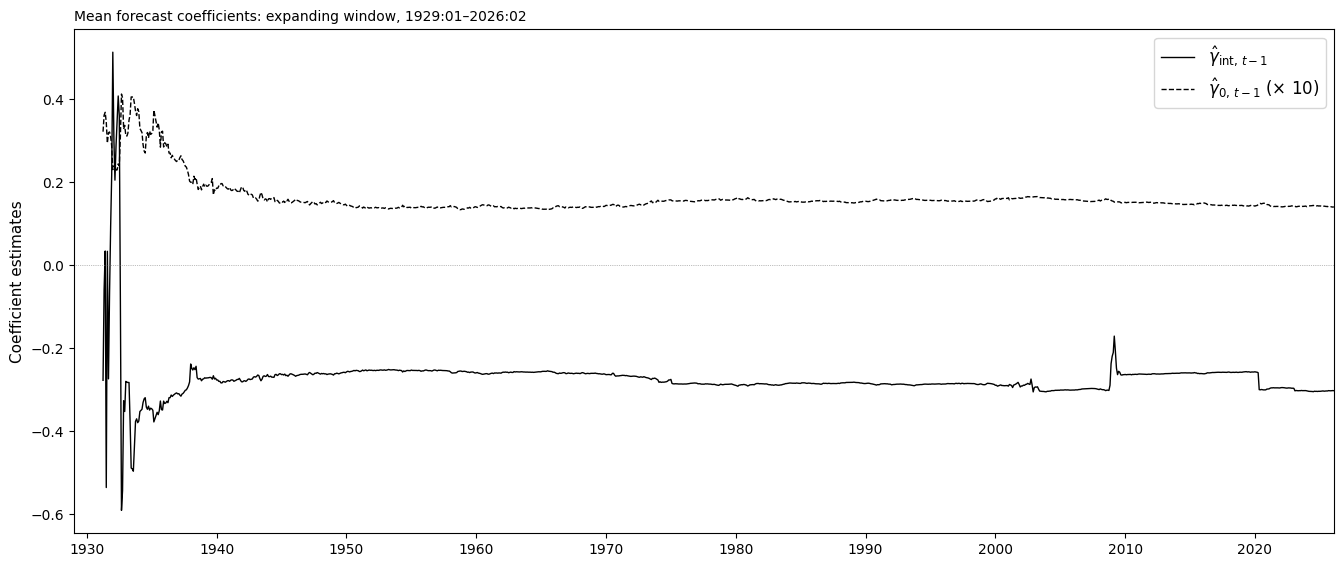

In [20]:
# Figure B2: Expanding-window forecast coefficients (Table 5, spec 4)
# Spec 4: WML_t = gamma_0 + gamma_int * (I_B,t-1 * sigma2_m,t-1) + eps_t
# Re-estimate using data from start up to t-1 for each month t

# Variables already computed: wml_f5, I_B_f5, sigma2_mkt_f5, mask_f5, dates_f5
# Get aligned arrays
wml_exp = wml_f5[mask_f5]
IB_exp  = I_B_f5[mask_f5]
sig2_exp = sigma2_mkt_f5[mask_f5]
IBsig2_exp = IB_exp * sig2_exp
dates_exp = dates_f5[mask_f5]
n_exp = len(wml_exp)

# Expanding window OLS: for each t, use observations 0..t-1
# Require at least 24 months and 6 nonzero I_B observations for stable estimates
min_window = 24
min_bear_obs = 6
gamma0_expanding = np.full(n_exp, np.nan)
gamma_int_expanding = np.full(n_exp, np.nan)

for t in range(min_window, n_exp):
    y_t = wml_exp[:t]
    X_t = np.column_stack([np.ones(t), IBsig2_exp[:t]])
    
    # lstsq gracefully handles the all-zero interaction column before Oct 1930
    # Skip if too few bear observations - estimate is unreliable
    if (IBsig2_exp[:t] != 0).sum() < min_bear_obs:
        continue
    
    b_t = np.linalg.lstsq(X_t, y_t, rcond=None)[0]
    
    gamma0_expanding[t] = b_t[0]
    gamma_int_expanding[t] = b_t[1]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_exp, gamma_int_expanding, 'k-', lw=1.0,
        label=r'$\hat{\gamma}_{\mathrm{int},\, t-1}$')
ax.plot(dates_exp, gamma0_expanding * 10, 'k--', lw=1.0,
        label=r'$\hat{\gamma}_{0,\, t-1}$ ($\times$ 10)')

ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_ylabel('Coefficient estimates', fontsize=11)
ax.legend(loc='upper right', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(dates_exp[0], dates_exp[-1])

ax.set_title(
    f'Mean forecast coefficients: expanding window, '
    f'{dates_exp[0].strftime("%Y:%m")}\u2013{dates_exp[-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)

fig.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.08)
save_fig(fig, 'fig_B2_expanding_coeffs')
plt.show()


## Table 09 – Strategy Performance Comparison

Replication of Daniel & Moskowitz (2016), Table 7. Annualized Sharpe ratios and Treynor-Black appraisal ratios for five momentum strategies:

| Strategy | Description |
|----------|-------------|
| **WML** | Static winner-minus-loser |
| **cvol** | Constant volatility: $w_t = \sigma_{\text{target}} / \hat{\sigma}_{t-1}$ using 126-day realized vol of WML |
| **variance scaled** | $w_t = \sigma^2_{\text{target}} / \hat{\sigma}^2_{t-1}$ — scaled by realized *variance* (not vol) of daily WML over 126 days |
| **dyn, out-of-sample** | $w_t = \hat{\mu}_{t-1} / \hat{\sigma}^2_{t-1}$ where $\hat{\mu}_{t-1}$ uses expanding-window regression coefficients and $\hat{\sigma}^2_{t-1}$ is 126-day realized WML variance |
| **dyn, in-sample** | Same as dyn but with full-sample (in-sample) regression + GARCH variance |

The **Appraisal ratio** (Treynor & Black, 1973) is the annualized alpha divided by the annualized residual std from regressing each strategy on the one in the preceding row.

Sample starts 1934:01 (requires expanding window warm-up from 1927:07).


In [21]:
# Table 09: Strategy performance comparison
# Five strategies: WML, cvol, variance-scaled, dyn out-of-sample, dyn in-sample

wml_exp = wml_f5[mask_f5]
dates_exp = dates_f5[mask_f5]
n_exp = len(wml_exp)

# Volatility and Variance Arrays
# Because we aligned Figure 5 to calculate variance ending on the 1st of the month,
# sigma_wml_monthly[t] is already the t-1 information.
sigma_wml_exp = sigma_wml_monthly[mask_f5]
var_wml_exp = sigma_wml_exp ** 2

# 2. cvol: w_t = sigma_target / sigma_hat_{t-1}
sigma_target_t7 = np.nanmean(sigma_wml_exp)
w_cvol_t7 = sigma_target_t7 / sigma_wml_exp
r_cvol_t7 = w_cvol_t7 * wml_exp

# 3. Variance scaled: w_t = var_target / var_hat_{t-1}
var_target_t7 = np.nanmean(var_wml_exp)
w_varscale_t7 = var_target_t7 / var_wml_exp
r_varscale_t7 = w_varscale_t7 * wml_exp

# Normalize the interaction term 
IB_exp  = I_B_f5[mask_f5]
sig2_exp = sigma2_mkt_f5[mask_f5]
v_bar_B = sig2_exp[IB_exp == 1.0].mean()

# This is the interaction term known at the start of month t
IBsig2_exp_norm = IB_exp * (sig2_exp / v_bar_B)

# 4. Dyn, out-of-sample
mu_hat_oos = np.full(n_exp, np.nan)

# Expanding window 
for t in range(15, n_exp):  
    y_t = wml_exp[:t]
    x_t = IBsig2_exp_norm[:t]
    
    valid = ~(np.isnan(y_t) | np.isnan(x_t))
    if valid.sum() < 12:
        continue
        
    # Fit OLS on strictly historical data (0 to t-1)
    X_t = np.column_stack([np.ones(valid.sum()), x_t[valid]])
    b_t = np.linalg.lstsq(X_t, y_t[valid], rcond=None)[0]
    
    # Forecast for month t using info up to the start of month t
    mu_hat_oos[t] = b_t[0] + b_t[1] * IBsig2_exp_norm[t]

# OOS uses 126-day realized variance available at the start of month t
w_dyn_oos = mu_hat_oos / var_wml_exp
r_dyn_oos = w_dyn_oos * wml_exp

# 5. Dyn, in-sample 
X_is_t7 = np.column_stack([np.ones(n_exp), IBsig2_exp_norm])
b_is_t7 = np.linalg.lstsq(X_is_t7, wml_exp, rcond=None)[0]
mu_hat_is_t7 = X_is_t7 @ b_is_t7

# IS uses the blended GARCH variance calculated in Figure 5
h_f5_blended_exp = h_f5_blended[mask_f5]
w_dyn_is_t7 = mu_hat_is_t7 / h_f5_blended_exp
r_dyn_is = w_dyn_is_t7 * wml_exp

# Format and Display Table
# Restrict to 1934:01+ (warm-up period)
mask_t7 = dates_exp >= '1934-01'

strategies = [
    ('WML',                wml_exp[mask_t7]),
    ('cvol',               r_cvol_t7[mask_t7]),
    ('variance scaled',    r_varscale_t7[mask_t7]),
    ('dyn, out-of-sample', r_dyn_oos[mask_t7]),
    ('dyn, in-sample',     r_dyn_is[mask_t7]),
]

def sharpe_t7(r):
    r = r[~np.isnan(r)]
    return (r.mean() / r.std()) * np.sqrt(12)

def appraisal_ratio(r_strategy, r_benchmark):
    """Alpha / residual std from regressing strategy on benchmark (annualized)."""
    rs = r_strategy / np.nanstd(r_strategy)
    rb = r_benchmark / np.nanstd(r_benchmark)
    mask_ar = ~(np.isnan(rs) | np.isnan(rb))
    y = rs[mask_ar]; x = rb[mask_ar]
    
    if len(y) < 10: 
        return np.nan
        
    X_ar = np.column_stack([np.ones(len(x)), x])
    b_ar = np.linalg.lstsq(X_ar, y, rcond=None)[0]
    eps_ar = y - X_ar @ b_ar
    alpha_ann = b_ar[0] * 12
    eps_std_ann = eps_ar.std() * np.sqrt(12)
    return alpha_ann / eps_std_ann

rows_t7 = []
for i, (name, r) in enumerate(strategies):
    sr = sharpe_t7(r)
    if i == 0:
        ar = np.nan
    else:
        ar = appraisal_ratio(r, strategies[i-1][1])
    rows_t7.append({'Strategy': name, 'Sharpe ratio': sr, 'Appraisal ratio': ar})

tab7 = pd.DataFrame(rows_t7).set_index('Strategy')

start_t7 = dates_exp[mask_t7][0].strftime('%Y:%m')
end_t7   = dates_exp[mask_t7][-1].strftime('%Y:%m')
print(f'Table 10 – Strategy performance comparison, {start_t7}–{end_t7}')
print('Sharpe ratios annualized. Appraisal ratio vs preceding row.\n')

save_table(tab7, "table_09_strategy_performance")
display(tab7.style.format({
    'Sharpe ratio': '{:.3f}',
    'Appraisal ratio': '{:.3f}',
}, na_rep='–'))

Table 10 – Strategy performance comparison, 1934:01–2026:02
Sharpe ratios annualized. Appraisal ratio vs preceding row.

[save_table PNG warning] table_09_strategy_performance: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,Sharpe ratio,Appraisal ratio
Strategy,,
WML,0.547,–
cvol,0.921,0.860
variance scaled,1.000,0.389
"dyn, out-of-sample",1.019,0.196
"dyn, in-sample",1.060,0.300


## Table C2 – Spanning Tests of the Dynamic Momentum Portfolio

Replication of Daniel & Moskowitz (2016), Table 8. Daily time-series regressions testing whether the dynamic (dyn) and constant volatility (cvol) momentum portfolios are spanned by standard factors.

**Panel A**: Dependent variable = daily returns to the **dynamic (dyn)** momentum portfolio  
**Panel B**: Dependent variable = daily returns to the **constant volatility (cvol)** momentum portfolio

Factor sets:
1. Mkt + WML (unconditional)
2. Mkt + WML conditional (interacted with $I_{B\sigma^2}$)
3. FF + WML conditional (Mkt, SMB, HML + WML, all conditional)
4. Mkt + cvol (for Panel A) / Mkt + dyn (for Panel B)
5. Mkt + cvol conditional (for Panel A) / Mkt + dyn conditional (for Panel B)
6. FF + cvol conditional (for Panel A) / FF + dyn conditional (for Panel B)

"Conditional" means each factor is included both unconditionally and interacted with $I_{B\sigma^2}$.

The dyn and cvol portfolios are scaled to have the same annualized vol as static WML (23%).
Intercepts ($\\hat{\\alpha}$) are annualized (×25,200). $t$-statistics use Newey-West (10 lags).


In [22]:
# Table C2: Spanning tests of the dynamic momentum portfolio

# 1. Get monthly aligned data from Figure 5
wml_exp = wml_f5[mask_f5]
IB_exp  = I_B_f5[mask_f5]
sig2_exp = sigma2_mkt_f5[mask_f5]
var_wml_exp = sigma_wml_monthly[mask_f5] ** 2

# To trade in month t, use variance known at end of t-1
sigma_wml_lag = np.roll(sigma_wml_monthly[mask_f5], 1)
sigma_wml_lag[0] = np.nan 
var_wml_lag = sigma_wml_lag ** 2

# 2. cvol weights (w_t = sigma_target / sigma_hat_{t-1})
w_cvol_monthly = np.nanmean(sigma_wml_lag) / sigma_wml_lag

# 3. dyn weights (Strictly Out-of-Sample)
n_exp = len(wml_exp)
mu_oos_t8 = np.full(n_exp, np.nan)

# Expanding window for mu_hat
for t in range(15, n_exp):  
    # 3a. Strictly out-of-sample expanding normalization
    sig2_history = sig2_exp[:t]
    IB_history = IB_exp[:t]
    
    # Mean bear market variance up to t-1
    bear_vars = sig2_history[IB_history == 1.0]
    v_bar_B_t = bear_vars.mean() if len(bear_vars) > 0 else 1.0
    
    # Normalized interaction term history
    IBsig2_hist_norm = IB_history * (sig2_history / v_bar_B_t)
    
    y_t = wml_exp[:t]
    valid = ~(np.isnan(y_t) | np.isnan(IBsig2_hist_norm))
    if valid.sum() < 12:
        continue
        
    X_t = np.column_stack([np.ones(valid.sum()), IBsig2_hist_norm[valid]])
    b_t = np.linalg.lstsq(X_t, y_t[valid], rcond=None)[0]
    
    # 3b. Forecast for month t using interaction term from t-1
    # We must calculate the t-1 normalized interaction term using the t-1 mean
    IBsig2_lag_norm = IB_exp[t-1] * (sig2_exp[t-1] / v_bar_B_t)
    mu_oos_t8[t] = b_t[0] + b_t[1] * IBsig2_lag_norm

w_dyn_monthly = mu_oos_t8 / var_wml_lag

# 4. Map monthly weights to daily
daily_months = data_d.index.to_period('M')
monthly_periods = dates_f5[mask_f5].to_period('M')

weight_cvol_daily = pd.Series(w_cvol_monthly, index=monthly_periods)
weight_dyn_daily = pd.Series(w_dyn_monthly, index=monthly_periods)

wml_d = data_d['WML'].copy()
w_cvol_d = daily_months.map(lambda p: weight_cvol_daily.get(p, np.nan))
w_dyn_d  = daily_months.map(lambda p: weight_dyn_daily.get(p, np.nan))

r_cvol_d = w_cvol_d * wml_d.values
r_dyn_d  = w_dyn_d * wml_d.values

# Scale to same annualized vol as WML
wml_ann_vol = wml_d.std() * np.sqrt(252)
r_cvol_d_scaled = r_cvol_d * (wml_ann_vol / (pd.Series(r_cvol_d).std() * np.sqrt(252)))
r_dyn_d_scaled  = r_dyn_d * (wml_ann_vol / (pd.Series(r_dyn_d).std() * np.sqrt(252)))

# 5. State Variables (Constant throughout the month)
# Map the t-1 monthly state variables directly to the daily dates
IB_lag = np.roll(IB_exp, 1)
IB_lag[0] = np.nan
sig2_lag = np.roll(sig2_exp, 1)
sig2_lag[0] = np.nan

IB_daily = daily_months.map(lambda p: pd.Series(IB_lag, index=monthly_periods).get(p, np.nan)).values
sig2_daily = daily_months.map(lambda p: pd.Series(sig2_lag, index=monthly_periods).get(p, np.nan)).values

# 6. NW OLS Helper
def nw_ols_span(y_arr, X_arr, lags=10):
    mask_s = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = np.asarray(y_arr[mask_s], dtype=float), np.asarray(X_arr[mask_s], dtype=float)
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    Xe = Xd * e[:, None]  
    S = Xe.T @ Xe  
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]  
        S += (1 - lag / (lags + 1)) * (G + G.T)
    XtX_inv = np.linalg.inv(Xd.T @ Xd)
    V = XtX_inv @ S @ XtX_inv
    return b[0], b[0] / np.sqrt(V[0, 0])  

# 7. Build conditional factors (Factor * IB, Factor * sig2)
def make_conditional(factors):
    result = list(factors)
    for f in factors:
        result.append(f * IB_daily)
        result.append(f * sig2_daily)
    return np.column_stack(result)

mkt_arr = data_d['Mkt-RF'].values
smb_arr = data_d['SMB'].values
hml_arr = data_d['HML'].values
wml_arr = wml_d.values

# Run Regressions
print('Table C2 – Spanning tests of the dynamic momentum portfolio\n')

# Panel A
dep_a = r_dyn_d_scaled
specs_a = [
    ('Mkt+WML',             np.column_stack([mkt_arr, wml_arr])),
    ('Mkt+WML conditional', make_conditional([mkt_arr, wml_arr])),
    ('FF+WML conditional',  make_conditional([mkt_arr, smb_arr, hml_arr, wml_arr])),
    ('Mkt+cvol',            np.column_stack([mkt_arr, r_cvol_d_scaled])),
    ('Mkt+cvol conditional',make_conditional([mkt_arr, r_cvol_d_scaled])),
    ('FF+cvol conditional', make_conditional([mkt_arr, smb_arr, hml_arr, r_cvol_d_scaled])),
]

alphas_a = []; tstats_a = []
for label, X in specs_a:
    a, t = nw_ols_span(dep_a, X)
    alphas_a.append(a * 25200)
    tstats_a.append(t)

tab8a = pd.DataFrame({
    'Factor set': [s[0] for s in specs_a],
    r'$\hat{\alpha}$': [f'{a:.2f}' for a in alphas_a],
    r'$t(\alpha)$': [f'({t:.2f})' for t in tstats_a],
}).set_index('Factor set').T

print('Panel A: Dependent variable = returns to dynamic (dyn) momentum portfolio')
save_table(tab8a, "table_C2_panel_A_dyn_dep")
display(tab8a)
print()

# Panel B
dep_b = r_cvol_d_scaled
specs_b = [
    ('Mkt+WML',             np.column_stack([mkt_arr, wml_arr])),
    ('Mkt+WML conditional', make_conditional([mkt_arr, wml_arr])),
    ('FF+WML conditional',  make_conditional([mkt_arr, smb_arr, hml_arr, wml_arr])),
    ('Mkt+dyn',             np.column_stack([mkt_arr, r_dyn_d_scaled])),
    ('Mkt+dyn conditional', make_conditional([mkt_arr, r_dyn_d_scaled])),
    ('FF+dyn conditional',  make_conditional([mkt_arr, smb_arr, hml_arr, r_dyn_d_scaled])),
]

alphas_b = []; tstats_b = []
for label, X in specs_b:
    a, t = nw_ols_span(dep_b, X)
    alphas_b.append(a * 25200)
    tstats_b.append(t)

tab8b = pd.DataFrame({
    'Factor set': [s[0] for s in specs_b],
    r'$\hat{\alpha}$': [f'{a:.2f}' for a in alphas_b],
    r'$t(\alpha)$': [f'({t:.2f})' for t in tstats_b],
}).set_index('Factor set').T

print('Panel B: Dependent variable = returns to constant volatility (cvol) momentum portfolio')
save_table(tab8b, "table_C2_panel_B_cvol_dep")
display(tab8b)

Table C2 – Spanning tests of the dynamic momentum portfolio

Panel A: Dependent variable = returns to dynamic (dyn) momentum portfolio
[save_table PNG warning] table_C2_panel_A_dyn_dep: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Factor set,Mkt+WML,Mkt+WML conditional,FF+WML conditional,Mkt+cvol,Mkt+cvol conditional,FF+cvol conditional
$\hat{\alpha}$,11.43,7.71,7.13,3.81,0.91,0.44
$t(\alpha)$,(5.96),(4.43),(4.09),(3.07),(0.89),(0.43)



Panel B: Dependent variable = returns to constant volatility (cvol) momentum portfolio
[save_table PNG warning] table_C2_panel_B_cvol_dep: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Factor set,Mkt+WML,Mkt+WML conditional,FF+WML conditional,Mkt+dyn,Mkt+dyn conditional,FF+dyn conditional
$\hat{\alpha}$,8.59,5.73,5.21,-0.66,-1.97,-1.39
$t(\alpha)$,(7.18),(5.55),(5.10),(-0.51),(-1.77),(-1.31)


## Table C3 – Time Series Regressions for International Equity Markets

Replication of Daniel & Moskowitz (2016), Table 9. Monthly regressions of momentum returns in each region on bear-market indicators and market variance.

**Regions**: EU (Continental Europe), JP (Japan), UK (United Kingdom), US (United States), GE (Global Equity = MSCI ACWI IMI).

**Data sources**:
- Momentum returns: AQR "Value and Momentum Everywhere" monthly factors (long/short, excess)
- Market returns: MSCI local indices (daily price levels, USD, base=100). Daily returns computed as $r_t = P_t/P_{t-1} - 1$. Monthly returns compounded from daily.
  - EU: MSCI Europe Index (from 1998-12-31)
  - JP: MSCI Japan Index (from 1998-12-31)
  - UK: MSCI United Kingdom Index (from 1998-12-31)
  - GE: MSCI ACWI IMI Index (from 1997-01-31)

**Sample periods** (limited by MSCI data availability):
- EU, JP, UK, US: 1999:01 – 2025:01 (MSCI starts 1998-12-31, need 24 months for $I_B$, so regressions start ~2001:01)
- GE: 1997:02 – 2025:01 (MSCI ACWI starts earlier)

**Variables**: $I_B$ and $\hat{\sigma}^2_m$ are computed from each region's **own** MSCI market index (not the US market), following the paper's methodology.

Intercepts ($\alpha$) and $I_B$/$I_{B\sigma^2}$ coefficients ×1,200 (annualized %). NW 6 lags.


In [23]:
# Table C3: International equity momentum regressions (with local MSCI market returns)

# 1. Load MSCI index data and compute daily/monthly returns
msci_files = {
    'EU': '990500 - MSCI Europe Index  - FULL - 1998-12-31 - 2026-05-22  - Daily.xlsx',
    'JP': '939200 - MSCI Japan Index  - FULL - 1998-12-31 - 2026-05-22  - Daily.xlsx',
    'UK': '982600 - MSCI United Kingdom Index  - FULL - 1998-12-31 - 2026-05-22  - Daily.xlsx',
    'GE': '664204 - MSCI ACWI IMI Index  - FULL - 1997-01-31 - 2026-05-22  - Daily.xlsx',
}

msci_daily = {}   
msci_monthly = {} 

for region, fname in msci_files.items():
    df = pd.read_excel(f'data/{fname}', skiprows=5, usecols=[0, 1], header=0)
    df.columns = ['Date', 'Level']
    df['Date'] = pd.to_datetime(df['Date'])
    df['Level'] = pd.to_numeric(df['Level'], errors='coerce')
    df = df.dropna().set_index('Date').sort_index()
    
    daily_ret = df['Level'].pct_change().dropna()
    msci_daily[region] = daily_ret
    monthly_ret = (1 + daily_ret).resample('ME').prod() - 1
    msci_monthly[region] = monthly_ret

# -> FIX: US uses Fama-French data as benchmark (Align Monthly to MonthEnd)
msci_daily['US'] = (data_d['Mkt-RF'] + data_d['RF']).dropna()

us_monthly = (data_m['Mkt-RF'] + data_m['RF']).dropna()
# Ensure it is a timestamp before shifting
if not isinstance(us_monthly.index, pd.DatetimeIndex):
    us_monthly.index = us_monthly.index.to_timestamp()
us_monthly.index = us_monthly.index + pd.offsets.MonthEnd(0)
msci_monthly['US'] = us_monthly

# 2. Load AQR momentum data & Fama-French Risk Free Rate

# 2. Load AQR momentum data & Fama-French Risk Free Rate
aqr = pd.read_excel('data/Value and Momentum Everywhere Factors Monthly.xlsx',
                    sheet_name='VME Factors', skiprows=21, header=0)
aqr['DATE'] = pd.to_datetime(aqr['DATE'])
aqr = aqr.set_index('DATE').sort_index()

mom_regions = aqr[['MOMLS_VME_ROE90', 'MOMLS_VME_JP90', 'MOMLS_VME_UK90',
                   'MOMLS_VME_US90', 'MOM^SS']].copy()
mom_regions.columns = ['EU', 'JP', 'UK', 'US', 'GE']
mom_regions.index = mom_regions.index + pd.offsets.MonthEnd(0)

# Extract US Risk-Free Rate to calculate Excess Market Returns
rf_m = data_m['RF'].copy() # Assuming data_m is your Fama-French monthly df from earlier cells
rf_m.index = rf_m.index + pd.offsets.MonthEnd(0)

# 3. Construct Region Data
region_data = {}  

for region in ['EU', 'JP', 'UK', 'US', 'GE']:
    mkt_gross = msci_monthly[region].copy()
    mkt_gross.index = mkt_gross.index + pd.offsets.MonthEnd(0)
    
    # Merge MOM, Gross Market, and RF
    df_reg = pd.DataFrame({'MOM': mom_regions[region], 'Mkt_Gross': mkt_gross, 'RF': rf_m}).dropna()
    
    # Calculate Excess Market Return (Rm)
    df_reg['Rm'] = df_reg['Mkt_Gross'] - df_reg['RF']
    
    # Bear indicator: 24-month cumulative GROSS market return < 0
    cum_2y = (1 + df_reg['Mkt_Gross']).rolling(24).apply(np.prod, raw=True).shift(1) - 1
    df_reg['I_B'] = (cum_2y < 0).astype(float)
    df_reg['I_U'] = (df_reg['Rm'] > 0).astype(float)
    
    # Market variance: annualized, trailing 126 daily returns of LOCAL market
    daily_ret_reg = msci_daily[region]
    sigma2_reg = np.full(len(df_reg), np.nan)
    for idx_r, mdate in enumerate(df_reg.index):
        # Prevent look-ahead bias by stopping on the 1st of the month
        first_day = mdate.replace(day=1)
        d_idx = daily_ret_reg.index.searchsorted(first_day)
        s = max(0, d_idx - 126)
        if d_idx - s >= 60:
            vals = daily_ret_reg.iloc[s:d_idx].dropna().values
            if len(vals) >= 60:
                sigma2_reg[idx_r] = np.var(vals, ddof=1) * 252
    df_reg['sigma2'] = sigma2_reg
    
    # Interaction terms (using Excess Return Rm)
    df_reg['I_B_Rm'] = df_reg['I_B'] * df_reg['Rm']
    df_reg['I_B_IU_Rm'] = df_reg['I_B'] * df_reg['I_U'] * df_reg['Rm']
    
    v_bar = df_reg.loc[df_reg['I_B'] == 1, 'sigma2'].mean()
    if np.isnan(v_bar) or v_bar == 0:
        v_bar = df_reg['sigma2'].mean()  
    df_reg['I_Bsig2'] = (1 / v_bar) * df_reg['I_B'] * df_reg['sigma2']
    
    df_reg['sigma2_Rm'] = df_reg['sigma2'] * df_reg['Rm']
    df_reg['I_Bsig2_Rm'] = df_reg['I_Bsig2'] * df_reg['Rm']
    
    region_data[region] = df_reg

# 4. NW OLS Helper
def nw_ols_t9(y_arr, X_arr, lags=6):
    y = np.asarray(y_arr, dtype=float)
    X = np.asarray(X_arr, dtype=float)
    mask = ~(np.isnan(y) | np.any(np.isnan(X), axis=1))
    y, X = y[mask], X[mask]
    n = len(y)
    if n < 30:
        return np.full(X.shape[1]+1, np.nan), np.full(X.shape[1]+1, np.nan)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    Xe = Xd * e[:, None]
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    t_stats = b / np.sqrt(np.diag(V))
    return b, t_stats

# 5. Define Panels and Run Regressions
panels = {
    'Panel A: Alpha and beta in bear markets': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
        ],
    },
    'Panel B: Optionality in bear markets': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm', 'I_B_IU_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$I_B I_U R^e_m$', 4, 1),
        ],
    },
    'Panel C: Market-variance effects': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm', 'sigma2_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$\hat{\sigma}^2_m R^e_m$', 4, 1),
        ],
    },
    'Panel D: Bear-market-variance interaction effects': {
        'xcols': ['I_Bsig2', 'Rm', 'I_B_Rm', 'sigma2_Rm', 'I_Bsig2_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_{B\sigma^2}$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$\hat{\sigma}^2_m R^e_m$', 4, 1),
            (r'$I_{B\sigma^2} R^e_m$', 5, 1),
        ],
    },
}

regions = ['EU', 'JP', 'UK', 'US', 'GE']

print('Table C3 – Time series regressions for international equity markets')
print('Market returns: MSCI local indices. Risk-Free: Kenneth French US 1-Month T-Bill.')
print()

for panel_name, panel_spec in panels.items():
    xcols = panel_spec['xcols']
    coef_defs = panel_spec['coefs']
    
    all_rows = []; idx_labels = []
    for coef_name, coef_idx, scale in coef_defs:
        cr = {}; tr = {}
        for reg in regions:
            df_reg = region_data[reg]
            y = df_reg['MOM'].values
            X = df_reg[xcols].values
            b, t = nw_ols_t9(y, X)
            if not np.isnan(b[coef_idx]):
                cr[reg] = f'{b[coef_idx] * scale:.3f}'
                tr[reg] = f'({t[coef_idx]:.1f})'
            else:
                cr[reg] = ''
                tr[reg] = ''
        all_rows += [cr, tr]
        idx_labels += [(coef_name, 'coef'), (coef_name, 't-stat')]
    
    midx = pd.MultiIndex.from_tuples(idx_labels, names=['Variable', ''])
    panel_df = pd.DataFrame(all_rows, index=midx)
    
    col_starts = {reg: region_data[reg].index[0].strftime('%Y:%m') for reg in regions}
    panel_df.columns = pd.MultiIndex.from_tuples(
        [(r, col_starts[r]) for r in regions], names=['Region', 'Start']
    )
    
    print(f'{panel_name}')
    _panel_label = panel_name.split(":")[0].replace(" ", "_").lower()
    save_table(panel_df, f"table_C3_intl_equity_{_panel_label}")
    display(panel_df)
    print()

Table C3 – Time series regressions for international equity markets
Market returns: MSCI local indices. Risk-Free: Kenneth French US 1-Month T-Bill.

Panel A: Alpha and beta in bear markets
[save_table PNG warning] table_C3_intl_equity_panel_a: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Region                  EU      JP      UK      US      GE
Start              1999:01 1999:01 1999:01 1972:02 1997:02
Variable                                                  
$\alpha$    coef     8.561   3.402   7.617   7.830   7.367
            t-stat   (3.4)   (1.0)   (1.8)   (3.8)   (2.8)
$I_B$       coef    -2.497  -4.913   2.180  -8.215  -1.063
            t-stat  (-0.4)  (-0.9)   (0.3)  (-1.1)  (-0.2)
$R^e_m$     coef    -0.171   0.250  -0.159   0.078  -0.034
            t-stat  (-2.4)   (3.0)  (-1.8)   (1.1)  (-0.4)
$I_B R^e_m$ coef    -0.387  -0.617  -0.336  -0.550  -0.531
            t-stat  (-2.5)  (-5.9)  (-1.9)  (-3.6)  (-3.1)


Panel B: Optionality in bear markets
[save_table PNG warning] table_C3_intl_equity_panel_b: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Region                      EU      JP      UK      US      GE
Start                  1999:01 1999:01 1999:01 1972:02 1997:02
Variable                                                      
$\alpha$        coef     8.561   3.402   7.617   7.830   7.367
                t-stat   (3.4)   (1.0)   (1.8)   (3.8)   (2.8)
$I_B$           coef     9.464  10.292  23.926  -3.187  14.928
                t-stat   (1.0)   (1.3)   (2.3)  (-0.4)   (1.6)
$R^e_m$         coef    -0.171   0.250  -0.159   0.078  -0.034
                t-stat  (-2.4)   (3.0)  (-1.8)   (1.1)  (-0.4)
$I_B R^e_m$     coef    -0.204  -0.355   0.032  -0.467  -0.265
                t-stat  (-1.2)  (-2.5)   (0.2)  (-2.5)  (-1.5)
$I_B I_U R^e_m$ coef    -0.381  -0.578  -0.791  -0.154  -0.549
                t-stat  (-1.2)  (-2.6)  (-2.8)  (-0.5)  (-1.4)


Panel C: Market-variance effects
[save_table PNG warning] table_C3_intl_equity_panel_c: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Region                               EU      JP      UK      US      GE
Start                           1999:01 1999:01 1999:01 1972:02 1997:02
Variable                                                               
$\alpha$                 coef     8.572   3.641   7.873   7.869   7.411
                         t-stat   (3.5)   (1.0)   (1.9)   (3.8)   (2.8)
$I_B$                    coef    -1.157  -5.173   2.951  -8.542  -0.583
                         t-stat  (-0.2)  (-0.9)   (0.3)  (-1.1)  (-0.1)
$R^e_m$                  coef    -0.070   0.297  -0.073   0.095   0.034
                         t-stat  (-1.0)   (2.8)  (-0.8)   (1.3)   (0.4)
$I_B R^e_m$              coef    -0.212  -0.633  -0.207  -0.516  -0.398
                         t-stat  (-1.4)  (-5.5)  (-1.1)  (-3.2)  (-2.2)
$\hat{\sigma}^2_m R^e_m$ coef    -2.852  -0.430  -2.267  -0.559  -3.005
                         t-stat  (-3.6)  (-0.3)  (-2.8)  (-0.6)  (-1.7)


Panel D: Bear-market-variance interaction effects
[save_table PNG warning] table_C3_intl_equity_panel_d: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Region                                EU       JP      UK       US      GE
Start                            1999:01  1999:01 1999:01  1972:02 1997:02
Variable                                                                  
$\alpha$                 coef      9.018    6.070  10.255    8.163   8.902
                         t-stat    (3.7)    (1.9)   (2.6)    (4.2)   (3.5)
$I_{B\sigma^2}$          coef     -5.724  -12.153  -5.707  -10.739  -7.964
                         t-stat   (-1.2)   (-2.1)  (-0.8)   (-2.0)  (-1.4)
$R^e_m$                  coef      0.184    0.014   0.023    0.099   0.059
                         t-stat    (2.3)    (0.1)   (0.2)    (1.4)   (0.5)
$I_B R^e_m$              coef     -0.508   -0.315  -0.320   -0.506  -0.440
                         t-stat   (-2.9)   (-1.5)  (-1.3)   (-2.7)  (-1.8)
$\hat{\sigma}^2_m R^e_m$ coef    -10.021    6.573  -5.357   -0.719  -4.309
                         t-stat   (-5.2)    (1.4)  (-1.6)   (-0.6)  (-1.1)
$I_{B\sigma^2} R^e_m$    coef      0.571   -0.431   0.264   -0.004   0.087
                         t-stat    (3.8)   (-1.5)   (1.0)   (-0.0)   (0.5)

## Table C4: Asset-Class-Specific Market Benchmarks 

Daniel & Moskowitz (2016) use a different market benchmark for each asset class in Tables 10 and 11. Per the paper:

> *"...the MSCI World index for country index futures, an equal-weighted average of all country bonds for bond markets, an equal-weighted average of all currencies for currency markets, and the Goldman Sachs Commodity Index (GSCI) for commodities."*

### Data sources
All data from Bloomberg via  (daily, USD):

| Asset class | Benchmark | Construction |
|-------------|-----------|--------------|
| **CM** (Commodities) | S&P GSCI Index () | Direct daily returns |
| **FI** (Fixed Income) | Equal-weighted avg of country gov't bonds | Avg of daily returns across 10 country indices (unhedged USD) |
| **FX** (Currencies) | Equal-weighted avg of G10 currency pairs vs USD | Avg of daily returns across 9 currency pairs |
| **EQ** (Country indices) | MSCI ACWI IMI Index | Already loaded in Table 9 cell |

### Component start dates

**Fixed Income (10 country bond indices)** — Bloomberg unhedged USD government bond indices:

| Country | Bloomberg Ticker | Start Date |
|---------|------------------|------------|
| Canada | I00026US | 1987-02-27 |
| US | I01300US | 1987-02-27 |
| Germany | I00028US | 1987-02-27 |
| Japan | I00715US | 1987-02-27 |
| UK | I00031US | 1987-02-27 |
| Denmark | I00719US | 1987-02-27 |
| Sweden | I00722US | 1987-02-27 |
| Australia | I00717US | 1988-05-31 |
| Norway | I00727US | 1991-05-31 |
| Switzerland | I21738US | 2010-01-04 |

**FX (9 G10 currency pairs vs USD)** — Bloomberg total return indices:

| Pair | Bloomberg Ticker | Start Date |
|------|------------------|------------|
| CAD/USD | BTSICD1E | 1986-04-07 |
| CHF/USD | BTSISF1E | 1986-04-07 |
| JPY/USD | BTSIJY1E | 1986-05-23 |
| GBP/USD | BTSIBP1E | 1986-05-28 |
| AUD/USD | BTSIAD1E | 1987-12-17 |
| NZD/USD | BTSINV1E | 1997-05-08 |
| EUR/USD | BTSIEC1E | 1998-05-20 |
| NOK/USD | BTSINO1E | 2002-05-17 |
| SEK/USD | BTSISE1E | 2002-05-17 |

### Methodology: handling unbalanced panels

Component indices have **different start dates**, so the equal-weighted average is computed using whatever components are available on each date ( with NaN-skipping). This means:

- **FI**: Starts with 7 bonds in 1987 (CA, US, DE, JP, UK, DK, SE), expands to 8 with Australia (1988), 9 with Norway (1991), and finally 10 with Switzerland (2010)
- **FX**: Starts with 4 currencies in 1986 (CAD, CHF, JPY, GBP), grows to 5 with AUD (1987), 6 with NZD (1997), 7 with EUR (1998), and the full 9 with NOK & SEK (2002)

This **unbalanced** approach maximizes sample length but introduces minor composition shifts. An alternative would be a balanced sample (all components from 2010 for FI, all from 2002 for FX), which is much shorter but compositionally consistent. The unbalanced approach is preferred here following the convention in D&M (2016).

Each benchmark gives us its own bear-market indicator (24-month cumulative return < 0) and conditional variance $\hat{\sigma}^2_m$ (126-day trailing daily variance, annualized × 252) — replacing the US equity proxy used previously.


In [24]:
# Load asset-class benchmarks from Bloomberg data
ROBUST_FILE = 'data/robustness_test_data_asset_classes.xlsx'

def load_bbg_sheet(sheet_name, skiprows):
    """Read a sheet, return Series of daily returns indexed by date (ascending)."""
    df = pd.read_excel(ROBUST_FILE, sheet_name=sheet_name, skiprows=skiprows, header=0)
    df = df[['Date', '% Change']].rename(columns={'% Change': 'ret'})
    df['Date'] = pd.to_datetime(df['Date'])
    df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
    df = df.dropna().set_index('Date').sort_index()
    return df['ret']

# Commodities: S&P GSCI
ret_cm = load_bbg_sheet('Commodities', skiprows=6)

# Fixed income: equal-weighted average of country bond indices
fi_sheets = ['Canada Govies', 'US Govies', 'GER Govies', 'japan Govies',
             'UK Govies', 'Australia Govies', 'denmark govies',
             'sweden govies', 'norway govies', 'swiss govies']
fi_returns = pd.DataFrame({s: load_bbg_sheet(s, skiprows=5) for s in fi_sheets})
ret_fi = fi_returns.mean(axis=1).dropna()  # equal-weighted average

# FX: equal-weighted average of G10 currency pairs vs USD
fx_sheets = ['CAD USD', 'AUD USD', 'JPY USD', 'NZD USD', 'CHF USD',
             'EUR USD', 'GBP USD', 'NOK USD', 'SEK USD']
fx_returns = pd.DataFrame({s: load_bbg_sheet(s, skiprows=6) for s in fx_sheets})
ret_fx = fx_returns.mean(axis=1).dropna()

# Equity indices benchmark: MSCI ACWI IMI (use msci_daily['GE'] from Table 9)
ret_eq = msci_daily['GE'].copy()  # MSCI ACWI IMI daily returns

# Summary
print('Asset-class benchmark coverage:')
for label, s in [('CM (S&P GSCI)', ret_cm), ('FI (avg bonds)', ret_fi),
                  ('FX (avg G10)', ret_fx), ('EQ (MSCI ACWI IMI)', ret_eq)]:
    print(f'  {label:25s} {s.index[0].strftime("%Y-%m-%d")} \u2192 {s.index[-1].strftime("%Y-%m-%d")}  ({len(s)} obs)')

# Store daily and monthly returns in a dict keyed by asset class
asset_benchmarks = {
    'CM': {'daily': ret_cm, 'monthly': (1 + ret_cm).resample('ME').prod() - 1},
    'FI': {'daily': ret_fi, 'monthly': (1 + ret_fi).resample('ME').prod() - 1},
    'FX': {'daily': ret_fx, 'monthly': (1 + ret_fx).resample('ME').prod() - 1},
    'EQ': {'daily': ret_eq, 'monthly': (1 + ret_eq).resample('ME').prod() - 1},
}

# Quick stats
print('\nMonthly return stats (annualized %):')
stats_rows = []
for ac, d in asset_benchmarks.items():
    m = d['monthly'].dropna()
    stats_rows.append({
        'Asset': ac,
        'Sample': f'{m.index[0].strftime("%Y:%m")} \u2013 {m.index[-1].strftime("%Y:%m")}',
        'Mean (ann.)': f'{m.mean()*12*100:.2f}%',
        'Std (ann.)':  f'{m.std()*np.sqrt(12)*100:.2f}%',
        'Sharpe':      f'{(m.mean()/m.std())*np.sqrt(12):.3f}',
    })
save_table(pd.DataFrame(stats_rows).set_index('Asset'), "table_C4_asset_benchmarks_summary")
display(pd.DataFrame(stats_rows).set_index('Asset'))


Asset-class benchmark coverage:
  CM (S&P GSCI)             1976-01-06 → 2026-02-27  (12644 obs)
  FI (avg bonds)            1987-02-27 → 2026-05-26  (7570 obs)
  FX (avg G10)              1986-04-07 → 2026-05-26  (10472 obs)
  EQ (MSCI ACWI IMI)        1997-02-03 → 2026-05-22  (7645 obs)

Monthly return stats (annualized %):
[save_table PNG warning] table_C4_asset_benchmarks_summary: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


,Sample,Mean (ann.),Std (ann.),Sharpe
Asset,,,,
CM,1976:01 – 2026:02,4.31%,19.53%,0.221
FI,1987:02 – 2026:05,5.44%,7.99%,0.682
FX,1986:04 – 2026:05,0.96%,7.79%,0.124
EQ,1997:02 – 2026:05,8.91%,15.84%,0.562


## Table C5 – Time Series Regressions for Other Asset Classes

Replication of Daniel & Moskowitz (2016), Table 10. Same regression specifications as Table 9, but applied to non-equity momentum strategies and global aggregates.

### Asset classes
- **FI**: Fixed income momentum
- **CM**: Commodities momentum
- **FX**: Foreign exchange momentum
- **EQ**: Global equity index (asset allocation, not stock selection) momentum
- **GA**: Global average across all non-equity asset classes (vol-weighted, AQR `MOM^AA`)
- **GALL**: Global average across ALL asset classes including equities (vol-weighted, AQR `MOM^SS`)

### Market benchmarks (per asset class)
Following the paper, each asset class uses its **own market benchmark** for $I_B$ and $\hat{\sigma}^2_m$:

| Asset | Market benchmark | Source |
|-------|------------------|--------|
| **FI** | Equal-weighted average of 10 country government bond indices (unhedged USD) | Bloomberg |
| **CM** | S&P GSCI Index | Bloomberg |
| **FX** | Equal-weighted average of 9 G10 currency pairs vs USD | Bloomberg |
| **EQ** | MSCI ACWI IMI Index | MSCI |
| **GA** | US Mkt-RF (proxy, since GA is a cross-asset aggregate) | Fama-French |
| **GALL** | US Mkt-RF (proxy, since GALL is a cross-asset aggregate) | Fama-French |

Daily benchmark returns are used to compute the 126-day annualized variance $\hat{\sigma}^2_m$. Monthly benchmark returns drive the 24-month bear indicator $I_B$. The interaction term $I_{B\sigma^2}$ is normalized by $\bar{v}_B$ (mean variance during bear markets) so it averages 1.0 in bear regimes.

Sample start dates are determined by data availability of each asset's specific benchmark (see column headers).

Intercepts and $I_B$/$I_{B\sigma^2}$ coefficients are multiplied by 1,200 (annualized %). NW 6 lags.


In [25]:
# Table C5: Time series regressions for other asset classes
# Uses asset-class-specific market benchmarks
# (built earlier from Bloomberg data for CM, FI, FX, EQ).
# GA and GALL (cross-asset aggregates) keep the US equity market as proxy.

# 1. Load asset class momentum data (AQR VME)
mom_assets = aqr[['MOMLS_VME_FI', 'MOMLS_VME_COM', 'MOMLS_VME_FX',
                  'MOMLS_VME_EQ', 'MOM^AA', 'MOM^SS']].copy()
mom_assets.columns = ['FI', 'CM', 'FX', 'EQ', 'GA', 'GALL']
mom_assets.index = mom_assets.index + pd.offsets.MonthEnd(0)

# 2. NW OLS Helper
def nw_ols_t10(y_arr, X_arr, lags=6):
    y = np.asarray(y_arr, dtype=float)
    X = np.asarray(X_arr, dtype=float)
    mask = ~(np.isnan(y) | np.any(np.isnan(X), axis=1))
    y, X = y[mask], X[mask]
    n = len(y)
    if n < 30:
        return np.full(X.shape[1]+1, np.nan), np.full(X.shape[1]+1, np.nan)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    Xe = Xd * e[:, None]
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    t_stats = b / np.sqrt(np.diag(V))
    return b, t_stats

# 3. Build a per-asset DataFrame with its OWN benchmark variables
def build_asset_panel(asset_label, mom_series, bench_daily, bench_monthly):
    """
    Build the regression DataFrame for one asset class using its specific benchmark.
    bench_daily: pandas Series of daily benchmark returns
    bench_monthly: pandas Series of monthly benchmark returns
    """
    # Align monthly benchmark to month-end
    bm = bench_monthly.copy()
    bm.index = bm.index + pd.offsets.MonthEnd(0)
    
    df = pd.DataFrame({'MOM': mom_series, 'Rm': bm}).dropna()
    
    # Bear indicator: 24-month cumulative benchmark return < 0
    cum_2y = (1 + df['Rm']).rolling(24).apply(np.prod, raw=True).shift(1) - 1
    df['I_B'] = (cum_2y < 0).astype(float)
    df['I_U'] = (df['Rm'] > 0).astype(float)
    
    # 126-day annualized variance from daily benchmark returns
    daily_idx = bench_daily.index
    sig2 = np.full(len(df), np.nan)
    for i, mdate in enumerate(df.index):
        d_idx = daily_idx.searchsorted(mdate.replace(day=1))
        s = max(0, d_idx - 126)
        if d_idx - s >= 60:
            vals = bench_daily.iloc[s:d_idx].dropna().values
            if len(vals) >= 60:
                sig2[i] = np.var(vals, ddof=1) * 252
    df['sigma2'] = sig2
    
    # Normalize I_Bsig2: divide by mean sigma2 in bear months
    v_bar_B = df.loc[df['I_B'] == 1.0, 'sigma2'].mean()
    if pd.isna(v_bar_B) or v_bar_B == 0:
        v_bar_B = df['sigma2'].mean()
    df['I_Bsig2'] = (1 / v_bar_B) * df['I_B'] * df['sigma2']
    
    # Interactions
    df['I_B_Rm'] = df['I_B'] * df['Rm']
    df['I_B_IU_Rm'] = df['I_B'] * df['I_U'] * df['Rm']
    df['sigma2_Rm'] = df['sigma2'] * df['Rm']
    df['I_Bsig2_Rm'] = df['I_Bsig2'] * df['Rm']
    
    return df

# 4. Build panels per asset class with proper benchmarks
# Map each momentum series to its benchmark
asset_to_bench = {
    'FI': 'FI',  # FI bonds momentum vs avg country bonds
    'CM': 'CM',  # commodities momentum vs S&P GSCI
    'FX': 'FX',  # FX momentum vs avg G10 currencies
    'EQ': 'EQ',  # country index momentum vs MSCI ACWI IMI
}

asset_panels = {}
for asset, bench_key in asset_to_bench.items():
    bench_daily = asset_benchmarks[bench_key]['daily']
    bench_monthly = asset_benchmarks[bench_key]['monthly']
    asset_panels[asset] = build_asset_panel(asset, mom_assets[asset], bench_daily, bench_monthly)

# For GA (asset allocation aggregate) and GALL (everywhere): use US equity market as proxy
# (these are cross-asset averages, so US equity remains the best single proxy)
data_m_aligned = data_m.copy()
if not isinstance(data_m_aligned.index, pd.DatetimeIndex):
    data_m_aligned.index = data_m_aligned.index.to_timestamp()
data_m_aligned.index = data_m_aligned.index + pd.offsets.MonthEnd(0)

ff_monthly_us = data_m_aligned['Mkt-RF']
ff_daily_us = data_d['Mkt-RF']
for asset in ['GA', 'GALL']:
    bench_monthly = ff_monthly_us
    bench_daily = ff_daily_us
    asset_panels[asset] = build_asset_panel(asset, mom_assets[asset], bench_daily, bench_monthly)

# 5. Define panels
panels_ac = {
    'Panel A: Alpha and beta in bear markets': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
        ],
    },
    'Panel B: Optionality in bear markets': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm', 'I_B_IU_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$I_B I_U R^e_m$', 4, 1),
        ],
    },
    'Panel C: Market-variance effects': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm', 'sigma2_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$\hat{\sigma}^2_m R^e_m$', 4, 1),
        ],
    },
    'Panel D: Bear-market-variance interaction effects': {
        'xcols': ['I_Bsig2', 'Rm', 'I_B_Rm', 'sigma2_Rm', 'I_Bsig2_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_{B\sigma^2}$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$\hat{\sigma}^2_m R^e_m$', 4, 1),
            (r'$I_{B\sigma^2} R^e_m$', 5, 1),
        ],
    },
}

# 6. Run regressions
regions_ac = ['FI', 'CM', 'FX', 'EQ', 'GA', 'GALL']
region_starts_ac = {a: asset_panels[a].dropna().index[0].strftime('%Y:%m') for a in regions_ac}
region_bench_label = {
    'FI': 'avg bonds', 'CM': 'S&P GSCI', 'FX': 'avg G10 FX', 'EQ': 'MSCI ACWI',
    'GA': 'US Mkt-RF (proxy)', 'GALL': 'US Mkt-RF (proxy)'
}

print('Table C5 \u2013 Time series regressions for other asset classes')
print('Each asset class uses its OWN market benchmark for I_B and \u03c3\u00b2_m.')
print('\u03b1 and I_B/I_B\u03c3\u00b2 coefficients x1200 (annualized %). NW 6 lags.\n')

for panel_name, panel_spec in panels_ac.items():
    xcols = panel_spec['xcols']
    coef_defs = panel_spec['coefs']

    all_rows = []; idx_labels = []
    for coef_name, coef_idx, scale in coef_defs:
        cr = {}; tr = {}
        for reg in regions_ac:
            df_reg = asset_panels[reg]
            y = df_reg['MOM'].values
            X = df_reg[xcols].values
            b, t = nw_ols_t10(y, X)
            if not np.isnan(b[coef_idx]):
                cr[reg] = f'{b[coef_idx] * scale:.3f}'
                tr[reg] = f'({t[coef_idx]:.1f})'
            else:
                cr[reg] = ''
                tr[reg] = ''
        all_rows += [cr, tr]
        idx_labels += [(coef_name, 'coef'), (coef_name, 't-stat')]

    midx = pd.MultiIndex.from_tuples(idx_labels, names=['Variable', ''])
    panel_df = pd.DataFrame(all_rows, index=midx)
    panel_df.columns = pd.MultiIndex.from_tuples(
        [(r, region_bench_label[r], region_starts_ac[r]) for r in regions_ac],
        names=['Asset', 'Benchmark', 'Start']
    )
    print(f'{panel_name}')
    _panel_label = panel_name.split(":")[0].replace(" ", "_").lower()
    save_table(panel_df, f"table_C5_other_assets_{_panel_label}")
    display(panel_df)
    print()


Table C5 – Time series regressions for other asset classes
Each asset class uses its OWN market benchmark for I_B and σ²_m.
α and I_B/I_Bσ² coefficients x1200 (annualized %). NW 6 lags.

Panel A: Alpha and beta in bear markets
[save_table PNG warning] table_C5_other_assets_panel_a: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset                     FI       CM         FX        EQ                GA  \
Benchmark          avg bonds S&P GSCI avg G10 FX MSCI ACWI US Mkt-RF (proxy)   
Start                1992:01  1976:04    1986:07   1997:05           1972:01   
Variable                                                                       
$\alpha$    coef      -0.485   11.737      2.137     4.169             5.592   
            t-stat    (-0.7)    (2.8)      (1.5)     (2.2)             (2.6)   
$I_B$       coef       1.049   -7.324     -1.883     0.958            -5.736   
            t-stat     (1.0)   (-1.3)     (-1.0)     (0.2)            (-1.1)   
$R^e_m$     coef       0.103    0.436      0.315    -0.026            -0.009   
            t-stat     (3.3)    (5.9)      (2.6)    (-0.5)            (-0.3)   
$I_B R^e_m$ coef      -0.248   -0.728     -0.683    -0.293            -0.021   
            t-stat    (-5.9)   (-6.4)     (-4.6)    (-2.8)            (-0.2)   

Asset                           GALL  
Benchmark          US Mkt-RF (proxy)  
Start                        1972:01  
Variable                              
$\alpha$    coef               7.161  
            t-stat             (4.4)  
$I_B$       coef              -1.117  
            t-stat            (-0.2)  
$R^e_m$     coef               0.034  
            t-stat             (0.7)  
$I_B R^e_m$ coef              -0.389  
            t-stat            (-3.3)


Panel B: Optionality in bear markets
[save_table PNG warning] table_C5_other_assets_panel_b: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset                         FI       CM         FX        EQ  \
Benchmark              avg bonds S&P GSCI avg G10 FX MSCI ACWI   
Start                    1992:01  1976:04    1986:07   1997:05   
Variable                                                         
$\alpha$        coef      -0.485   11.737      2.137     4.169   
                t-stat    (-0.7)    (2.8)      (1.5)     (2.2)   
$I_B$           coef       1.358    9.920     -0.684     5.640   
                t-stat     (1.2)    (1.5)     (-0.2)     (1.0)   
$R^e_m$         coef       0.103    0.436      0.315    -0.026   
                t-stat     (3.3)    (5.9)      (2.6)    (-0.5)   
$I_B R^e_m$     coef      -0.234   -0.337     -0.623    -0.215   
                t-stat    (-4.9)   (-2.5)     (-3.0)    (-1.8)   
$I_B I_U R^e_m$ coef      -0.027   -0.751     -0.112    -0.161   
                t-stat    (-0.3)   (-3.9)     (-0.4)    (-1.0)   

Asset                                 GA              GALL  
Benchmark              US Mkt-RF (proxy) US Mkt-RF (proxy)  
Start                            1972:01           1972:01  
Variable                                                    
$\alpha$        coef               5.592             7.161  
                t-stat             (2.6)             (4.4)  
$I_B$           coef             -16.244            -0.359  
                t-stat            (-1.4)            (-0.1)  
$R^e_m$         coef              -0.009             0.034  
                t-stat            (-0.3)             (0.7)  
$I_B R^e_m$     coef              -0.217            -0.375  
                t-stat            (-1.3)            (-2.8)  
$I_B I_U R^e_m$ coef               0.371            -0.027  
                t-stat             (0.9)            (-0.1)


Panel C: Market-variance effects
[save_table PNG warning] table_C5_other_assets_panel_c: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset                                  FI       CM         FX        EQ  \
Benchmark                       avg bonds S&P GSCI avg G10 FX MSCI ACWI   
Start                             1992:01  1976:04    1986:07   1997:05   
Variable                                                                  
$\alpha$                 coef      -0.891   11.417      2.037     4.048   
                         t-stat    (-1.3)    (2.7)      (1.5)     (2.1)   
$I_B$                    coef       1.441   -6.464     -1.222     1.000   
                         t-stat     (1.4)   (-1.1)     (-0.6)     (0.2)   
$R^e_m$                  coef       0.037    0.498      0.434    -0.041   
                         t-stat     (1.2)    (5.2)      (3.6)    (-0.8)   
$I_B R^e_m$              coef      -0.199   -0.720     -0.602    -0.328   
                         t-stat    (-5.0)   (-6.1)     (-3.9)    (-2.8)   
$\hat{\sigma}^2_m R^e_m$ coef       2.011   -1.147    -24.773     0.744   
                         t-stat     (2.6)   (-1.2)     (-3.4)     (1.0)   

Asset                                          GA              GALL  
Benchmark                       US Mkt-RF (proxy) US Mkt-RF (proxy)  
Start                                     1972:01           1972:01  
Variable                                                             
$\alpha$                 coef               5.623             7.240  
                         t-stat             (2.6)             (4.4)  
$I_B$                    coef              -5.984            -1.660  
                         t-stat            (-1.1)            (-0.3)  
$R^e_m$                  coef               0.001             0.056  
                         t-stat             (0.0)             (1.0)  
$I_B R^e_m$              coef              -0.004            -0.354  
                         t-stat            (-0.0)            (-3.0)  
$\hat{\sigma}^2_m R^e_m$ coef              -0.349            -0.744  
                         t-stat            (-1.4)            (-0.9)


Panel D: Bear-market-variance interaction effects
[save_table PNG warning] table_C5_other_assets_panel_d: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset                                  FI       CM         FX        EQ  \
Benchmark                       avg bonds S&P GSCI avg G10 FX MSCI ACWI   
Start                             1992:01  1976:04    1986:07   1997:05   
Variable                                                                  
$\alpha$                 coef      -0.707   10.592      2.537     4.497   
                         t-stat    (-1.1)    (3.1)      (2.1)     (2.5)   
$I_{B\sigma^2}$          coef       0.739   -2.785     -2.495    -1.093   
                         t-stat     (0.9)   (-1.3)     (-2.0)    (-0.3)   
$R^e_m$                  coef       0.035    0.328      0.757     0.006   
                         t-stat     (1.1)    (2.2)      (3.4)     (0.1)   
$I_B R^e_m$              coef      -0.121   -0.485     -0.993    -0.399   
                         t-stat    (-1.8)   (-2.4)     (-3.9)    (-2.9)   
$\hat{\sigma}^2_m R^e_m$ coef       2.024    2.233    -78.353    -1.402   
                         t-stat     (2.6)    (0.9)     (-2.0)    (-0.8)   
$I_{B\sigma^2} R^e_m$    coef      -0.065   -0.166      0.351     0.119   
                         t-stat    (-1.8)   (-1.5)      (1.6)     (1.4)   

Asset                                          GA              GALL  
Benchmark                       US Mkt-RF (proxy) US Mkt-RF (proxy)  
Start                                     1972:01           1972:01  
Variable                                                             
$\alpha$                 coef               4.793             7.699  
                         t-stat             (2.3)             (5.1)  
$I_{B\sigma^2}$          coef              -1.850            -4.259  
                         t-stat            (-1.1)            (-1.0)  
$R^e_m$                  coef               0.014             0.038  
                         t-stat             (0.4)             (0.7)  
$I_B R^e_m$              coef              -0.038            -0.307  
                         t-stat            (-0.4)            (-2.4)  
$\hat{\sigma}^2_m R^e_m$ coef              -0.693            -0.197  
                         t-stat            (-1.3)            (-0.3)  
$I_{B\sigma^2} R^e_m$    coef               0.025            -0.048  
                         t-stat             (0.8)            (-0.8)

## Table C6 – Dynamic and Constant Volatility Momentum Across Asset Classes

Replication of Daniel & Moskowitz (2016), Table 11.

**Panel A**: Annualized Sharpe ratios (and skewness) of WML, cvol, and dyn strategies in each asset class/market.

**Panel B**: Spanning tests — regressions of cvol and dyn on each other and on WML, with market controls ($R^e_m$, $I_B \cdot R^e_m$, $I_{B\sigma^2} \cdot R^e_m$) to capture conditional beta variation.

### Strategy construction
For each asset class, the cvol strategy scales WML by the inverse of trailing 6-month realized vol. The dyn strategy uses the expanding-window conditional mean forecast divided by realized variance.

All strategies are scaled to have the same annualized vol as the static WML in that asset class before computing Sharpe ratios.

### Market benchmarks (per asset class)
Each asset class uses its **own market benchmark** for the bear indicator $I_B$, conditional variance $\hat{\sigma}^2_m$, and spanning regression controls:

| Asset | Market benchmark | Source |
|-------|------------------|--------|
| **EU** | MSCI Europe Index | MSCI |
| **JP** | MSCI Japan Index | MSCI |
| **UK** | MSCI United Kingdom Index | MSCI |
| **US** | US Mkt-RF (proxy, cross-asset aggregate) | Fama-French |
| **GE** | US Mkt-RF (proxy, cross-asset aggregate) | Fama-French |
| **FI** | Equal-weighted avg of 10 country gov't bonds | Bloomberg |
| **CM** | S&P GSCI Index | Bloomberg |
| **FX** | Equal-weighted avg of 9 G10 currency pairs vs USD | Bloomberg |
| **EQ** | MSCI ACWI IMI Index | MSCI |
| **GA** | US Mkt-RF (proxy, cross-asset aggregate) | Fama-French |
| **GALL** | US Mkt-RF (proxy, cross-asset aggregate) | Fama-French |
| **GE\*, GA\*, GALL\*** | US Mkt-RF (proxy) | Fama-French |

**Sample period note**: For the equity stock-selection markets (EU, JP, UK, US), using local MSCI indices restricts the sample to ~1999 onwards (MSCI daily data starts late 1998). The original AQR momentum data extends back to 1972, but the benchmark-specific regressors require the matching MSCI series.

Starred portfolios (GE\*, GA\*, GALL\*) are fully-dynamic aggregations (equal-weighted averages of individual asset-class dyn strategies) and use the US equity market as the cross-asset proxy.


In [26]:
# Table C6: Dynamic and constant volatility momentum across asset classes

# 1. Define asset classes/markets
eq_cols = {'EU': 'MOMLS_VME_ROE90', 'JP': 'MOMLS_VME_JP90',
           'UK': 'MOMLS_VME_UK90', 'US': 'MOMLS_VME_US90', 'GE': 'MOM^SS'}
aa_cols = {'FI': 'MOMLS_VME_FI', 'CM': 'MOMLS_VME_COM',
           'FX': 'MOMLS_VME_FX', 'EQ': 'MOMLS_VME_EQ', 'GA': 'MOM^AA', 'GALL': 'MOM'}

all_cols = {**eq_cols, **aa_cols}
all_labels = ['EU', 'JP', 'UK', 'US', 'GE', 'GE*', 'FI', 'CM', 'FX', 'EQ', 'GA', 'GA*', 'GALL', 'GALL*']
start_dates = {'EU': '90:06', 'JP': '90:06', 'UK': '90:06', 'US': '72:07',
               'GE': '72:07', 'GE*': '72:07', 'FI': '83:06', 'CM': '73:02', 'FX': '80:02',
               'EQ': '79:02', 'GA': '73:02', 'GA*': '73:02', 'GALL': '73:02', 'GALL*': '73:02'}

# Align Fama-French data to Month-End for clean joins
data_m_aligned = data_m.copy()
if not isinstance(data_m_aligned.index, pd.DatetimeIndex):
    data_m_aligned.index = data_m_aligned.index.to_timestamp()
data_m_aligned.index = data_m_aligned.index + pd.offsets.MonthEnd(0)

# 2. Main Loop: Compute returns for standard assets
results_t11 = {}  

for asset in all_labels:
    if asset.endswith('*'):
        continue
    col = all_cols[asset]
    mom_series = aqr[col].dropna()
    mom_series.index = mom_series.index + pd.offsets.MonthEnd(0)
    
    # Pick the appropriate benchmark for this asset class
    base = asset  # already non-starred at this point
    if base in ['EU', 'JP', 'UK', 'US']:
        # Equity stock-selection: use local MSCI index (loaded in Table 9 cell)
        bench_daily_a   = msci_daily[base]
        bench_monthly_a = msci_monthly[base]
        bench_label = f'MSCI {base}'
    elif base in ['FI', 'CM', 'FX', 'EQ']:
        # Asset allocation: use Bloomberg-derived asset_benchmarks
        bench_daily_a   = asset_benchmarks[base]['daily']
        bench_monthly_a = asset_benchmarks[base]['monthly']
        bench_label = base + ' bench'
    else:
        # Cross-asset aggregates (GE, GA, GALL): keep US Mkt-RF as proxy
        bench_daily_a   = data_d['Mkt-RF']
        bench_monthly_a = data_m_aligned['Mkt-RF']
        bench_label = 'US Mkt-RF'

    # Align benchmark monthly returns to month-end and merge
    bench_m = bench_monthly_a.copy()
    if not isinstance(bench_m.index, pd.DatetimeIndex):
        bench_m.index = bench_m.index.to_timestamp()
    bench_m.index = bench_m.index + pd.offsets.MonthEnd(0)
    bench_m.name = 'Rm_bench'

    merged = pd.DataFrame({'MOM': mom_series, 'Rm_bench': bench_m}).dropna()

    wml_a = merged['MOM'].values
    mkt_a = merged['Rm_bench'].values  # benchmark return for this asset
    n_a = len(wml_a)

    # Bear indicator: 24-month cumulative benchmark return < 0
    mkt_gross_a = 1 + mkt_a
    cum_2y = pd.Series(mkt_gross_a).rolling(24).apply(np.prod, raw=True).shift(1).values - 1
    IB_a = (cum_2y < 0).astype(float)

    # Realized vol: trailing 6-month std of monthly MOM returns
    sigma_6m = pd.Series(wml_a).rolling(6).std(ddof=1).shift(1).values
    var_6m = sigma_6m ** 2

    # Benchmark variance: 126-day annualized daily variance from THIS asset's daily benchmark
    sig2_mkt_a = np.full(n_a, np.nan)
    daily_idx_a = bench_daily_a.index
    for idx_a, mdate in enumerate(merged.index):
        first_day = mdate.replace(day=1)
        d_idx = daily_idx_a.searchsorted(first_day)
        s = max(0, d_idx - 126)
        if d_idx - s >= 60:
            vals = bench_daily_a.iloc[s:d_idx].dropna().values
            if len(vals) >= 60:
                sig2_mkt_a[idx_a] = np.var(vals, ddof=1) * 252
    
    # Strictly Out-of-Sample Volatility Target & Expanding Interaction Term
    w_cvol_a = np.full(n_a, np.nan)
    mu_hat_a = np.full(n_a, np.nan)
    IBsig2_lag_norm_a = np.full(n_a, np.nan)
    
    for t in range(24, n_a):  
        # OOS cvol
        target_cvol_t = np.nanmean(sigma_6m[:t])
        w_cvol_a[t] = target_cvol_t / sigma_6m[t]
        
        # OOS dyn 
        sig2_hist = sig2_mkt_a[:t]
        IB_hist = IB_a[:t]
        bear_vars = sig2_hist[IB_hist == 1.0]
        v_bar_B_t = bear_vars.mean() if len(bear_vars) > 0 else 1.0
        
        IBsig2_hist_norm = IB_hist * (sig2_hist / v_bar_B_t)
        
        y_t = wml_a[:t]
        valid = ~(np.isnan(y_t) | np.isnan(IBsig2_hist_norm))
        if valid.sum() < 12:
            continue
            
        X_t = np.column_stack([np.ones(valid.sum()), IBsig2_hist_norm[valid]])
        b_t = np.linalg.lstsq(X_t, y_t[valid], rcond=None)[0]
        
        # Store strictly lagged, normalized interaction term for spanning tests later
        IBsig2_lag_norm_a[t] = IB_a[t-1] * (sig2_mkt_a[t-1] / v_bar_B_t)
        mu_hat_a[t] = b_t[0] + b_t[1] * IBsig2_lag_norm_a[t]
    
    w_dyn_a = mu_hat_a / var_6m
    
    r_cvol_a = w_cvol_a * wml_a
    r_dyn_a  = w_dyn_a * wml_a
    
    results_t11[asset] = {
        'wml': wml_a, 'cvol': r_cvol_a, 'dyn': r_dyn_a,
        'mkt': mkt_a, 'IB_Rm': IB_a * mkt_a, 'IBsig2_Rm': IBsig2_lag_norm_a * mkt_a,
        'dates': merged.index, 'n': n_a
    }

# 3. Compute starred (*) portfolios: fully dynamic aggregation
def make_star_portfolio(asset_list, label):
    dyn_returns = {}
    wml_returns = {}
    cvol_returns = {}
    
    for a in asset_list:
        res = results_t11[a]
        s = pd.Series(res['dyn'], index=res['dates'])
        wml_std_a = np.nanstd(res['wml'])
        
        dyn_returns[a] = s * (wml_std_a / s.std()) if s.std() > 0 else s
        wml_returns[a] = pd.Series(res['wml'], index=res['dates']) / np.nanstd(res['wml'])
        cvol_returns[a] = pd.Series(res['cvol'], index=res['dates']) / np.nanstd(res['cvol'])
        
    avg = pd.DataFrame(dyn_returns).mean(axis=1).dropna()
    avg_wml = pd.DataFrame(wml_returns).mean(axis=1).dropna()
    avg_cvol = pd.DataFrame(cvol_returns).mean(axis=1).dropna()
    
    common_idx = avg.index.intersection(avg_wml.index).intersection(avg_cvol.index)
    
    mkt_s = data_m_aligned['Mkt-RF'].reindex(common_idx)
    rf_s = data_m_aligned['RF'].reindex(common_idx)
    
    mkt_gross_s = 1 + mkt_s + rf_s
    cum_2y_s = mkt_gross_s.rolling(24).apply(np.prod, raw=True).shift(1) - 1
    IB_s = (cum_2y_s < 0).astype(float)
    
    sig2_s = np.full(len(common_idx), np.nan)
    mkt_daily_raw = data_d['Mkt-RF'] + data_d['RF']
    for ii, mdate in enumerate(common_idx):
        first_day = mdate.replace(day=1)
        d_idx = data_d.index.searchsorted(first_day)
        s_d = max(0, d_idx - 126)
        if d_idx - s_d >= 60:
            vals = mkt_daily_raw.iloc[s_d:d_idx].dropna().values
            if len(vals) >= 60:
                sig2_s[ii] = np.var(vals, ddof=1) * 252
                
    v_bar_B_s = pd.Series(sig2_s)[IB_s.values == 1.0].mean()
    if pd.isna(v_bar_B_s): v_bar_B_s = 1.0
    
    IBsig2_s_norm = IB_s.values * (sig2_s / v_bar_B_s)
    
    results_t11[label] = {
        'wml': avg_wml.reindex(common_idx).values,
        'cvol': avg_cvol.reindex(common_idx).values,
        'dyn': avg.reindex(common_idx).values,
        'mkt': mkt_s.values,
        'IB_Rm': IB_s.values * mkt_s.values,
        'IBsig2_Rm': IBsig2_s_norm * mkt_s.values,
        'dates': common_idx,
        'n': len(common_idx)
    }

make_star_portfolio(['EU', 'JP', 'UK', 'US'], 'GE*')
make_star_portfolio(['FI', 'CM', 'FX', 'EQ'], 'GA*')
make_star_portfolio(['EU', 'JP', 'UK', 'US', 'FI', 'CM', 'FX', 'EQ'], 'GALL*')

# 4. NW OLS Helper
def nw_ols_t11(y_arr, X_arr, lags=6):
    y = np.asarray(y_arr, dtype=float)
    X = np.asarray(X_arr, dtype=float)
    mask = ~(np.isnan(y) | np.any(np.isnan(X), axis=1))
    y, X = y[mask], X[mask]
    n = len(y)
    if n < 30:
        return np.full(X.shape[1]+1, np.nan), np.full(X.shape[1]+1, np.nan)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    Xe = Xd * e[:, None]
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    t_stats = b / np.sqrt(np.diag(V))
    return b, t_stats

# 5. PANEL A: Sharpe ratios and skewness
def sr_skew(r):
    r = r[~np.isnan(r)]
    if len(r) < 12: return np.nan, np.nan
    return (r.mean()/r.std())*np.sqrt(12), pd.Series(r).skew()

rows_a = []
for strat in ['WML', 'cvol', 'dyn']:
    row_sr = {'Strategy': strat}; row_sk = {'Strategy': ''}
    for asset in all_labels:
        res = results_t11[asset]
        r = res['wml'] if strat == 'WML' else (res['cvol'] if strat == 'cvol' else res['dyn'])
        wml_std = np.nanstd(res['wml'])
        r_scaled = r * (wml_std / np.nanstd(r)) if np.nanstd(r) > 0 else r
        s, sk = sr_skew(r_scaled)
        
        row_sr[asset] = f'{s:.3f}' if (not np.isnan(s) and not (asset.endswith('*') and strat != 'dyn')) else ''
        row_sk[asset] = f'({sk:.2f})' if (not np.isnan(sk) and not (asset.endswith('*') and strat != 'dyn')) else ''
    rows_a += [row_sr, row_sk]

tab11a = pd.DataFrame(rows_a).set_index('Strategy')
tab11a.columns = pd.MultiIndex.from_tuples([(a, start_dates.get(a, '')) for a in all_labels], names=['Asset', 'Start'])

print('Table C6 – Dynamic and constant volatility momentum across asset classes\n')
print('Panel A: Annualized Sharpe ratio (Skewness)')
save_table(tab11a, "table_C6_panel_A")
display(tab11a)

# 6. PANEL B: Spanning tests
# -> FIX 3: Added the base conditional beta (I_B * Rm) to the spanning regressions
spanning_specs = [
    (r'cvol on WML, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$', 'cvol', 'wml'),
    (r'dyn on WML, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$', 'dyn', 'wml'),
    (r'dyn on cvol, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$', 'dyn', 'cvol'),
    (r'cvol on dyn, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$', 'cvol', 'dyn'),
]

print('\nPanel B: Spanning tests')
print('Regression alpha (annualized %, x1200) and t-stat (NW, 6 lags)\n')

for spec_label, dep_key, bench_key in spanning_specs:
    row_alpha = {'Regression': spec_label + ' α'}
    row_tstat = {'Regression': spec_label + ' t(α)'}
    
    for asset in all_labels:
        res = results_t11[asset]
        base_asset = asset.rstrip('*') if asset.endswith('*') else asset
        res_bench = results_t11[base_asset] if (asset.endswith('*') and bench_key in ['wml', 'cvol']) else res
        
        wml_std = np.nanstd(res['wml']) if not asset.endswith('*') else np.nanstd(results_t11[base_asset]['wml'])
        
        dep = res[dep_key] * (wml_std / np.nanstd(res[dep_key])) if np.nanstd(res[dep_key]) > 0 else res[dep_key]
        bench_raw = res_bench[bench_key]
        
        if len(bench_raw) != len(res['mkt']):
            bench_s = pd.Series(bench_raw, index=res_bench['dates'])
            bench = (bench_s.reindex(res['dates']).values) * (wml_std / np.nanstd(bench_raw)) if np.nanstd(bench_raw) > 0 else bench_s.reindex(res['dates']).values
        else:
            bench = bench_raw * (wml_std / np.nanstd(bench_raw)) if np.nanstd(bench_raw) > 0 else bench_raw
            
        mkt = res['mkt']
        IB_Rm = res['IB_Rm']
        IBsig2_Rm = res['IBsig2_Rm']
        
        # -> Include both Base interaction and Variance interaction
        X_span = np.column_stack([bench, mkt, IB_Rm, IBsig2_Rm])
        b, t = nw_ols_t11(dep, X_span)
        
        row_alpha[asset] = f'{b[0]*1200:.2f}' if not (asset.endswith('*') and bench_key == 'wml' and dep_key == 'cvol') else ''
        row_tstat[asset] = f'({t[0]:.1f})' if not (asset.endswith('*') and bench_key == 'wml' and dep_key == 'cvol') else ''
        
    df_span = pd.DataFrame([row_alpha, row_tstat]).set_index('Regression')
    df_span.columns = pd.MultiIndex.from_tuples([(a, start_dates.get(a, '')) for a in all_labels], names=['Asset', 'Start'])
    _spec_label = spec_label.split(",")[0].replace(" ", "_").lower()
    save_table(df_span, f"table_C6_panel_{_spec_label}")
    display(df_span)
    print()

Table C6 – Dynamic and constant volatility momentum across asset classes

Panel A: Annualized Sharpe ratio (Skewness)
[save_table PNG warning] table_C6_panel_A: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset,EU,JP,UK,US,GE,GE*,FI,CM,FX,EQ,GA,GA*,GALL,GALL*
Start,90:06,90:06,90:06,72:07,72:07,72:07,83:06,73:02,80:02,79:02,73:02,73:02,73:02,73:02
Strategy,,,,,,,,,,,,,,
WML,0.418,0.125,0.419,0.439,0.559,,0.071,0.454,0.208,0.352,0.358,,0.578,
,(-0.82),(-0.30),(-0.49),(-0.15),(-0.69),,(-0.41),(-0.02),(-0.44),(-0.33),(1.28),,(0.43),
cvol,0.740,0.431,0.674,0.623,0.845,,0.114,0.443,0.279,0.421,0.627,,0.916,
,(-0.29),(0.47),(0.05),(0.03),(0.06),,(-0.10),(-0.22),(-0.31),(0.60),(0.82),,(1.20),
dyn,0.241,0.469,0.199,0.470,0.874,0.502,0.013,0.471,0.088,0.379,0.483,0.405,0.794,0.631
,(-3.46),(5.22),(-3.27),(14.15),(3.07),(11.68),(2.37),(0.74),(-3.61),(1.45),(-0.49),(1.58),(4.13),(3.41)



Panel B: Spanning tests
Regression alpha (annualized %, x1200) and t-stat (NW, 6 lags)

[save_table PNG warning] table_C6_panel_cvol_on_wml: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset,EU,JP,UK,US,GE,GE*,FI,CM,FX,EQ,GA,GA*,GALL,GALL*
Start,90:06,90:06,90:06,72:07,72:07,72:07,83:06,73:02,80:02,79:02,73:02,73:02,73:02,73:02
Regression,,,,,,,,,,,,,,
"cvol on WML, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$ α",3.39,5.31,1.39,4.24,4.52,,0.39,2.45,0.70,1.66,3.56,,3.60,
"cvol on WML, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$ t(α)",(2.1),(2.8),(0.8),(2.9),(3.9),,(1.2),(2.1),(1.3),(2.0),(3.4),,(4.3),



[save_table PNG warning] table_C6_panel_dyn_on_wml: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset,EU,JP,UK,US,GE,GE*,FI,CM,FX,EQ,GA,GA*,GALL,GALL*
Start,90:06,90:06,90:06,72:07,72:07,72:07,83:06,73:02,80:02,79:02,73:02,73:02,73:02,73:02
Regression,,,,,,,,,,,,,,
"dyn on WML, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$ α",0.30,6.07,-3.60,4.73,6.70,3.80,0.05,4.03,-0.05,1.29,3.99,2.17,4.92,4.09
"dyn on WML, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$ t(α)",(0.1),(1.8),(-1.1),(2.4),(3.9),(2.5),(0.1),(1.9),(-0.0),(0.8),(2.6),(1.6),(3.8),(3.3)



[save_table PNG warning] table_C6_panel_dyn_on_cvol: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset,EU,JP,UK,US,GE,GE*,FI,CM,FX,EQ,GA,GA*,GALL,GALL*
Start,90:06,90:06,90:06,72:07,72:07,72:07,83:06,73:02,80:02,79:02,73:02,73:02,73:02,73:02
Regression,,,,,,,,,,,,,,
"dyn on cvol, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$ α",-4.85,1.97,-6.15,0.54,2.17,1.51,0.07,1.18,-0.84,-0.71,0.15,1.20,0.68,2.00
"dyn on cvol, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$ t(α)",(-1.4),(1.2),(-1.8),(0.6),(1.9),(1.4),(0.1),(0.7),(-0.9),(-0.7),(0.1),(1.0),(1.1),(1.8)



[save_table PNG warning] table_C6_panel_cvol_on_dyn: dataframe_image._pandas_accessor.export() got multiple values for keyword argument 'table_conversion'


Asset,EU,JP,UK,US,GE,GE*,FI,CM,FX,EQ,GA,GA*,GALL,GALL*
Start,90:06,90:06,90:06,72:07,72:07,72:07,83:06,73:02,80:02,79:02,73:02,73:02,73:02,73:02
Regression,,,,,,,,,,,,,,
"cvol on dyn, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$ α",10.25,1.86,10.25,4.57,2.84,5.09,0.09,2.77,1.67,1.82,3.49,2.98,2.98,3.23
"cvol on dyn, $R^e_m$, $I_B R^e_m$, $I_{B\sigma^2} R^e_m$ t(α)",(5.6),(1.0),(3.6),(2.7),(3.0),(4.1),(0.1),(1.5),(2.0),(1.8),(2.2),(2.3),(3.0),(3.7)
